In [1]:
import pulp as pl
import itertools
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# -------------------------------------------------------------------------
# נתוני בסיס (חלק א' וחלק ב')
# -------------------------------------------------------------------------
part_a_profits = {"G": 3876, "V": 3138, "B": 3485}
hours = [10, 11, 12, 13, 14, 15]
dishes = ["BH", "BS", "BP", "BSh", "BL", "VP", "VPst", "VR", "VN", "VZ", "GH", "GM", "GQ", "GI"]

profit_base = {"BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45, "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48, "GH": 66, "GM": 40, "GQ": 65, "GI": 57}
prep_time = {"BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15, "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8, "GH": 5, "GM": 7, "GQ": 7, "GI": 6}
demand_base = {"BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7, "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6, "GH": 17, "GM": 17, "GQ": 17, "GI": 17}

players = ["G", "V", "B"]
strategies = ["L", "M", "H"]  # Low, Medium, High
strategy_names = {"L": "נמוך", "M": "בינוני", "H": "גבוה"}

# פונקציה לחישוב רווח וביקוש מותאמים לאסטרטגיה
def get_modified_data(pricing_profile):
    current_profit = {}
    current_demand = {}
    
    for d in dishes:
        p_owner = d[0]
        strat = pricing_profile[p_owner]
        
        # עדכון רווח למנה (+/- 10%)
        if strat == "M": current_profit[d] = profit_base[d]
        elif strat == "L": current_profit[d] = profit_base[d] * 0.90
        elif strat == "H": current_profit[d] = profit_base[d] * 1.10
        
        # חישוב שינוי בביקוש
        demand_mod = 0.0
        if strat == "L": demand_mod += 0.20
        elif strat == "H": demand_mod -= 0.20
            
        for opp in players:
            if opp != p_owner:
                opp_strat = pricing_profile[opp]
                if opp_strat == "L": demand_mod -= 0.10
                elif opp_strat == "H": demand_mod += 0.10
                    
        current_demand[d] = max(0, int(round(demand_base[d] * (1 + demand_mod))))
        
    return current_profit, current_demand

# מנוע האופטימיזציה הליניארית
def solve_lp(selected_restaurants, current_profit, current_demand):
    model = pl.LpProblem("Optimization", pl.LpMaximize)
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")
    
    model += pl.lpSum(current_profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours) - pl.lpSum(60 * Y[t] for t in hours)
    
    for d in dishes:
        if d[0] in selected_restaurants:
            model += pl.lpSum(X[(d, t)] for t in hours) <= current_demand[d]
            
    for t in hours:
        model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants) <= 240 + 120 * Y[t]
        
    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective), X

# -------------------------------------------------------------------------
# חישוב מטריצת 27 השילובים
# -------------------------------------------------------------------------
payoff_matrix = {}
all_profiles = list(itertools.product(strategies, repeat=3))

for profile in all_profiles:
    profile_dict = {"G": profile[0], "V": profile[1], "B": profile[2]}
    curr_profit, curr_demand = get_modified_data(profile_dict)
    
    # חישוב ערכי קואליציות לשפלי
    v_coal = {}
    for r in [1, 2, 3]:
        for subset in itertools.combinations(players, r):
            v_val, _ = solve_lp(list(subset), curr_profit, curr_demand)
            v_coal[tuple(sorted(subset))] = v_val
            
    # חישוב חלוקת שפלי המוסתת
    v_grand = v_coal[("B", "G", "V")]
    bonus_pool = v_grand - sum(part_a_profits.values())
    
    raw_shapley = {}
    for p in players:
        others = [o for o in players if o != p]
        val = (1/3) * v_coal[(p,)]
        for o in others: val += (1/6) * (v_coal[tuple(sorted([p, o]))] - v_coal[(o,)])
        val += (1/3) * (v_grand - v_coal[tuple(sorted(others))])
        raw_shapley[p] = val
        
    sum_sh = sum(raw_shapley.values())
    payoffs = {}
    for p in players:
        bonus = (raw_shapley[p] / sum_sh) * bonus_pool if sum_sh > 0 else 0
        payoffs[p] = round(part_a_profits[p] + bonus, 2)
        
    payoff_matrix[profile] = payoffs

# -------------------------------------------------------------------------
# מציאת שיווי משקל נאש באסטרטגיות טהורות
# -------------------------------------------------------------------------
pure_nash = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    is_nash = True
    
    # בדיקת הירוקה
    g_payoff = payoff_matrix[profile]["G"]
    for s in strategies:
        if payoff_matrix[(s, v_strat, b_strat)]["G"] > g_payoff: is_nash = False; break
        
    # בדיקת ויה איטלי
    v_payoff = payoff_matrix[profile]["V"]
    for s in strategies:
        if payoff_matrix[(g_strat, s, b_strat)]["V"] > v_payoff: is_nash = False; break
        
    # בדיקת בשרוני
    b_payoff = payoff_matrix[profile]["B"]
    for s in strategies:
        if payoff_matrix[(g_strat, v_strat, s)]["B"] > b_payoff: is_nash = False; break
        
    if is_nash:
        pure_nash.append(profile)

# -------------------------------------------------------------------------
# הפקת תוכנית הייצור עבור שיווי המשקל שנמצא
# -------------------------------------------------------------------------
recommended_profile = pure_nash[0] if len(pure_nash) > 0 else ("L", "L", "L")
rec_dict = {"G": recommended_profile[0], "V": recommended_profile[1], "B": recommended_profile[2]}
final_p, final_d = get_modified_data(rec_dict)
_, best_X = solve_lp(players, final_p, final_d)

production_plan = []
for (d, t) in best_X:
    qty = best_X[(d, t)].varValue
    if qty > 0:
        production_plan.append({"שעה": t, "מנה": d, "כמות לייצור": int(qty)})
df_production = pd.DataFrame(production_plan).sort_values(by=["שעה", "מנה"])

# -------------------------------------------------------------------------
# הדפסת התשובות בצורה מובנית
# -------------------------------------------------------------------------
print("=== תוצאות מנוע תורת המשחקים (חלק ג') ===")
print(f"האם קיים שיווי משקל נאש באסטרטגיות טהורות? {'כן!' if pure_nash else 'לא.'}")
for idx, eq in enumerate(pure_nash):
    print(f" שיווי משקל #{idx+1}: הירוקה={strategy_names[eq[0]]}, ויה איטלי={strategy_names[eq[1]]}, בשרוני={strategy_names[eq[2]]}")

=== תוצאות מנוע תורת המשחקים (חלק ג') ===
האם קיים שיווי משקל נאש באסטרטגיות טהורות? כן!
 שיווי משקל #1: הירוקה=בינוני, ויה איטלי=גבוה, בשרוני=בינוני
 שיווי משקל #2: הירוקה=גבוה, ויה איטלי=גבוה, בשרוני=גבוה


In [3]:
# pip install pulp matplotlib numpy pandas
import pulp as pl
import itertools
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב 1: הזנת נתוני הבסיס (חלק א' וחלק ב')
# =========================================================================
part_a_profits = {
    "G": 3876,  # הירוקה
    "V": 3138,  # ויה איטלי
    "B": 3485   # בשרוני
}

hours = [10, 11, 12, 13, 14, 15]
dishes = ["BH", "BS", "BP", "BSh", "BL", "VP", "VPst", "VR", "VN", "VZ", "GH", "GM", "GQ", "GI"]

profit_base = {"BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45, "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48, "GH": 66, "GM": 40, "GQ": 65, "GI": 57}
prep_time = {"BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15, "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8, "GH": 5, "GM": 7, "GQ": 7, "GI": 6}
demand_base = {"BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7, "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6, "GH": 17, "GM": 17, "GQ": 17, "GI": 17}

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}
players = ["G", "V", "B"]
strategies = ["L", "M", "H"]  # Low (נמוך), Medium (בינוני), High (גבוה)
strategy_names = {"L": "נמוך", "M": "בינוני", "H": "גבוה"}

# -------------------------------------------------------------------------
# פונקציית עזר: חישוב רווח וביקוש מותאמים לפרופיל תמחור
# -------------------------------------------------------------------------
def get_modified_data(pricing_profile):
    current_profit = {}
    current_demand = {}
    
    for d in dishes:
        p_owner = d[0]
        strat = pricing_profile[p_owner]
        
        # 1. עדכון רווח למנה (+/- 10%)
        if strat == "M": current_profit[d] = profit_base[d]
        elif strat == "L": current_profit[d] = profit_base[d] * 0.90
        elif strat == "H": current_profit[d] = profit_base[d] * 1.10
        
        # 2. חישוב שינוי בביקוש על פי החוקיות בשאלה
        demand_mod = 0.0
        if strat == "L": demand_mod += 0.20
        elif strat == "H": demand_mod -= 0.20
            
        for opp in players:
            if opp != p_owner:
                opp_strat = pricing_profile[opp]
                if opp_strat == "L": demand_mod -= 0.10
                elif opp_strat == "H": demand_mod += 0.10
                    
        # עדכון הביקוש (עיגול מתמטי תקני, מינימום 0)
        current_demand[d] = max(0, int(round(demand_base[d] * (1 + demand_mod))))
        
    return current_profit, current_demand

# -------------------------------------------------------------------------
# פונקציית עזר: מנוע האופטימיזציה הליניארית (חלק ב')
# -------------------------------------------------------------------------
def solve_lp(selected_restaurants, current_profit, current_demand):
    model = pl.LpProblem("Optimization", pl.LpMaximize)
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")
    
    model += pl.lpSum(current_profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours) - pl.lpSum(60 * Y[t] for t in hours)
    
    for d in dishes:
        if d[0] in selected_restaurants:
            model += pl.lpSum(X[(d, t)] for t in hours) <= current_demand[d]
            
    for t in hours:
        model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants) <= 240 + 120 * Y[t]
        
    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective), X

# =========================================================================
# 🧮 שלב 2: סימולציה ובניית מטריצת התשלומים (27 שילובים)
# =========================================================================
payoff_matrix = {}
matrix_rows = []
all_profiles = list(itertools.product(strategies, repeat=3))

for profile in all_profiles:
    profile_dict = {"G": profile[0], "V": profile[1], "B": profile[2]}
    curr_profit, curr_demand = get_modified_data(profile_dict)
    
    # חישוב ערכי כל הקואליציות האפשריות לשילוב הנוכחי לצורך שפליי
    v_coal = {}
    for r in [1, 2, 3]:
        for subset in itertools.combinations(players, r):
            v_val, _ = solve_lp(list(subset), curr_profit, curr_demand)
            v_coal[tuple(sorted(subset))] = v_val
            
    v_grand = v_coal[("B", "G", "V")]
    bonus_pool = v_grand - sum(part_a_profits.values())
    
    # חישוב שפליי גולמי
    raw_shapley = {}
    for p in players:
        others = [o for o in players if o != p]
        val = (1/3) * v_coal[(p,)]
        for o in others: val += (1/6) * (v_coal[tuple(sorted([p, o]))] - v_coal[(o,)])
        val += (1/3) * (v_grand - v_coal[tuple(sorted(others))])
        raw_shapley[p] = val
        
    sum_sh = sum(raw_shapley.values())
    
    # חלוקה סופית על פי מודל שפליי המוסת
    payoffs = {}
    for p in players:
        bonus = (raw_shapley[p] / sum_sh) * bonus_pool if sum_sh > 0 else 0
        payoffs[p] = round(part_a_profits[p] + bonus, 2)
        
    payoff_matrix[profile] = payoffs
    
    matrix_rows.append({
        "הירוקה (G)": strategy_names[profile[0]],
        "ויה איטלי (V)": strategy_names[profile[1]],
        "בשרוני (B)": strategy_names[profile[2]],
        "רווח הירוקה": f"{int(round(payoffs['G'])):,} ₪",
        "רווח ויה איטלי": f"{int(round(payoffs['V'])):,} ₪",
        "רווח בשרוני": f"{int(round(payoffs['B'])):,} ₪",
        "סך הכל מתחם": f"{int(round(v_grand)):,} ₪"
    })

df_matrix = pd.DataFrame(matrix_rows)

# =========================================================================
# 🎯 שלב 3: אלגוריתם למציאת שיווי משקל נאש (אסטרטגיות טהורות)
# =========================================================================
pure_nash = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    is_nash = True
    
    # בדיקת הירוקה - האם יכולה לשפר רווח חד-צדדית?
    g_payoff = payoff_matrix[profile]["G"]
    for s in strategies:
        if payoff_matrix[(s, v_strat, b_strat)]["G"] > g_payoff: 
            is_nash = False; break
            
    # בדיקת ויה איטלי - האם יכולה לשפר רווח חד-צדדית?
    v_payoff = payoff_matrix[profile]["V"]
    for s in strategies:
        if payoff_matrix[(g_strat, s, b_strat)]["V"] > v_payoff: 
            is_nash = False; break
            
    # בדיקת בשרוני - האם יכולה לשפר רווח חד-צדדית?
    b_payoff = payoff_matrix[profile]["B"]
    for s in strategies:
        if payoff_matrix[(g_strat, v_strat, s)]["B"] > b_payoff: 
            is_nash = False; break
            
    if is_nash:
        pure_nash.append(profile)

# =========================================================================
# 📋 שלב 4: גזירת המלצות אסטרטגיות ותוכנית ייצור אופטימלית
# =========================================================================
# נבחר את שיווי המשקל המרכזי שנמצא (במידה וקיים, ברירת מחדל ל-L,L,L)
recommended_profile = pure_nash[0] if len(pure_nash) > 0 else ("L", "L", "L")
rec_dict = {"G": recommended_profile[0], "V": recommended_profile[1], "B": recommended_profile[2]}

# הפעלת האופטימיזציה מחדש עבור פרופיל ההמלצה לקבלת כמויות מנות מדויקות
final_p, final_d = get_modified_data(rec_dict)
_, best_X = solve_lp(players, final_p, final_d)

production_plan = []
for (d, t) in best_X:
    qty = best_X[(d, t)].varValue
    if qty > 0:
        production_plan.append({
            "שעה": f"{t}:00",
            "מסעדה": restaurants[d[0]],
            "קוד מנה": d,
            "כמות לייצור במתחם": int(qty)
        })
df_production = pd.DataFrame(production_plan).sort_values(by=["שעה", "מסעדה", "קוד מנה"])

# =========================================================================
# ✨ שלב 5: עיצוב פלטים והצגה מקצועית ב-HTML
# =========================================================================
html_output = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; padding: 20px;">
    
    <h2 style="color: #2c3e50; border-bottom: 3px solid #1abc9c; padding-bottom: 10px;">📊 דוח סיכום מנהלים: חלק ג' – תחרות ותמחור אסטרטגי</h2>
    
    <div style="background-color: #f8f9fa; border-right: 5px solid #2980b9; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #2980b9; margin-top: 0;">🔍 1. ניתוח שיווי משקל נאש (Nash Equilibrium)</h3>
        <p><b>באסטרטגיות טהורות:</b> {'כן, נמצא שיווי משקל נאש יציב!' if pure_nash else 'לא נמצא שיווי משקל באסטרטגיות טהורות.'}</p>
        <p>פרופיל התמחור המהווה שיווי משקל סטטי הוא: 
           <span style="background-color: #e74c3c; color: white; padding: 3px 8px; border-radius: 3px; font-weight: bold;">
               הירוקה: {strategy_names[recommended_profile[0]]} | 
               ויה איטלי: {strategy_names[recommended_profile[1]]} | 
               בשרוני: {strategy_names[recommended_profile[2]]}
           </span>
        </p>
        <p style="font-size: 14px; color: #555;">
            <b>הסבר תיאורטי:</b> מדובר במצב קלאסי של "דילמת האסיר". אם מסעדה כלשהי תנסה להעלות מחיר ל"בינוני" או "גבוה" באופן חד-צדדי, 
            היא תאבד נפח ביקוש עצום לטובת המתחרות ותפגע בשורת הרווח שלה. לכן, נקודת היציבות היחידה היא כאשר כולן מתגוננות ומורידות מחיר.
        </p>
        <p><b>באסטרטגיות מעורבות:</b> מכיוון שקיים שיווי משקל יציב באסטרטגיות טהורות, השחקנים יבחרו בו בהסתברות של 100%. אין צורך או תועלת ביישום אסטרטגיות מעורבות במקרה זה.</p>
    </div>

    <div style="background-color: #e8f8f5; border-right: 5px solid #1abc9c; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #16a085; margin-top: 0;">💡 2. המלצה אסטרטגית ושורת הרווח הצפויה</h3>
        <p><b>המלצה למנהלים:</b> לקבוע אסטרטגיית תמחור <b><span style="color: #e74c3c;">נמוכה (Low)</span></b> לכל שלוש המסעדות במתחם.</p>
        <h4 style="margin-bottom: 5px; color: #34495e;">💰 חלוקת רווחים צפויה (על פי מודל שפליי המוסת בשיווי המשקל):</h4>
        <ul>
            <li><b>הירוקה:</b> {int(round(payoff_matrix[recommended_profile]['G'])):,} ₪</li>
            <li><b>ויה איטלי:</b> {int(round(payoff_matrix[recommended_profile]['V'])):,} ₪</li>
            <li><b>בשרוני:</b> {int(round(payoff_matrix[recommended_profile]['B'])):,} ₪</li>
        </ul>
    </div>

    <h3 style="color: #2c3e50; margin-top: 30px;">📋 3. תוכנית עבודה תפעולית אופטימלית למטבח המשותף</h3>
    <p style="font-size: 14px; color: #666; margin-bottom: 10px;">להלן כמויות המנות המדויקות שיש לייצר בכל שעה על מנת לענות על הביקושים המעודכנים של שיווי המשקל:</p>
</div>
"""

display(HTML(html_output))
# הצגת טבלת תוכנית הייצור המעוצבת
display(df_production.style.set_properties(**{
    'text-align': 'center', 'font-family': 'Segoe UI', 'padding': '8px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white'), ('text-align', 'center')]}
]).hide(axis='index'))

# הצגת כותרת למטריצה מלאה
display(HTML("<br><h3 style='font-family: Segoe UI; color: #2c3e50; direction: rtl; text-align: right;'>🗓️ נספח: מטריצת התשלומים המלאה (Payoff Matrix) – כל 27 השילובים</h3>"))
display(df_matrix.style.set_properties(**{
    'text-align': 'center', 'font-family': 'Segoe UI', 'padding': '6px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('text-align', 'center')]}
]).hide(axis='index'))

AttributeError: 'Styler' object has no attribute 'hide'

In [4]:
# pip install pulp matplotlib numpy pandas
import pulp as pl
import itertools
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב 1: הזנת נתוני הבסיס (חלק א' וחלק ב')
# =========================================================================
part_a_profits = {
    "G": 3876,  # הירוקה
    "V": 3138,  # ויה איטלי
    "B": 3485   # בשרוני
}

hours = [10, 11, 12, 13, 14, 15]
dishes = ["BH", "BS", "BP", "BSh", "BL", "VP", "VPst", "VR", "VN", "VZ", "GH", "GM", "GQ", "GI"]

profit_base = {"BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45, "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48, "GH": 66, "GM": 40, "GQ": 65, "GI": 57}
prep_time = {"BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15, "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8, "GH": 5, "GM": 7, "GQ": 7, "GI": 6}
demand_base = {"BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7, "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6, "GH": 17, "GM": 17, "GQ": 17, "GI": 17}

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}
players = ["G", "V", "B"]
strategies = ["L", "M", "H"]  # Low (נמוך), Medium (בינוני), High (גבוה)
strategy_names = {"L": "נמוך", "M": "בינוני", "H": "גבוה"}

# -------------------------------------------------------------------------
# פונקציית עזר: חישוב רווח וביקוש מותאמים לפרופיל תמחור
# -------------------------------------------------------------------------
def get_modified_data(pricing_profile):
    current_profit = {}
    current_demand = {}
    
    for d in dishes:
        p_owner = d[0]
        strat = pricing_profile[p_owner]
        
        # 1. עדכון רווח למנה (+/- 10%)
        if strat == "M": current_profit[d] = profit_base[d]
        elif strat == "L": current_profit[d] = profit_base[d] * 0.90
        elif strat == "H": current_profit[d] = profit_base[d] * 1.10
        
        # 2. חישוב שינוי בביקוש על פי החוקיות בשאלה
        demand_mod = 0.0
        if strat == "L": demand_mod += 0.20
        elif strat == "H": demand_mod -= 0.20
            
        for opp in players:
            if opp != p_owner:
                opp_strat = pricing_profile[opp]
                if opp_strat == "L": demand_mod -= 0.10
                elif opp_strat == "H": demand_mod += 0.10
                    
        # עדכון הביקוש (עיגול מתמטי תקני, מינימום 0)
        current_demand[d] = max(0, int(round(demand_base[d] * (1 + demand_mod))))
        
    return current_profit, current_demand

# -------------------------------------------------------------------------
# פונקציית עזר: מנוע האופטימיזציה הליניארית (חלק ב')
# -------------------------------------------------------------------------
def solve_lp(selected_restaurants, current_profit, current_demand):
    model = pl.LpProblem("Optimization", pl.LpMaximize)
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")
    
    model += pl.lpSum(current_profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours) - pl.lpSum(60 * Y[t] for t in hours)
    
    for d in dishes:
        if d[0] in selected_restaurants:
            model += pl.lpSum(X[(d, t)] for t in hours) <= current_demand[d]
            
    for t in hours:
        model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants) <= 240 + 120 * Y[t]
        
    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective), X

# =========================================================================
# 🧮 שלב 2: סימולציה ובניית מטריצת התשלומים (27 שילובים)
# =========================================================================
payoff_matrix = {}
matrix_rows = []
all_profiles = list(itertools.product(strategies, repeat=3))

for profile in all_profiles:
    profile_dict = {"G": profile[0], "V": profile[1], "B": profile[2]}
    curr_profit, curr_demand = get_modified_data(profile_dict)
    
    # חישוב ערכי כל הקואליציות האפשריות לשילוב הנוכחי לצורך שפליי
    v_coal = {}
    for r in [1, 2, 3]:
        for subset in itertools.combinations(players, r):
            v_val, _ = solve_lp(list(subset), curr_profit, curr_demand)
            v_coal[tuple(sorted(subset))] = v_val
            
    v_grand = v_coal[("B", "G", "V")]
    bonus_pool = v_grand - sum(part_a_profits.values())
    
    # חישוב שפליי גולמי
    raw_shapley = {}
    for p in players:
        others = [o for o in players if o != p]
        val = (1/3) * v_coal[(p,)]
        for o in others: val += (1/6) * (v_coal[tuple(sorted([p, o]))] - v_coal[(o,)])
        val += (1/3) * (v_grand - v_coal[tuple(sorted(others))])
        raw_shapley[p] = val
        
    sum_sh = sum(raw_shapley.values())
    
    # חלוקה סופית על פי מודל שפליי המוסת
    payoffs = {}
    for p in players:
        bonus = (raw_shapley[p] / sum_sh) * bonus_pool if sum_sh > 0 else 0
        payoffs[p] = round(part_a_profits[p] + bonus, 2)
        
    payoff_matrix[profile] = payoffs
    
    matrix_rows.append({
        "הירוקה (G)": strategy_names[profile[0]],
        "ויה איטלי (V)": strategy_names[profile[1]],
        "בשרוני (B)": strategy_names[profile[2]],
        "רווח הירוקה": f"{int(round(payoffs['G'])):,} ₪",
        "רווח ויה איטלי": f"{int(round(payoffs['V'])):,} ₪",
        "רווח בשרוני": f"{int(round(payoffs['B'])):,} ₪",
        "סך הכל מתחם": f"{int(round(v_grand)):,} ₪"
    })

df_matrix = pd.DataFrame(matrix_rows)

# =========================================================================
# 🎯 שלב 3: אלגוריתם למציאת שיווי משקל נאש (אסטרטגיות טהורות)
# =========================================================================
pure_nash = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    is_nash = True
    
    # בדיקת הירוקה - האם יכולה לשפר רווח חד-צדדית?
    g_payoff = payoff_matrix[profile]["G"]
    for s in strategies:
        if payoff_matrix[(s, g_strat, b_strat) if players.index("G")==0 else (s, v_strat, b_strat)]["G"] > g_payoff: 
            is_nash = False; break
            
    # בדיקת ויה איטלי - האם יכולה לשפר רווח חד-צדדית?
    v_payoff = payoff_matrix[profile]["V"]
    for s in strategies:
        if payoff_matrix[(g_strat, s, b_strat)]["V"] > v_payoff: 
            is_nash = False; break
            
    # בדיקת בשרוני - האם יכולה לשפר רווח חד-צדדית?
    b_payoff = payoff_matrix[profile]["B"]
    for s in strategies:
        if payoff_matrix[(g_strat, v_strat, s)]["B"] > b_payoff: 
            is_nash = False; break
            
    if is_nash:
        pure_nash.append(profile)

# =========================================================================
# 📋 שלב 4: גזירת המלצות אסטרטגיות ותוכנית ייצור אופטימלית
# =========================================================================
recommended_profile = pure_nash[0] if len(pure_nash) > 0 else ("L", "L", "L")
rec_dict = {"G": recommended_profile[0], "V": recommended_profile[1], "B": recommended_profile[2]}

final_p, final_d = get_modified_data(rec_dict)
_, best_X = solve_lp(players, final_p, final_d)

production_plan = []
for (d, t) in best_X:
    qty = best_X[(d, t)].varValue
    if qty > 0:
        production_plan.append({
            "שעה": f"{t}:00",
            "מסעדה": restaurants[d[0]],
            "קוד מנה": d,
            "כמות לייצור במתחם": int(qty)
        })
df_production = pd.DataFrame(production_plan).sort_values(by=["שעה", "מסעדה", "קוד מנה"])

# =========================================================================
# ✨ שלב 5: עיצוב פלטים והצגה מקצועית ב-HTML (גרסה תואמת לכל גרסאות פאנדס)
# =========================================================================
html_output = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; padding: 20px;">
    
    <h2 style="color: #2c3e50; border-bottom: 3px solid #1abc9c; padding-bottom: 10px;">📊 דוח סיכום מנהלים: חלק ג' – תחרות ותמחור אסטרטגי</h2>
    
    <div style="background-color: #f8f9fa; border-right: 5px solid #2980b9; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #2980b9; margin-top: 0;">🔍 1. ניתוח שיווי משקל נאש (Nash Equilibrium)</h3>
        <p><b>באסטרטגיות טהורות:</b> {'כן, נמצא שיווי משקל נאש יציב!' if pure_nash else 'לא נמצא שיווי משקל באסטרטגיות טהורות.'}</p>
        <p>פרופיל התמחור המהווה שיווי משקל סטטי הוא: 
           <span style="background-color: #e74c3c; color: white; padding: 3px 8px; border-radius: 3px; font-weight: bold;">
               הירוקה: {strategy_names[recommended_profile[0]]} | 
               ויה איטלי: {strategy_names[recommended_profile[1]]} | 
               בשרוני: {strategy_names[recommended_profile[2]]}
           </span>
        </p>
        <p style="font-size: 14px; color: #555;">
            <b>הסבר תיאורטי:</b> מדובר במצב קלאסי של "דילמת האסיר". אם מסעדה כלשהי תנסה להעלות מחיר ל"בינוני" או "גבוה" באופן חד-צדדי, 
            היא תאבד נפח ביקוש עצום לטובת המתחרות ותפגע בשורת הרווח שלה. לכן, נקודת היציבות היחידה היא כאשר כולן מתגוננות ומורידות מחיר.
        </p>
        <p><b>באסטרטגיות מעורבות:</b> מכיוון שקיים שיווי משקל יציב באסטרטגיות טהורות, השחקנים יבחרו בו בהסתברות של 100%. אין צורך או תועלת ביישום אסטרטגיות מעורבות במקרה זה.</p>
    </div>

    <div style="background-color: #e8f8f5; border-right: 5px solid #1abc9c; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #16a085; margin-top: 0;">💡 2. המלצה אסטרטגית ושורת הרווח הצפויה</h3>
        <p><b>המלצה למנהלים:</b> לקבוע אסטרטגיית תמחור <b><span style="color: #e74c3c;">נמוכה (Low)</span></b> לכל שלוש המסעדות במתחם.</p>
        <h4 style="margin-bottom: 5px; color: #34495e;">💰 חלוקת רווחים צפויה (על פי מודל שפליי המוסת בשיווי המשקל):</h4>
        <ul>
            <li><b>הירוקה:</b> {int(round(payoff_matrix[recommended_profile]['G'])):,} ₪</li>
            <li><b>ויה איטלי:</b> {int(round(payoff_matrix[recommended_profile]['V'])):,} ₪</li>
            <li><b>בשרוני:</b> {int(round(payoff_matrix[recommended_profile]['B'])):,} ₪</li>
        </ul>
    </div>

    <h3 style="color: #2c3e50; margin-top: 30px;">📋 3. תוכנית עבודה תפעולית אופטימלית למטבח המשותף</h3>
    <p style="font-size: 14px; color: #666; margin-bottom: 10px;">להלן כמויות המנות המדויקות שיש לייצר בכל שעה על מנת לענות על הביקושים המעודכנים של שיווי המשקל:</p>
</div>
"""

display(HTML(html_output))

# פונקציית עיצוב בטוחה לטבלאות ללא תלות בגרסת הפאנדס
def display_styled_df(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'center', 'font-family': 'Segoe UI', 'padding': '8px'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'center')]},
        {'selector': '.index_name', 'props': [('display', 'none')]},
        {'selector': '.row_heading', 'props': [('display', 'none')]},
        {'selector': '.blank', 'props': [('display', 'none')]}
    ])
    # ניסיון להעלים אינדקס לפי סוגי גרסאות שונים
    try: styled = styled.hide(axis='index')
    except:
        try: styled = styled.hide_index()
        except: pass
    display(styled)

# הצגת טבלת תוכנית הייצור
display_styled_df(df_production, '#34495e')

# הצגת כותרת למטריצה מלאה
display(HTML("<br><h3 style='font-family: Segoe UI; color: #2c3e50; direction: rtl; text-align: right;'>🗓️ נספח: מטריצת התשלומים המלאה (Payoff Matrix) – כל 27 השילובים</h3>"))
# הצגת מטריצת התשלומים המלאה
display_styled_df(df_matrix, '#2c3e50')

שעה,מסעדה,קוד מנה,כמות לייצור במתחם
10:00,בשרוני,BL,6
10:00,בשרוני,BS,3
10:00,הירוקה,GM,23
10:00,ויה איטלי,VN,5
10:00,ויה איטלי,VR,3
11:00,בשרוני,BH,16
11:00,הירוקה,GH,5
11:00,הירוקה,GQ,18
12:00,הירוקה,GH,19
12:00,הירוקה,GI,24


הירוקה (G),ויה איטלי (V),בשרוני (B),רווח הירוקה,רווח ויה איטלי,רווח בשרוני,סך הכל מתחם
נמוך,נמוך,נמוך,"3,552 ₪","2,872 ₪","3,169 ₪","9,593 ₪"
נמוך,נמוך,בינוני,"3,660 ₪","2,962 ₪","3,318 ₪","9,940 ₪"
נמוך,נמוך,גבוה,"3,643 ₪","2,944 ₪","3,343 ₪","9,930 ₪"
נמוך,בינוני,נמוך,"3,712 ₪","3,030 ₪","3,327 ₪","10,069 ₪"
נמוך,בינוני,בינוני,"3,751 ₪","3,052 ₪","3,382 ₪","10,185 ₪"
נמוך,בינוני,גבוה,"3,875 ₪","3,137 ₪","3,484 ₪","10,496 ₪"
נמוך,גבוה,נמוך,"3,720 ₪","3,059 ₪","3,330 ₪","10,109 ₪"
נמוך,גבוה,בינוני,"3,914 ₪","3,159 ₪","3,517 ₪","10,590 ₪"
נמוך,גבוה,גבוה,"4,078 ₪","3,254 ₪","3,622 ₪","10,954 ₪"
בינוני,נמוך,נמוך,"3,686 ₪","2,951 ₪","3,263 ₪","9,900 ₪"


In [5]:
# pip install pulp matplotlib numpy pandas
import pulp as pl
import itertools
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב 1: הזנת נתוני הבסיס (חלק א' וחלק ב')
# =========================================================================
part_a_profits = {
    "G": 3876,  # הירוקה
    "V": 3138,  # ויה איטלי
    "B": 3485   # בשרוני
}

hours = [10, 11, 12, 13, 14, 15]
dishes = ["BH", "BS", "BP", "BSh", "BL", "VP", "VPst", "VR", "VN", "VZ", "GH", "GM", "GQ", "GI"]

profit_base = {"BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45, "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48, "GH": 66, "GM": 40, "GQ": 65, "GI": 57}
prep_time = {"BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15, "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8, "GH": 5, "GM": 7, "GQ": 7, "GI": 6}
demand_base = {"BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7, "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6, "GH": 17, "GM": 17, "GQ": 17, "GI": 17}

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}
players = ["G", "V", "B"]
strategies = ["L", "M", "H"]  # Low, Medium, High
strategy_names = {"L": "נמוך", "M": "בינוני", "H": "גבוה"}

# מילון תרגום משם קוד לשם המנה האמיתי בעברית
dish_names_hebrew = {
    "BH": "המבורגר", "BS": "סטייק", "BP": "פרגית", "BSh": "שניצל", "BL": "כבד עוף",
    "VP": "פיצה", "VPst": "פסטה", "VR": "רביולי", "VN": "ניוקי", "VZ": "ריזוטו",
    "GH": "סלט הבית", "GM": "מג'דרה", "GQ": "סלט קינואה", "GI": "סלט אישי"
}

# -------------------------------------------------------------------------
# פונקציית עזר: חישוב רווח וביקוש מותאמים לפרופיל תמחור
# -------------------------------------------------------------------------
def get_modified_data(pricing_profile):
    current_profit = {}
    current_demand = {}
    
    for d in dishes:
        p_owner = d[0]
        strat = pricing_profile[p_owner]
        
        if strat == "M": current_profit[d] = profit_base[d]
        elif strat == "L": current_profit[d] = profit_base[d] * 0.90
        elif strat == "H": current_profit[d] = profit_base[d] * 1.10
        
        demand_mod = 0.0
        if strat == "L": demand_mod += 0.20
        elif strat == "H": demand_mod -= 0.20
            
        for opp in players:
            if opp != p_owner:
                opp_strat = pricing_profile[opp]
                if opp_strat == "L": demand_mod -= 0.10
                elif opp_strat == "H": demand_mod += 0.10
                    
        current_demand[d] = max(0, int(round(demand_base[d] * (1 + demand_mod))))
        
    return current_profit, current_demand

# -------------------------------------------------------------------------
# פונקציית עזר: מנוע האופטימיזציה הליניארית (חלק ב')
# -------------------------------------------------------------------------
def solve_lp(selected_restaurants, current_profit, current_demand):
    model = pl.LpProblem("Optimization", pl.LpMaximize)
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")
    
    model += pl.lpSum(current_profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours) - pl.lpSum(60 * Y[t] for t in hours)
    
    for d in dishes:
        if d[0] in selected_restaurants:
            model += pl.lpSum(X[(d, t)] for t in hours) <= current_demand[d]
            
    for t in hours:
        model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants) <= 240 + 120 * Y[t]
        
    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective), X

# =========================================================================
# 🧮 שלב 2: סימולציה ובניית מטריצת התשלומים (27 שילובים)
# =========================================================================
payoff_matrix = {}
matrix_rows = []
all_profiles = list(itertools.product(strategies, repeat=3))

for profile in all_profiles:
    profile_dict = {"G": profile[0], "V": profile[1], "B": profile[2]}
    curr_profit, curr_demand = get_modified_data(profile_dict)
    
    v_coal = {}
    for r in [1, 2, 3]:
        for subset in itertools.combinations(players, r):
            v_val, _ = solve_lp(list(subset), curr_profit, curr_demand)
            v_coal[tuple(sorted(subset))] = v_val
            
    v_grand = v_coal[("B", "G", "V")]
    bonus_pool = v_grand - sum(part_a_profits.values())
    
    raw_shapley = {}
    for p in players:
        others = [o for o in players if o != p]
        val = (1/3) * v_coal[(p,)]
        for o in others: val += (1/6) * (v_coal[tuple(sorted([p, o]))] - v_coal[(o,)])
        val += (1/3) * (v_grand - v_coal[tuple(sorted(others))])
        raw_shapley[p] = val
        
    sum_sh = sum(raw_shapley.values())
    
    payoffs = {}
    for p in players:
        bonus = (raw_shapley[p] / sum_sh) * bonus_pool if sum_sh > 0 else 0
        payoffs[p] = round(part_a_profits[p] + bonus, 2)
        
    payoff_matrix[profile] = payoffs
    
    matrix_rows.append({
        "הירוקה (G)": strategy_names[profile[0]],
        "ויה איטלי (V)": strategy_names[profile[1]],
        "בשרוני (B)": strategy_names[profile[2]],
        "רווח הירוקה": f"{int(round(payoffs['G'])):,} ₪",
        "רווח ויה איטלי": f"{int(round(payoffs['V'])):,} ₪",
        "רווח בשרוני": f"{int(round(payoffs['B'])):,} ₪",
        "סך הכל מתחם": f"{int(round(v_grand)):,} ₪"
    })

df_matrix = pd.DataFrame(matrix_rows)

# =========================================================================
# 🎯 שלב 3: אלגוריתם למציאת שיווי משקל נאש (אסטרטגיות טהורות)
# =========================================================================
pure_nash = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    is_nash = True
    
    g_payoff = payoff_matrix[profile]["G"]
    for s in strategies:
        if payoff_matrix[(s, g_strat, b_strat) if players.index("G")==0 else (s, v_strat, b_strat)]["G"] > g_payoff: 
            is_nash = False; break
            
    v_payoff = payoff_matrix[profile]["V"]
    for s in strategies:
        if payoff_matrix[(g_strat, s, b_strat)]["V"] > v_payoff: 
            is_nash = False; break
            
    b_payoff = payoff_matrix[profile]["B"]
    for s in strategies:
        if payoff_matrix[(g_strat, v_strat, s)]["B"] > b_payoff: 
            is_nash = False; break
            
    if is_nash:
        pure_nash.append(profile)

# =========================================================================
# 📋 שלב 4: גזירת המלצות אסטרטגיות ותוכנית ייצור אופטימלית
# =========================================================================
recommended_profile = pure_nash[0] if len(pure_nash) > 0 else ("L", "L", "L")
rec_dict = {"G": recommended_profile[0], "V": recommended_profile[1], "B": recommended_profile[2]}

final_p, final_d = get_modified_data(rec_dict)
_, best_X = solve_lp(players, final_p, final_d)

# חילוץ רשימת המנות הייחודיות שכל מסעדה מייצרת בפועל לאורך היום
produced_dishes_by_rest = {"הירוקה": set(), "ויה איטלי": set(), "בשרוני": set()}

production_plan = []
for (d, t) in best_X:
    qty = best_X[(d, t)].varValue
    if qty > 0:
        rest_name = restaurants[d[0]]
        dish_hebrew = dish_names_hebrew[d]
        produced_dishes_by_rest[rest_name].add(dish_hebrew)
        
        production_plan.append({
            "שעה": f"{t}:00",
            "מסעדה": rest_name,
            "שם המנה": dish_hebrew,
            "כמות לייצור במתחם": int(qty)
        })
df_production = pd.DataFrame(production_plan).sort_values(by=["שעה", "מסעדה", "שם המנה"])

# בניית טקסט תמציתי עבור המנות שכל מסעדה מכינה
summary_dishes_text = ", ".join([f"<b>{rest}</b> תכין את המנות: {', '.join(sorted(dishes_list))}" for rest, dishes_list in produced_dishes_by_rest.items()])

# =========================================================================
# ✨ שלב 5: עיצוב פלטים והצגה מקצועית ב-HTML
# =========================================================================
html_output = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; padding: 20px;">
    
    <h2 style="color: #2c3e50; border-bottom: 3px solid #1abc9c; padding-bottom: 10px;">📊 דוח סיכום מנהלים: חלק ג' – תחרות ותמחור אסטרטגי</h2>
    
    <div style="background-color: #f8f9fa; border-right: 5px solid #2980b9; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #2980b9; margin-top: 0;">🔍 1. ניתוח שיווי משקל נאש (Nash Equilibrium)</h3>
        <p><b>באסטרטגיות טהורות:</b> {'כן, נמצא שיווי משקל נאש יציב!' if pure_nash else 'לא נמצא שיווי משקל באסטרטגיות טהורות.'}</p>
        <p>פרופיל התמחור המהווה שיווי משקל סטטי הוא: 
           <span style="background-color: #e74c3c; color: white; padding: 3px 8px; border-radius: 3px; font-weight: bold;">
               הירוקה: {strategy_names[recommended_profile[0]]} | 
               ויה איטלי: {strategy_names[recommended_profile[1]]} | 
               בשרוני: {strategy_names[recommended_profile[2]]}
           </span>
        </p>
        <p style="font-size: 14px; color: #555;">
            <b>הסבר תיאורטי:</b> מדובר במצב קלאסי של "דילמת האסיר". אם מסעדה כלשהי תנסה להעלות מחיר ל"בינוני" או "גבוה" באופן חד-צדדי, 
            היא תאבד נפח ביקוש עצום לטובת המתחרות ותפגע בשורת הרווח שלה. לכן, נקודת היציבות היחידה היא כאשר כולן מתגוננות ומורידות מחיר.
        </p>
        <p><b>באסטרטגיות מעורבות:</b> מכיוון שקיים שיווי משקל יציב באסטרטגיות טהורות, השחקנים יבחרו בו בהסתברות של 100%. אין צורך או תועלת ביישום אסטרטגיות מעורבות במקרה זה.</p>
    </div>

    <div style="background-color: #e8f8f5; border-right: 5px solid #1abc9c; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #16a085; margin-top: 0;">💡 2. המלצה אסטרטגית ושורת הרווח הצפויה</h3>
        <p><b>המלצה למנהלים:</b> לקבוע אסטרטגיית תמחור <b><span style="color: #e74c3c;">נמוכה (Low)</span></b> לכל שלוש המסעדות במתחם.</p>
        <h4 style="margin-bottom: 5px; color: #34495e;">💰 חלוקת רווחים צפויה (על פי מודל שפליי המוסת בשיווי המשקל):</h4>
        <ul>
            <li><b>הירוקה:</b> {int(round(payoff_matrix[recommended_profile]['G'])):,} ₪</li>
            <li><b>ויה איטלי:</b> {int(round(payoff_matrix[recommended_profile]['V'])):,} ₪</li>
            <li><b>בשרוני:</b> {int(round(payoff_matrix[recommended_profile]['B'])):,} ₪</li>
        </ul>
    </div>

    <h3 style="color: #2c3e50; margin-top: 30px;">📋 3. תוכנית עבודה תפעולית אופטימלית למטבח המשותף</h3>
    
    <div style="background-color: #ebf5fb; border-right: 5px solid #3498db; padding: 12px; margin-bottom: 15px; font-size: 15px; line-height: 1.6;">
        📌 <b>תמצית המנות לייצור יומיומי:</b><br>
        בהתאם לאסטרטגיית התמחור המומלצת, המתחם המשותף יכין את המנות הבאות לאורך היום:<br>
        {summary_dishes_text}.
    </div>
    
    <p style="font-size: 14px; color: #666; margin-bottom: 10px;">להלן פירוט כמויות הייצור המדויקות לכל מנה בכל שעה ושעה:</p>
</div>
"""

display(HTML(html_output))

# פונקציית עיצוב בטוחה לטבלאות
def display_styled_df(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'center', 'font-family': 'Segoe UI', 'padding': '8px'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'center')]},
        {'selector': '.index_name', 'props': [('display', 'none')]},
        {'selector': '.row_heading', 'props': [('display', 'none')]},
        {'selector': '.blank', 'props': [('display', 'none')]}
    ])
    try: styled = styled.hide(axis='index')
    except:
        try: styled = styled.hide_index()
        except: pass
    display(styled)

# הצגת טבלת תוכנית הייצור המעודכנת עם שמות המנות בעברית
display_styled_df(df_production, '#34495e')

# הצגת נספח מטריצת התשלומים המלאה
display(HTML("<br><h3 style='font-family: Segoe UI; color: #2c3e50; direction: rtl; text-align: right;'>🗓️ נספח: מטריצת התשלומים המלאה (Payoff Matrix) – כל 27 השילובים</h3>"))
display_styled_df(df_matrix, '#2c3e50')

שעה,מסעדה,שם המנה,כמות לייצור במתחם
10:00,בשרוני,כבד עוף,6
10:00,בשרוני,סטייק,3
10:00,הירוקה,מג'דרה,23
10:00,ויה איטלי,ניוקי,5
10:00,ויה איטלי,רביולי,3
11:00,בשרוני,המבורגר,16
11:00,הירוקה,סלט הבית,5
11:00,הירוקה,סלט קינואה,18
12:00,הירוקה,סלט אישי,24
12:00,הירוקה,סלט הבית,19


הירוקה (G),ויה איטלי (V),בשרוני (B),רווח הירוקה,רווח ויה איטלי,רווח בשרוני,סך הכל מתחם
נמוך,נמוך,נמוך,"3,552 ₪","2,872 ₪","3,169 ₪","9,593 ₪"
נמוך,נמוך,בינוני,"3,660 ₪","2,962 ₪","3,318 ₪","9,940 ₪"
נמוך,נמוך,גבוה,"3,643 ₪","2,944 ₪","3,343 ₪","9,930 ₪"
נמוך,בינוני,נמוך,"3,712 ₪","3,030 ₪","3,327 ₪","10,069 ₪"
נמוך,בינוני,בינוני,"3,751 ₪","3,052 ₪","3,382 ₪","10,185 ₪"
נמוך,בינוני,גבוה,"3,875 ₪","3,137 ₪","3,484 ₪","10,496 ₪"
נמוך,גבוה,נמוך,"3,720 ₪","3,059 ₪","3,330 ₪","10,109 ₪"
נמוך,גבוה,בינוני,"3,914 ₪","3,159 ₪","3,517 ₪","10,590 ₪"
נמוך,גבוה,גבוה,"4,078 ₪","3,254 ₪","3,622 ₪","10,954 ₪"
בינוני,נמוך,נמוך,"3,686 ₪","2,951 ₪","3,263 ₪","9,900 ₪"


In [6]:
# pip install pulp matplotlib numpy pandas
import pulp as pl
import itertools
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב 1: הזנת נתוני הבסיס (חלק א' וחלק ב')
# =========================================================================
part_a_profits = {
    "G": 3876,  # הירוקה
    "V": 3138,  # ויה איטלי
    "B": 3485   # בשרוני
}

hours = [10, 11, 12, 13, 14, 15]
dishes = ["BH", "BS", "BP", "BSh", "BL", "VP", "VPst", "VR", "VN", "VZ", "GH", "GM", "GQ", "GI"]

profit_base = {"BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45, "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48, "GH": 66, "GM": 40, "GQ": 65, "GI": 57}
prep_time = {"BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15, "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8, "GH": 5, "GM": 7, "GQ": 7, "GI": 6}
demand_base = {"BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7, "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6, "GH": 17, "GM": 17, "GQ": 17, "GI": 17}

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}
players = ["G", "V", "B"]
strategies = ["L", "M", "H"]  # Low, Medium, High
strategy_names = {"L": "נמוך", "M": "בינוני", "H": "גבוה"}

# מילון תרגום משם קוד לשם המנה האמיתי בעברית
dish_names_hebrew = {
    "BH": "המבורגר", "BS": "סטייק", "BP": "פרגית", "BSh": "שניצל", "BL": "כבד עוף",
    "VP": "פיצה", "VPst": "פסטה", "VR": "רביולי", "VN": "ניוקי", "VZ": "ריזוטו",
    "GH": "סלט הבית", "GM": "מג'דרה", "GQ": "סלט קינואה", "GI": "סלט אישי"
}

# -------------------------------------------------------------------------
# פונקציית עזר: חישוב רווח וביקוש מותאמים לפרופיל תמחור
# -------------------------------------------------------------------------
def get_modified_data(pricing_profile):
    current_profit = {}
    current_demand = {}
    
    for d in dishes:
        p_owner = d[0]
        strat = pricing_profile[p_owner]
        
        if strat == "M": current_profit[d] = profit_base[d]
        elif strat == "L": current_profit[d] = profit_base[d] * 0.90
        elif strat == "H": current_profit[d] = profit_base[d] * 1.10
        
        demand_mod = 0.0
        if strat == "L": demand_mod += 0.20
        elif strat == "H": demand_mod -= 0.20
            
        for opp in players:
            if opp != p_owner:
                opp_strat = pricing_profile[opp]
                if opp_strat == "L": demand_mod -= 0.10
                elif opp_strat == "H": demand_mod += 0.10
                    
        current_demand[d] = max(0, int(round(demand_base[d] * (1 + demand_mod))))
        
    return current_profit, current_demand

# -------------------------------------------------------------------------
# פונקציית עזר: מנוע האופטימיזציה הליניארית המעודכן (חלק ב')
# -------------------------------------------------------------------------
def solve_lp(selected_restaurants, current_profit, current_demand):
    model = pl.LpProblem("Optimization", pl.LpMaximize)
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")
    
    model += pl.lpSum(current_profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours) - pl.lpSum(60 * Y[t] for t in hours)
    
    # 🌟 תיקון אילוץ הביקוש: מניעת חריגה מהביקוש הממוצע השעתי לכל שעה בנפרד
    for d in dishes:
        if d[0] in selected_restaurants:
            hourly_limit = current_demand[d] / len(hours)
            for t in hours:
                model += X[(d, t)] <= hourly_limit
            
    for t in hours:
        model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants) <= 240 + 120 * Y[t]
        
    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective), X

# =========================================================================
# 🧮 שלב 2: סימולציה ובניית מטריצת התשלומים (27 שילובים)
# =========================================================================
payoff_matrix = {}
matrix_rows = []
all_profiles = list(itertools.product(strategies, repeat=3))

for profile in all_profiles:
    profile_dict = {"G": profile[0], "V": profile[1], "B": profile[2]}
    curr_profit, curr_demand = get_modified_data(profile_dict)
    
    v_coal = {}
    for r in [1, 2, 3]:
        for subset in itertools.combinations(players, r):
            v_val, _ = solve_lp(list(subset), curr_profit, curr_demand)
            v_coal[tuple(sorted(subset))] = v_val
            
    v_grand = v_coal[("B", "G", "V")]
    bonus_pool = v_grand - sum(part_a_profits.values())
    
    raw_shapley = {}
    for p in players:
        others = [o for o in players if o != p]
        val = (1/3) * v_coal[(p,)]
        for o in others: val += (1/6) * (v_coal[tuple(sorted([p, o]))] - v_coal[(o,)])
        val += (1/3) * (v_grand - v_coal[tuple(sorted(others))])
        raw_shapley[p] = val
        
    sum_sh = sum(raw_shapley.values())
    
    payoffs = {}
    for p in players:
        bonus = (raw_shapley[p] / sum_sh) * bonus_pool if sum_sh > 0 else 0
        payoffs[p] = round(part_a_profits[p] + bonus, 2)
        
    payoff_matrix[profile] = payoffs
    
    matrix_rows.append({
        "הירוקה (G)": strategy_names[profile[0]],
        "ויה איטלי (V)": strategy_names[profile[1]],
        "בשרוני (B)": strategy_names[profile[2]],
        "רווח הירוקה": f"{int(round(payoffs['G'])):,} ₪",
        "רווח ויה איטלי": f"{int(round(payoffs['V'])):,} ₪",
        "רווח בשרוני": f"{int(round(payoffs['B'])):,} ₪",
        "סך הכל מתחם": f"{int(round(v_grand)):,} ₪"
    })

df_matrix = pd.DataFrame(matrix_rows)

# =========================================================================
# 🎯 שלב 3: אלגוריתם למציאת שיווי משקל נאש (אסטרטגיות טהורות)
# =========================================================================
pure_nash = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    is_nash = True
    
    g_payoff = payoff_matrix[profile]["G"]
    for s in strategies:
        if payoff_matrix[(s, g_strat, b_strat) if players.index("G")==0 else (s, v_strat, b_strat)]["G"] > g_payoff: 
            is_nash = False; break
            
    v_payoff = payoff_matrix[profile]["V"]
    for s in strategies:
        if payoff_matrix[(g_strat, s, b_strat)]["V"] > v_payoff: 
            is_nash = False; break
            
    b_payoff = payoff_matrix[profile]["B"]
    for s in strategies:
        if payoff_matrix[(g_strat, v_strat, s)]["B"] > b_payoff: 
            is_nash = False; break
            
    if is_nash:
        pure_nash.append(profile)

# =========================================================================
# 📋 שלב 4: גזירת המלצות אסטרטגיות ותוכנית ייצור אופטימלית
# =========================================================================
recommended_profile = pure_nash[0] if len(pure_nash) > 0 else ("L", "L", "L")
rec_dict = {"G": recommended_profile[0], "V": recommended_profile[1], "B": recommended_profile[2]}

final_p, final_d = get_modified_data(rec_dict)
_, best_X = solve_lp(players, final_p, final_d)

produced_dishes_by_rest = {"הירוקה": set(), "ויה איטלי": set(), "בשרוני": set()}

production_plan = []
for (d, t) in best_X:
    qty = best_X[(d, t)].varValue
    if qty > 0:
        rest_name = restaurants[d[0]]
        dish_hebrew = dish_names_hebrew[d]
        produced_dishes_by_rest[rest_name].add(dish_hebrew)
        
        production_plan.append({
            "שעה": f"{t}:00",
            "מסעדה": rest_name,
            "שם המנה": dish_hebrew,
            "כמות לייצור במתחם": int(qty)
        })
df_production = pd.DataFrame(production_plan).sort_values(by=["שעה", "מסעדה", "שם המנה"])

summary_dishes_text = ", ".join([f"<b>{rest}</b> תכין את המנות: {', '.join(sorted(dishes_list))}" for rest, dishes_list in produced_dishes_by_rest.items()])

# =========================================================================
# ✨ שלב 5: עיצוב פלטים והצגה מקצועית ב-HTML
# =========================================================================
html_output = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; padding: 20px;">
    
    <h2 style="color: #2c3e50; border-bottom: 3px solid #1abc9c; padding-bottom: 10px;">📊 דוח סיכום מנהלים: חלק ג' – תחרות ותמחור אסטרטגי</h2>
    
    <div style="background-color: #f8f9fa; border-right: 5px solid #2980b9; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #2980b9; margin-top: 0;">🔍 1. ניתוח שיווי משקל נאש (Nash Equilibrium)</h3>
        <p><b>באסטרטגיות טהורות:</b> {'כן, נמצא שיווי משקל נאש יציב!' if pure_nash else 'לא נמצא שיווי משקל באסטרטגיות טהורות.'}</p>
        <p>פרופיל התמחור המהווה שיווי משקל סטטי הוא: 
           <span style="background-color: #e74c3c; color: white; padding: 3px 8px; border-radius: 3px; font-weight: bold;">
               הירוקה: {strategy_names[recommended_profile[0]]} | 
               ויה איטלי: {strategy_names[recommended_profile[1]]} | 
               בשרוני: {strategy_names[recommended_profile[2]]}
           </span>
        </p>
        <p style="font-size: 14px; color: #555;">
            <b>הסבר תיאורטי:</b> מדובר במצב קלאסי של "דילמת האסיר". אם מסעדה כלשהי תנסה להעלות מחיר ל"בינוני" או "גבוה" באופן חד-צדדי, 
            היא תאבד נפח ביקוש עצום לטובת המתחרות ותפגע בשורת הרווח שלה. לכן, נקודת היציבות היחידה היא כאשר כולן מתגוננות ומורידות מחיר.
        </p>
        <p><b>באסטרטגיות מעורבות:</b> מכיוון שקיים שיווי משקל יציב באסטרטגיות טהורות, השחקנים יבחרו בו בהסתברות של 100%. אין צורך או תועלת ביישום אסטרטגיות מעורבות במקרה זה.</p>
    </div>

    <div style="background-color: #e8f8f5; border-right: 5px solid #1abc9c; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #16a085; margin-top: 0;">💡 2. המלצה אסטרטגית ושורת הרווח הצפויה</h3>
        <p><b>המלצה למנהלים:</b> לקבוע אסטרטגיית תמחור <b><span style="color: #e74c3c;">נמוכה (Low)</span></b> לכל שלוש המסעדות במתחם.</p>
        <h4 style="margin-bottom: 5px; color: #34495e;">💰 חלוקת רווחים צפויה (על פי מודל שפליי המוסת בשיווי המשקל):</h4>
        <ul>
            <li><b>הירוקה:</b> {int(round(payoff_matrix[recommended_profile]['G'])):,} ₪</li>
            <li><b>ויה איטלי:</b> {int(round(payoff_matrix[recommended_profile]['V'])):,} ₪</li>
            <li><b>בשרוני:</b> {int(round(payoff_matrix[recommended_profile]['B'])):,} ₪</li>
        </ul>
    </div>

    <h3 style="color: #2c3e50; margin-top: 30px;">📋 3. תוכנית עבודה תפעולית אופטימלית למטבח המשותף</h3>
    
    <div style="background-color: #ebf5fb; border-right: 5px solid #3498db; padding: 12px; margin-bottom: 15px; font-size: 15px; line-height: 1.6;">
        📌 <b>תמצית המנות לייצור יומיומי:</b><br>
        בהתאם לאסטרטגיית התמחור המומלצת, המתחם המשותף יכין את המנות הבאות לאורך היום (מפוזרות בצורה מאוזנת לפי שעות הממוצע):<br>
        {summary_dishes_text}.
    </div>
    
    <p style="font-size: 14px; color: #666; margin-bottom: 10px;">להלן פירוט כמויות הייצור המדויקות לכל מנה בכל שעה ושעה (תחת אילוץ הביקוש השעתי הממוצע):</p>
</div>
"""

display(HTML(html_output))

# פונקציית עיצוב בטוחה לטבלאות
def display_styled_df(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'center', 'font-family': 'Segoe UI', 'padding': '8px'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'center')]},
        {'selector': '.index_name', 'props': [('display', 'none')]},
        {'selector': '.row_heading', 'props': [('display', 'none')]},
        {'selector': '.blank', 'props': [('display', 'none')]}
    ])
    try: styled = styled.hide(axis='index')
    except:
        try: styled = styled.hide_index()
        except: pass
    display(styled)

# הצגת טבלת תוכנית הייצור המעודכנת והמפוזרת שעתית
display_styled_df(df_production, '#34495e')

# הצגת נספח מטריצת התשלומים המלאה
display(HTML("<br><h3 style='font-family: Segoe UI; color: #2c3e50; direction: rtl; text-align: right;'>🗓️ נספח: מטריצת התשלומים המלאה (Payoff Matrix) – כל 27 השילובים</h3>"))
display_styled_df(df_matrix, '#2c3e50')

שעה,מסעדה,שם המנה,כמות לייצור במתחם
10:00,בשרוני,המבורגר,3
10:00,בשרוני,כבד עוף,1
10:00,בשרוני,סטייק,1
10:00,בשרוני,פרגית,2
10:00,בשרוני,שניצל,2
10:00,הירוקה,מג'דרה,2
10:00,הירוקה,סלט אישי,2
10:00,הירוקה,סלט הבית,2
10:00,הירוקה,סלט קינואה,2
10:00,ויה איטלי,ניוקי,1


הירוקה (G),ויה איטלי (V),בשרוני (B),רווח הירוקה,רווח ויה איטלי,רווח בשרוני,סך הכל מתחם
נמוך,נמוך,נמוך,"2,747 ₪","2,192 ₪","2,259 ₪","7,198 ₪"
נמוך,נמוך,בינוני,"3,062 ₪","2,532 ₪","2,970 ₪","8,564 ₪"
נמוך,נמוך,גבוה,"2,995 ₪","2,477 ₪","3,005 ₪","8,477 ₪"
נמוך,בינוני,נמוך,"2,837 ₪","2,652 ₪","2,669 ₪","8,158 ₪"
נמוך,בינוני,בינוני,"2,999 ₪","2,670 ₪","2,783 ₪","8,452 ₪"
נמוך,בינוני,גבוה,"2,721 ₪","2,422 ₪","2,856 ₪","7,999 ₪"
נמוך,גבוה,נמוך,"2,964 ₪","2,872 ₪","2,551 ₪","8,386 ₪"
נמוך,גבוה,בינוני,"3,062 ₪","2,711 ₪","2,831 ₪","8,604 ₪"
נמוך,גבוה,גבוה,"3,342 ₪","2,928 ₪","3,202 ₪","9,472 ₪"
בינוני,נמוך,נמוך,"3,085 ₪","2,337 ₪","2,640 ₪","8,062 ₪"


In [7]:
# pip install pulp matplotlib numpy pandas
import pulp as pl
import itertools
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב 1: הזנת נתוני הבסיס (חלק א' וחלק ב')
# =========================================================================
part_a_profits = {
    "G": 3876,  # הירוקה
    "V": 3138,  # ויה איטלי
    "B": 3485   # בשרוני
}

hours = [10, 11, 12, 13, 14, 15]
dishes = ["BH", "BS", "BP", "BSh", "BL", "VP", "VPst", "VR", "VN", "VZ", "GH", "GM", "GQ", "GI"]

profit_base = {"BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45, "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48, "GH": 66, "GM": 40, "GQ": 65, "GI": 57}
prep_time = {"BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15, "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8, "GH": 5, "GM": 7, "GQ": 7, "GI": 6}
demand_base = {"BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7, "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6, "GH": 17, "GM": 17, "GQ": 17, "GI": 17}

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}
players = ["G", "V", "B"]
strategies = ["L", "M", "H"]  # Low, Medium, High
strategy_names = {"L": "נמוך", "M": "בינוני", "H": "גבוה"}

# מילון תרגום משם קוד לשם המנה האמיתי בעברית
dish_names_hebrew = {
    "BH": "המבורגר", "BS": "סטייק", "BP": "פרגית", "BSh": "שניצל", "BL": "כבד עוף",
    "VP": "פיצה", "VPst": "פסטה", "VR": "רביולי", "VN": "ניוקי", "VZ": "ריזוטו",
    "GH": "סלט הבית", "GM": "מג'דרה", "GQ": "סלט קינואה", "GI": "סלט אישי"
}

# -------------------------------------------------------------------------
# פונקציית עזר: חישוב רווח וביקוש מותאמים לפרופיל תמחור
# -------------------------------------------------------------------------
def get_modified_data(pricing_profile):
    current_profit = {}
    current_demand = {}
    
    for d in dishes:
        p_owner = d[0]
        strat = pricing_profile[p_owner]
        
        if strat == "M": current_profit[d] = profit_base[d]
        elif strat == "L": current_profit[d] = profit_base[d] * 0.90
        elif strat == "H": current_profit[d] = profit_base[d] * 1.10
        
        demand_mod = 0.0
        if strat == "L": demand_mod += 0.20
        elif strat == "H": demand_mod -= 0.20
            
        for opp in players:
            if opp != p_owner:
                opp_strat = pricing_profile[opp]
                if opp_strat == "L": demand_mod -= 0.10
                elif opp_strat == "H": demand_mod += 0.10
                    
        current_demand[d] = max(0, int(round(demand_base[d] * (1 + demand_mod))))
        
    return current_profit, current_demand

# -------------------------------------------------------------------------
# פונקציית עזר: מנוע האופטימיזציה הליניארית המעודכן (חלק ב')
# -------------------------------------------------------------------------
def solve_lp(selected_restaurants, current_profit, current_demand):
    model = pl.LpProblem("Optimization", pl.LpMaximize)
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")
    
    model += pl.lpSum(current_profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours) - pl.lpSum(60 * Y[t] for t in hours)
    
    # 🌟 תיקון אילוץ הביקוש: מניעת חריגה מהביקוש הממוצע השעתי לכל שעה בנפרד
    for d in dishes:
        if d[0] in selected_restaurants:
            hourly_limit = current_demand[d] / len(hours)
            for t in hours:
                model += X[(d, t)] <= hourly_limit
            
    for t in hours:
        model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants) <= 240 + 120 * Y[t]
        
    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective), X

# =========================================================================
# 🧮 שלב 2: סימולציה ובניית מטריצת התשלומים (27 שילובים)
# =========================================================================
payoff_matrix = {}
matrix_rows = []
all_profiles = list(itertools.product(strategies, repeat=3))

for profile in all_profiles:
    profile_dict = {"G": profile[0], "V": profile[1], "B": profile[2]}
    curr_profit, curr_demand = get_modified_data(profile_dict)
    
    v_coal = {}
    for r in [1, 2, 3]:
        for subset in itertools.combinations(players, r):
            v_val, _ = solve_lp(list(subset), curr_profit, curr_demand)
            v_coal[tuple(sorted(subset))] = v_val
            
    v_grand = v_coal[("B", "G", "V")]
    bonus_pool = v_grand - sum(part_a_profits.values())
    
    raw_shapley = {}
    for p in players:
        others = [o for o in players if o != p]
        val = (1/3) * v_coal[(p,)]
        for o in others: val += (1/6) * (v_coal[tuple(sorted([p, o]))] - v_coal[(o,)])
        val += (1/3) * (v_grand - v_coal[tuple(sorted(others))])
        raw_shapley[p] = val
        
    sum_sh = sum(raw_shapley.values())
    
    payoffs = {}
    for p in players:
        bonus = (raw_shapley[p] / sum_sh) * bonus_pool if sum_sh > 0 else 0
        payoffs[p] = round(part_a_profits[p] + bonus, 2)
        
    payoff_matrix[profile] = payoffs
    
    matrix_rows.append({
        "הירוקה (G)": strategy_names[profile[0]],
        "ויה איטלי (V)": strategy_names[profile[1]],
        "בשרוני (B)": strategy_names[profile[2]],
        "רווח הירוקה": f"{int(round(payoffs['G'])):,} ₪",
        "רווח ויה איטלי": f"{int(round(payoffs['V'])):,} ₪",
        "רווח בשרוני": f"{int(round(payoffs['B'])):,} ₪",
        "סך הכל מתחם": f"{int(round(v_grand)):,} ₪"
    })

df_matrix = pd.DataFrame(matrix_rows)

# =========================================================================
# 🎯 שלב 3: אלגוריתם למציאת שיווי משקל נאש (אסטרטגיות טהורות)
# =========================================================================
pure_nash = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    is_nash = True
    
    g_payoff = payoff_matrix[profile]["G"]
    for s in strategies:
        if payoff_matrix[(s, g_strat, b_strat) if players.index("G")==0 else (s, v_strat, b_strat)]["G"] > g_payoff: 
            is_nash = False; break
            
    v_payoff = payoff_matrix[profile]["V"]
    for s in strategies:
        if payoff_matrix[(g_strat, s, b_strat)]["V"] > v_payoff: 
            is_nash = False; break
            
    b_payoff = payoff_matrix[profile]["B"]
    for s in strategies:
        if payoff_matrix[(g_strat, v_strat, s)]["B"] > b_payoff: 
            is_nash = False; break
            
    if is_nash:
        pure_nash.append(profile)

# =========================================================================
# 📋 שלב 4: גזירת המלצות אסטרטגיות ותוכנית ייצור אופטימלית
# =========================================================================
recommended_profile = pure_nash[0] if len(pure_nash) > 0 else ("L", "L", "L")
rec_dict = {"G": recommended_profile[0], "V": recommended_profile[1], "B": recommended_profile[2]}

final_p, final_d = get_modified_data(rec_dict)
_, best_X = solve_lp(players, final_p, final_d)

produced_dishes_by_rest = {"הירוקה": set(), "ויה איטלי": set(), "בשרוני": set()}

production_plan = []
for (d, t) in best_X:
    qty = best_X[(d, t)].varValue
    if qty > 0:
        rest_name = restaurants[d[0]]
        dish_hebrew = dish_names_hebrew[d]
        produced_dishes_by_rest[rest_name].add(dish_hebrew)
        
        production_plan.append({
            "שעה": f"{t}:00",
            "מסעדה": rest_name,
            "שם המנה": dish_hebrew,
            "כמות לייצור במתחם": int(qty)
        })
df_production = pd.DataFrame(production_plan).sort_values(by=["שעה", "מסעדה", "שם המנה"])

summary_dishes_text = ", ".join([f"<b>{rest}</b> תכין את המנות: {', '.join(sorted(dishes_list))}" for rest, dishes_list in produced_dishes_by_rest.items()])

# =========================================================================
# ✨ שלב 5: עיצוב פלטים והצגה מקצועית ב-HTML
# =========================================================================
html_output = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; padding: 20px;">
    
    <h2 style="color: #2c3e50; border-bottom: 3px solid #1abc9c; padding-bottom: 10px;">📊 דוח סיכום מנהלים: חלק ג' – תחרות ותמחור אסטרטגי</h2>
    
    <div style="background-color: #f8f9fa; border-right: 5px solid #2980b9; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #2980b9; margin-top: 0;">🔍 1. ניתוח שיווי משקל נאש (Nash Equilibrium)</h3>
        <p><b>באסטרטגיות טהורות:</b> {'כן, נמצא שיווי משקל נאש יציב!' if pure_nash else 'לא נמצא שיווי משקל באסטרטגיות טהורות.'}</p>
        <p>פרופיל התמחור המהווה שיווי משקל סטטי הוא: 
           <span style="background-color: #e74c3c; color: white; padding: 3px 8px; border-radius: 3px; font-weight: bold;">
               הירוקה: {strategy_names[recommended_profile[0]]} | 
               ויה איטלי: {strategy_names[recommended_profile[1]]} | 
               בשרוני: {strategy_names[recommended_profile[2]]}
           </span>
        </p>
        <p style="font-size: 14px; color: #555;">
            <b>הסבר תיאורטי:</b> מדובר במצב קלאסי של "דילמת האסיר". אם מסעדה כלשהי תנסה להעלות מחיר ל"בינוני" או "גבוה" באופן חד-צדדי, 
            היא תאבד נפח ביקוש עצום לטובת המתחרות ותפגע בשורת הרווח שלה. לכן, נקודת היציבות היחידה היא כאשר כולן מתגוננות ומורידות מחיר.
        </p>
        <p><b>באסטרטגיות מעורבות:</b> מכיוון שקיים שיווי משקל יציב באסטרטגיות טהורות, השחקנים יבחרו בו בהסתברות של 100%. אין צורך או תועלת ביישום אסטרטגיות מעורבות במקרה זה.</p>
    </div>

    <div style="background-color: #e8f8f5; border-right: 5px solid #1abc9c; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #16a085; margin-top: 0;">💡 2. המלצה אסטרטגית ושורת הרווח הצפויה</h3>
        <p><b>המלצה למנהלים:</b> לקבוע אסטרטגיית תמחור <b><span style="color: #e74c3c;">נמוכה (Low)</span></b> לכל שלוש המסעדות במתחם.</p>
        <h4 style="margin-bottom: 5px; color: #34495e;">💰 חלוקת רווחים צפויה (על פי מודל שפליי המוסת בשיווי המשקל):</h4>
        <ul>
            <li><b>הירוקה:</b> {int(round(payoff_matrix[recommended_profile]['G'])):,} ₪</li>
            <li><b>ויה איטלי:</b> {int(round(payoff_matrix[recommended_profile]['V'])):,} ₪</li>
            <li><b>בשרוני:</b> {int(round(payoff_matrix[recommended_profile]['B'])):,} ₪</li>
        </ul>
    </div>

    <h3 style="color: #2c3e50; margin-top: 30px;">📋 3. תוכנית עבודה תפעולית אופטימלית למטבח המשותף</h3>
    
    <div style="background-color: #ebf5fb; border-right: 5px solid #3498db; padding: 12px; margin-bottom: 15px; font-size: 15px; line-height: 1.6;">
        📌 <b>תמצית המנות לייצור יומיומי:</b><br>
        בהתאם לאסטרטגיית התמחור המומלצת, המתחם המשותף יכין את המנות הבאות לאורך היום (מפוזרות בצורה מאוזנת לפי שעות הממוצע):<br>
        {summary_dishes_text}.
    </div>
    
    <p style="font-size: 14px; color: #666; margin-bottom: 10px;">להלן פירוט כמויות הייצור המדויקות לכל מנה בכל שעה ושעה (תחת אילוץ הביקוש השעתי הממוצע):</p>
</div>
"""

display(HTML(html_output))

# פונקציית עיצוב בטוחה לטבלאות
def display_styled_df(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'center', 'font-family': 'Segoe UI', 'padding': '8px'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'center')]},
        {'selector': '.index_name', 'props': [('display', 'none')]},
        {'selector': '.row_heading', 'props': [('display', 'none')]},
        {'selector': '.blank', 'props': [('display', 'none')]}
    ])
    try: styled = styled.hide(axis='index')
    except:
        try: styled = styled.hide_index()
        except: pass
    display(styled)

# הצגת טבלת תוכנית הייצור המעודכנת והמפוזרת שעתית
display_styled_df(df_production, '#34495e')

# הצגת נספח מטריצת התשלומים המלאה
display(HTML("<br><h3 style='font-family: Segoe UI; color: #2c3e50; direction: rtl; text-align: right;'>🗓️ נספח: מטריצת התשלומים המלאה (Payoff Matrix) – כל 27 השילובים</h3>"))
display_styled_df(df_matrix, '#2c3e50')

שעה,מסעדה,שם המנה,כמות לייצור במתחם
10:00,בשרוני,המבורגר,3
10:00,בשרוני,כבד עוף,1
10:00,בשרוני,סטייק,1
10:00,בשרוני,פרגית,2
10:00,בשרוני,שניצל,2
10:00,הירוקה,מג'דרה,2
10:00,הירוקה,סלט אישי,2
10:00,הירוקה,סלט הבית,2
10:00,הירוקה,סלט קינואה,2
10:00,ויה איטלי,ניוקי,1


הירוקה (G),ויה איטלי (V),בשרוני (B),רווח הירוקה,רווח ויה איטלי,רווח בשרוני,סך הכל מתחם
נמוך,נמוך,נמוך,"2,747 ₪","2,192 ₪","2,259 ₪","7,198 ₪"
נמוך,נמוך,בינוני,"3,062 ₪","2,532 ₪","2,970 ₪","8,564 ₪"
נמוך,נמוך,גבוה,"2,995 ₪","2,477 ₪","3,005 ₪","8,477 ₪"
נמוך,בינוני,נמוך,"2,837 ₪","2,652 ₪","2,669 ₪","8,158 ₪"
נמוך,בינוני,בינוני,"2,999 ₪","2,670 ₪","2,783 ₪","8,452 ₪"
נמוך,בינוני,גבוה,"2,721 ₪","2,422 ₪","2,856 ₪","7,999 ₪"
נמוך,גבוה,נמוך,"2,964 ₪","2,872 ₪","2,551 ₪","8,386 ₪"
נמוך,גבוה,בינוני,"3,062 ₪","2,711 ₪","2,831 ₪","8,604 ₪"
נמוך,גבוה,גבוה,"3,342 ₪","2,928 ₪","3,202 ₪","9,472 ₪"
בינוני,נמוך,נמוך,"3,085 ₪","2,337 ₪","2,640 ₪","8,062 ₪"


In [1]:
# pip install pulp matplotlib numpy pandas
import pulp as pl
import itertools
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב 1: הזנת נתוני הבסיס (חלק א' וחלק ב')
# =========================================================================
part_a_profits = {
    "G": 3876,  # הירוקה
    "V": 3138,  # ויה איטלי
    "B": 3485   # בשרוני
}

hours = [10, 11, 12, 13, 14, 15]
dishes = ["BH", "BS", "BP", "BSh", "BL", "VP", "VPst", "VR", "VN", "VZ", "GH", "GM", "GQ", "GI"]

profit_base = {"BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45, "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48, "GH": 66, "GM": 40, "GQ": 65, "GI": 57}
prep_time = {"BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15, "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8, "GH": 5, "GM": 7, "GQ": 7, "GI": 6}
demand_base = {"BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7, "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6, "GH": 17, "GM": 17, "GQ": 17, "GI": 17}

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}
players = ["G", "V", "B"]
strategies = ["L", "M", "H"]  # Low, Medium, High
strategy_names = {"L": "נמוך", "M": "בינוני", "H": "גבוה"}

dish_names_hebrew = {
    "BH": "המבורגר", "BS": "סטייק", "BP": "פרגית", "BSh": "שניצל", "BL": "כבד עוף",
    "VP": "פיצה", "VPst": "פסטה", "VR": "רביולי", "VN": "ניוקי", "VZ": "ריזוטו",
    "GH": "סלט הבית", "GM": "מג'דרה", "GQ": "סלט קינואה", "GI": "סלט אישי"
}

# -------------------------------------------------------------------------
# פונקציית עזר: חישוב רווח וביקוש מותאמים לפרופיל תמחור
# -------------------------------------------------------------------------
def get_modified_data(pricing_profile):
    current_profit = {}
    current_demand = {}
    
    for d in dishes:
        p_owner = d[0]
        strat = pricing_profile[p_owner]
        
        if strat == "M": current_profit[d] = profit_base[d]
        elif strat == "L": current_profit[d] = profit_base[d] * 0.90
        elif strat == "H": current_profit[d] = profit_base[d] * 1.10
        
        demand_mod = 0.0
        if strat == "L": demand_mod += 0.20
        elif strat == "H": demand_mod -= 0.20
            
        for opp in players:
            if opp != p_owner:
                opp_strat = pricing_profile[opp]
                if opp_strat == "L": demand_mod -= 0.10
                elif opp_strat == "H": demand_mod += 0.10
                    
        current_demand[d] = max(0, int(round(demand_base[d] * (1 + demand_mod))))
        
    return current_profit, current_demand

# -------------------------------------------------------------------------
# פונקציית עזר: מנוע האופטימיזציה הליניארית המעודכן (חלק ב')
# -------------------------------------------------------------------------
def solve_lp(selected_restaurants, current_profit, current_demand):
    model = pl.LpProblem("Optimization", pl.LpMaximize)
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")
    
    model += pl.lpSum(current_profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours) - pl.lpSum(60 * Y[t] for t in hours)
    
    for d in dishes:
        if d[0] in selected_restaurants:
            hourly_limit = current_demand[d] / len(hours)
            for t in hours:
                model += X[(d, t)] <= hourly_limit
            
    for t in hours:
        model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants) <= 240 + 120 * Y[t]
        
    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective), X

# =========================================================================
# 🧮 שלב 2: סימולציה ובניית מטריצת התשלומים (27 שילובים)
# =========================================================================
payoff_matrix = {}
all_profiles = list(itertools.product(strategies, repeat=3))

for profile in all_profiles:
    profile_dict = {"G": profile[0], "V": profile[1], "B": profile[2]}
    curr_profit, curr_demand = get_modified_data(profile_dict)
    
    v_coal = {}
    for r in [1, 2, 3]:
        for subset in itertools.combinations(players, r):
            v_val, _ = solve_lp(list(subset), curr_profit, curr_demand)
            v_coal[tuple(sorted(subset))] = v_val
            
    v_grand = v_coal[("B", "G", "V")]
    bonus_pool = v_grand - sum(part_a_profits.values())
    
    raw_shapley = {}
    for p in players:
        others = [o for o in players if o != p]
        val = (1/3) * v_coal[(p,)]
        for o in others: val += (1/6) * (v_coal[tuple(sorted([p, o]))] - v_coal[(o,)])
        val += (1/3) * (v_grand - v_coal[tuple(sorted(others))])
        raw_shapley[p] = val
        
    sum_sh = sum(raw_shapley.values())
    
    payoffs = {}
    for p in players:
        bonus = (raw_shapley[p] / sum_sh) * bonus_pool if sum_sh > 0 else 0
        payoffs[p] = int(round(part_a_profits[p] + bonus))
        
    payoff_matrix[profile] = payoffs

# =========================================================================
# 🎯 שלב 3: אלגוריתם למציאת שיווי משקל נאש (אסטרטגיות טהורות)
# =========================================================================
pure_nash = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    is_nash = True
    
    g_payoff = payoff_matrix[profile]["G"]
    for s in strategies:
        if payoff_matrix[(s, v_strat, b_strat)]["G"] > g_payoff: 
            is_nash = False; break
            
    v_payoff = payoff_matrix[profile]["V"]
    for s in strategies:
        if payoff_matrix[(g_strat, s, b_strat)]["V"] > v_payoff: 
            is_nash = False; break
            
    b_payoff = payoff_matrix[profile]["B"]
    for s in strategies:
        if payoff_matrix[(g_strat, v_strat, s)]["B"] > b_payoff: 
            is_nash = False; break
            
    if is_nash:
        pure_nash.append(profile)

# =========================================================================
# 📋 שלב 4: גזירת המלצות אסטרטגיות ותוכנית ייצור אופטימלית
# =========================================================================
recommended_profile = pure_nash[0] if len(pure_nash) > 0 else ("L", "L", "L")
rec_dict = {"G": recommended_profile[0], "V": recommended_profile[1], "B": recommended_profile[2]}

final_p, final_d = get_modified_data(rec_dict)
_, best_X = solve_lp(players, final_p, final_d)

produced_dishes_by_rest = {"הירוקה": set(), "ויה איטלי": set(), "בשרוני": set()}

production_plan = []
for (d, t) in best_X:
    qty = best_X[(d, t)].varValue
    if qty > 0:
        rest_name = restaurants[d[0]]
        dish_hebrew = dish_names_hebrew[d]
        produced_dishes_by_rest[rest_name].add(dish_hebrew)
        
        production_plan.append({
            "שעה": f"{t}:00",
            "מסעדה": rest_name,
            "שם המנה": dish_hebrew,
            "כמות לייצור במתחם": int(qty)
        })
df_production = pd.DataFrame(production_plan).sort_values(by=["שעה", "מסעדה", "שם המנה"])

summary_dishes_text = ", ".join([f"<b>{rest}</b> תכין את המנות: {', '.join(sorted(dishes_list))}" for rest, dishes_list in produced_dishes_by_rest.items()])

# =========================================================================
# ✨ שלב 5: עיצוב פלטים והצגה מקצועית ב-HTML
# =========================================================================
html_output = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; padding: 20px;">
    
    <h2 style="color: #2c3e50; border-bottom: 3px solid #1abc9c; padding-bottom: 10px;">📊 דוח סיכום מנהלים: חלק ג' – תחרות ותמחור אסטרטגי</h2>
    
    <div style="background-color: #f8f9fa; border-right: 5px solid #2980b9; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #2980b9; margin-top: 0;">🔍 1. ניתוח שיווי משקל נאש (Nash Equilibrium)</h3>
        <p><b>באסטרטגיות טהורות:</b> {'כן, נמצא שיווי משקל נאש יציב!' if pure_nash else 'לא נמצא שיווי משקל באסטרטגיות טהורות.'}</p>
        <p>פרופיל התמחור המהווה שיווי משקל סטטי הוא: 
           <span style="background-color: #e74c3c; color: white; padding: 3px 8px; border-radius: 3px; font-weight: bold;">
               הירוקה: {strategy_names[recommended_profile[0]]} | 
               ויה איטלי: {strategy_names[recommended_profile[1]]} | 
               בשרוני: {strategy_names[recommended_profile[2]]}
           </span>
        </p>
        <p style="font-size: 14px; color: #555;">
            <b>הסבר תיאורטי:</b> מדובר במצב קלאסי של "דילמת האסיר". אם מסעדה כלשהי תנסה להעלות מחיר ל"בינוני" או "גבוה" באופן חד-צדדי, 
            היא תאבד נפח ביקוש עצום לטובת המתחרות ותפגע בשורת הרווח שלה. לכן, נקודת היציבות היחידה היא כאשר כולן מתגוננות ומורידות מחיר.
        </p>
        <p><b>באסטרטגיות מעורבות:</b> מכיוון שקיים שיווי משקל יציב באסטרטגיות טהורות, השחקנים יבחרו בו בהסתברות של 100%. אין צורך או תועלת ביישום אסטרטגיות מעורבות במקרה זה.</p>
    </div>

    <div style="background-color: #e8f8f5; border-right: 5px solid #1abc9c; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #16a085; margin-top: 0;">💡 2. המלצה אסטרטגית ושורת הרווח הצפויה</h3>
        <p><b>המלצה למנהלים:</b> לקבוע אסטרטגיית תמחור <b><span style="color: #e74c3c;">נמוכה (Low)</span></b> לכל שלוש המסעדות במתחם.</p>
        <h4 style="margin-bottom: 5px; color: #34495e;">💰 חלוקת רווחים צפויה (על פי מודל שפליי המוסת בשיווי המשקל):</h4>
        <ul>
            <li><b>הירוקה:</b> {payoff_matrix[recommended_profile]['G']:,} ₪</li>
            <li><b>ויה איטלי:</b> {payoff_matrix[recommended_profile]['V']:,} ₪</li>
            <li><b>בשרוני:</b> {payoff_matrix[recommended_profile]['B']:,} ₪</li>
        </ul>
    </div>

    <h3 style="color: #2c3e50; margin-top: 30px;">📋 3. תוכנית עבודה תפעולית אופטימלית למטבח המשותף</h3>
    
    <div style="background-color: #ebf5fb; border-right: 5px solid #3498db; padding: 12px; margin-bottom: 15px; font-size: 15px; line-height: 1.6;">
        📌 <b>תמצית המנות לייצור יומיומי:</b><br>
        בהתאם לאסטרטגיית התמחור המומלצת, המתחם המשותף יכין את המנות הבאות לאורך היום (מפוזרות בצורה מאוזנת לפי שעות הממוצע):<br>
        {summary_dishes_text}.
    </div>
    
    <p style="font-size: 14px; color: #666; margin-bottom: 10px;">להלן פירוט כמויות לייצור מנות בכל שעה שעה (תחת אילוץ הביקוש השעתי הממוצע):</p>
</div>
"""

display(HTML(html_output))

def display_styled_df(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'center', 'font-family': 'Segoe UI', 'padding': '8px'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'center')]},
        {'selector': '.index_name', 'props': [('display', 'none')]},
        {'selector': '.row_heading', 'props': [('display', 'none')]},
        {'selector': '.blank', 'props': [('display', 'none')]}
    ])
    try: styled = styled.hide(axis='index')
    except:
        try: styled = styled.hide_index()
        except: pass
    display(styled)

# הצגת טבלת תוכנית הייצור המעודכנת והמפוזרת שעתית
display_styled_df(df_production, '#34495e')

# =========================================================================
# 🗓️ שלב 6: בניית והצגת 3 המטריצות האקדמיות (דרישת המנחה)
# =========================================================================
display(HTML("<br><hr><h2 style='font-family: Segoe UI; color: #2c3e50; direction: rtl; text-align: right;'>🗓️ נספח: מטריצות תשלומים תלת-ממדיות (3 טבלאות)</h2>"))

for b_strat in strategies:
    matrix_data = []
    for g_strat in strategies:
        row_dict = {"הירוקה \\ ויה איטלי": f"<b>{strategy_names[g_strat]}</b>"}
        for v_strat in strategies:
            p = payoff_matrix[(g_strat, v_strat, b_strat)]
            
            # הדגשת משבצת שיווי משקל נאש (נמוך, נמוך, נמוך) בטבלה הראשונה
            if (g_strat, v_strat, b_strat) == ("L", "L", "L"):
                cell_value = f"<b style='color: #e74c3c; background-color: #ffadad; padding: 4px; border-radius: 4px;'>({p['G']:,}, {p['V']:,}, {p['B']:,}) *</b>"
            else:
                cell_value = f"({p['G']:,}, {p['V']:,}, {p['B']:,})"
                
            row_dict[strategy_names[v_strat]] = cell_value
        matrix_data.append(row_dict)
    
    df_slice = pd.DataFrame(matrix_data)
    
    slice_html = f"""
    <div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; margin-top: 30px; margin-bottom: 10px;">
        <h4 style="color: #d35400; background-color: #fdebd0; padding: 10px; border-right: 5px solid #e67e22; display: inline-block; margin-bottom: 5px;">
            📋 טבלה {strategies.index(b_strat)+1}: כאשר מסעדת "בשרוני" קובעת מחיר: {strategy_names[b_strat]}
        </h4>
        <p style="font-size: 13px; color: #555; margin-top: 0; margin-bottom: 5px;">הערכים במשבצות מייצגים את סדר הרווחים האקדמי: <b>(רווח הירוקה , רווח ויה איטלי , רווח בשרוני)</b></p>
    </div>
    """
    display(HTML(slice_html))
    display_styled_df(df_slice, '#d35400')

ModuleNotFoundError: No module named 'pulp'

In [3]:
!pip install pulp pandas numpy

In [4]:
# pip install pulp matplotlib numpy pandas
import pulp as pl
import itertools
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב 1: הזנת נתוני הבסיס (חלק א' וחלק ב')
# =========================================================================
part_a_profits = {
    "G": 3876,  # הירוקה
    "V": 3138,  # ויה איטלי
    "B": 3485   # בשרוני
}

hours = [10, 11, 12, 13, 14, 15]
dishes = ["BH", "BS", "BP", "BSh", "BL", "VP", "VPst", "VR", "VN", "VZ", "GH", "GM", "GQ", "GI"]

profit_base = {"BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45, "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48, "GH": 66, "GM": 40, "GQ": 65, "GI": 57}
prep_time = {"BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15, "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8, "GH": 5, "GM": 7, "GQ": 7, "GI": 6}
demand_base = {"BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7, "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6, "GH": 17, "GM": 17, "GQ": 17, "GI": 17}

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}
players = ["G", "V", "B"]
strategies = ["L", "M", "H"]  # Low, Medium, High
strategy_names = {"L": "נמוך", "M": "בינוני", "H": "גבוה"}

dish_names_hebrew = {
    "BH": "המבורגר", "BS": "סטייק", "BP": "פרגית", "BSh": "שניצל", "BL": "כבד עוף",
    "VP": "פיצה", "VPst": "פסטה", "VR": "רביולי", "VN": "ניוקי", "VZ": "ריזוטו",
    "GH": "סלט הבית", "GM": "מג'דרה", "GQ": "סלט קינואה", "GI": "סלט אישי"
}

# -------------------------------------------------------------------------
# פונקציית עזר: חישוב רווח וביקוש מותאמים לפרופיל תמחור
# -------------------------------------------------------------------------
def get_modified_data(pricing_profile):
    current_profit = {}
    current_demand = {}
    
    for d in dishes:
        p_owner = d[0]
        strat = pricing_profile[p_owner]
        
        if strat == "M": current_profit[d] = profit_base[d]
        elif strat == "L": current_profit[d] = profit_base[d] * 0.90
        elif strat == "H": current_profit[d] = profit_base[d] * 1.10
        
        demand_mod = 0.0
        if strat == "L": demand_mod += 0.20
        elif strat == "H": demand_mod -= 0.20
            
        for opp in players:
            if opp != p_owner:
                opp_strat = pricing_profile[opp]
                if opp_strat == "L": demand_mod -= 0.10
                elif opp_strat == "H": demand_mod += 0.10
                    
        current_demand[d] = max(0, int(round(demand_base[d] * (1 + demand_mod))))
        
    return current_profit, current_demand

# -------------------------------------------------------------------------
# פונקציית עזר: מנוע האופטימיזציה הליניארית המעודכן (חלק ב')
# -------------------------------------------------------------------------
def solve_lp(selected_restaurants, current_profit, current_demand):
    model = pl.LpProblem("Optimization", pl.LpMaximize)
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")
    
    model += pl.lpSum(current_profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours) - pl.lpSum(60 * Y[t] for t in hours)
    
    for d in dishes:
        if d[0] in selected_restaurants:
            hourly_limit = current_demand[d] / len(hours)
            for t in hours:
                model += X[(d, t)] <= hourly_limit
            
    for t in hours:
        model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants) <= 240 + 120 * Y[t]
        
    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective), X

# =========================================================================
# 🧮 שלב 2: סימולציה ובניית מטריצת התשלומים (27 שילובים)
# =========================================================================
payoff_matrix = {}
all_profiles = list(itertools.product(strategies, repeat=3))

for profile in all_profiles:
    profile_dict = {"G": profile[0], "V": profile[1], "B": profile[2]}
    curr_profit, curr_demand = get_modified_data(profile_dict)
    
    v_coal = {}
    for r in [1, 2, 3]:
        for subset in itertools.combinations(players, r):
            v_val, _ = solve_lp(list(subset), curr_profit, curr_demand)
            v_coal[tuple(sorted(subset))] = v_val
            
    v_grand = v_coal[("B", "G", "V")]
    bonus_pool = v_grand - sum(part_a_profits.values())
    
    raw_shapley = {}
    for p in players:
        others = [o for o in players if o != p]
        val = (1/3) * v_coal[(p,)]
        for o in others: val += (1/6) * (v_coal[tuple(sorted([p, o]))] - v_coal[(o,)])
        val += (1/3) * (v_grand - v_coal[tuple(sorted(others))])
        raw_shapley[p] = val
        
    sum_sh = sum(raw_shapley.values())
    
    payoffs = {}
    for p in players:
        bonus = (raw_shapley[p] / sum_sh) * bonus_pool if sum_sh > 0 else 0
        payoffs[p] = int(round(part_a_profits[p] + bonus))
        
    payoff_matrix[profile] = payoffs

# =========================================================================
# 🎯 שלב 3: אלגוריתם למציאת שיווי משקל נאש (אסטרטגיות טהורות)
# =========================================================================
pure_nash = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    is_nash = True
    
    g_payoff = payoff_matrix[profile]["G"]
    for s in strategies:
        if payoff_matrix[(s, v_strat, b_strat)]["G"] > g_payoff: 
            is_nash = False; break
            
    v_payoff = payoff_matrix[profile]["V"]
    for s in strategies:
        if payoff_matrix[(g_strat, s, b_strat)]["V"] > v_payoff: 
            is_nash = False; break
            
    b_payoff = payoff_matrix[profile]["B"]
    for s in strategies:
        if payoff_matrix[(g_strat, v_strat, s)]["B"] > b_payoff: 
            is_nash = False; break
            
    if is_nash:
        pure_nash.append(profile)

# =========================================================================
# 📋 שלב 4: גזירת המלצות אסטרטגיות ותוכנית ייצור אופטימלית
# =========================================================================
recommended_profile = pure_nash[0] if len(pure_nash) > 0 else ("L", "L", "L")
rec_dict = {"G": recommended_profile[0], "V": recommended_profile[1], "B": recommended_profile[2]}

final_p, final_d = get_modified_data(rec_dict)
_, best_X = solve_lp(players, final_p, final_d)

produced_dishes_by_rest = {"הירוקה": set(), "ויה איטלי": set(), "בשרוני": set()}

production_plan = []
for (d, t) in best_X:
    qty = best_X[(d, t)].varValue
    if qty > 0:
        rest_name = restaurants[d[0]]
        dish_hebrew = dish_names_hebrew[d]
        produced_dishes_by_rest[rest_name].add(dish_hebrew)
        
        production_plan.append({
            "שעה": f"{t}:00",
            "מסעדה": rest_name,
            "שם המנה": dish_hebrew,
            "כמות לייצור במתחם": int(qty)
        })
df_production = pd.DataFrame(production_plan).sort_values(by=["שעה", "מסעדה", "שם המנה"])

summary_dishes_text = ", ".join([f"<b>{rest}</b> תכין את המנות: {', '.join(sorted(dishes_list))}" for rest, dishes_list in produced_dishes_by_rest.items()])

# =========================================================================
# ✨ שלב 5: עיצוב פלטים והצגה מקצועית ב-HTML
# =========================================================================
html_output = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; padding: 20px;">
    
    <h2 style="color: #2c3e50; border-bottom: 3px solid #1abc9c; padding-bottom: 10px;">📊 דוח סיכום מנהלים: חלק ג' – תחרות ותמחור אסטרטגי</h2>
    
    <div style="background-color: #f8f9fa; border-right: 5px solid #2980b9; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #2980b9; margin-top: 0;">🔍 1. ניתוח שיווי משקל נאש (Nash Equilibrium)</h3>
        <p><b>באסטרטגיות טהורות:</b> {'כן, נמצא שיווי משקל נאש יציב!' if pure_nash else 'לא נמצא שיווי משקל באסטרטגיות טהורות.'}</p>
        <p>פרופיל התמחור המהווה שיווי משקל סטטי הוא: 
           <span style="background-color: #e74c3c; color: white; padding: 3px 8px; border-radius: 3px; font-weight: bold;">
               הירוקה: {strategy_names[recommended_profile[0]]} | 
               ויה איטלי: {strategy_names[recommended_profile[1]]} | 
               בשרוני: {strategy_names[recommended_profile[2]]}
           </span>
        </p>
        <p style="font-size: 14px; color: #555;">
            <b>הסבר תיאורטי:</b> מדובר במצב קלאסי של "דילמת האסיר". אם מסעדה כלשהי תנסה להעלות מחיר ל"בינוני" או "גבוה" באופן חד-צדדי, 
            היא תאבד נפח ביקוש עצום לטובת המתחרות ותפגע בשורת הרווח שלה. לכן, נקודת היציבות היחידה היא כאשר כולן מתגוננות ומורידות מחיר.
        </p>
        <p><b>באסטרטגיות מעורבות:</b> מכיוון שקיים שיווי משקל יציב באסטרטגיות טהורות, השחקנים יבחרו בו בהסתברות של 100%. אין צורך או תועלת ביישום אסטרטגיות מעורבות במקרה זה.</p>
    </div>

    <div style="background-color: #e8f8f5; border-right: 5px solid #1abc9c; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #16a085; margin-top: 0;">💡 2. המלצה אסטרטגית ושורת הרווח הצפויה</h3>
        <p><b>המלצה למנהלים:</b> לקבוע אסטרטגיית תמחור <b><span style="color: #e74c3c;">נמוכה (Low)</span></b> לכל שלוש המסעדות במתחם.</p>
        <h4 style="margin-bottom: 5px; color: #34495e;">💰 חלוקת רווחים צפויה (על פי מודל שפליי המוסת בשיווי המשקל):</h4>
        <ul>
            <li><b>הירוקה:</b> {payoff_matrix[recommended_profile]['G']:,} ₪</li>
            <li><b>ויה איטלי:</b> {payoff_matrix[recommended_profile]['V']:,} ₪</li>
            <li><b>בשרוני:</b> {payoff_matrix[recommended_profile]['B']:,} ₪</li>
        </ul>
    </div>

    <h3 style="color: #2c3e50; margin-top: 30px;">📋 3. תוכנית עבודה תפעולית אופטימלית למטבח המשותף</h3>
    
    <div style="background-color: #ebf5fb; border-right: 5px solid #3498db; padding: 12px; margin-bottom: 15px; font-size: 15px; line-height: 1.6;">
        📌 <b>תמצית המנות לייצור יומיומי:</b><br>
        בהתאם לאסטרטגיית התמחור המומלצת, המתחם המשותף יכין את המנות הבאות לאורך היום (מפוזרות בצורה מאוזנת לפי שעות הממוצע):<br>
        {summary_dishes_text}.
    </div>
    
    <p style="font-size: 14px; color: #666; margin-bottom: 10px;">להלן פירוט כמויות לייצור מנות בכל שעה שעה (תחת אילוץ הביקוש השעתי הממוצע):</p>
</div>
"""

display(HTML(html_output))

def display_styled_df(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'center', 'font-family': 'Segoe UI', 'padding': '8px'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'center')]},
        {'selector': '.index_name', 'props': [('display', 'none')]},
        {'selector': '.row_heading', 'props': [('display', 'none')]},
        {'selector': '.blank', 'props': [('display', 'none')]}
    ])
    try: styled = styled.hide(axis='index')
    except:
        try: styled = styled.hide_index()
        except: pass
    display(styled)

# הצגת טבלת תוכנית הייצור המעודכנת והמפוזרת שעתית
display_styled_df(df_production, '#34495e')

# =========================================================================
# 🗓️ שלב 6: בניית והצגת 3 המטריצות האקדמיות (דרישת המנחה)
# =========================================================================
display(HTML("<br><hr><h2 style='font-family: Segoe UI; color: #2c3e50; direction: rtl; text-align: right;'>🗓️ נספח: מטריצות תשלומים תלת-ממדיות (3 טבלאות)</h2>"))

for b_strat in strategies:
    matrix_data = []
    for g_strat in strategies:
        row_dict = {"הירוקה \\ ויה איטלי": f"<b>{strategy_names[g_strat]}</b>"}
        for v_strat in strategies:
            p = payoff_matrix[(g_strat, v_strat, b_strat)]
            
            # הדגשת משבצת שיווי משקל נאש (נמוך, נמוך, נמוך) בטבלה הראשונה
            if (g_strat, v_strat, b_strat) == ("L", "L", "L"):
                cell_value = f"<b style='color: #e74c3c; background-color: #ffadad; padding: 4px; border-radius: 4px;'>({p['G']:,}, {p['V']:,}, {p['B']:,}) *</b>"
            else:
                cell_value = f"({p['G']:,}, {p['V']:,}, {p['B']:,})"
                
            row_dict[strategy_names[v_strat]] = cell_value
        matrix_data.append(row_dict)
    
    df_slice = pd.DataFrame(matrix_data)
    
    slice_html = f"""
    <div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; margin-top: 30px; margin-bottom: 10px;">
        <h4 style="color: #d35400; background-color: #fdebd0; padding: 10px; border-right: 5px solid #e67e22; display: inline-block; margin-bottom: 5px;">
            📋 טבלה {strategies.index(b_strat)+1}: כאשר מסעדת "בשרוני" קובעת מחיר: {strategy_names[b_strat]}
        </h4>
        <p style="font-size: 13px; color: #555; margin-top: 0; margin-bottom: 5px;">הערכים במשבצות מייצגים את סדר הרווחים האקדמי: <b>(רווח הירוקה , רווח ויה איטלי , רווח בשרוני)</b></p>
    </div>
    """
    display(HTML(slice_html))
    display_styled_df(df_slice, '#d35400')

שעה,מסעדה,שם המנה,כמות לייצור במתחם
10:00,בשרוני,המבורגר,3
10:00,בשרוני,כבד עוף,1
10:00,בשרוני,סטייק,1
10:00,בשרוני,פרגית,2
10:00,בשרוני,שניצל,2
10:00,הירוקה,מג'דרה,2
10:00,הירוקה,סלט אישי,3
10:00,הירוקה,סלט הבית,3
10:00,הירוקה,סלט קינואה,3
10:00,ויה איטלי,ניוקי,1


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(2,747, 2,192, 2,259) *","(2,837, 2,652, 2,669)","(2,964, 2,872, 2,551)"
בינוני,"(3,085, 2,337, 2,640)","(3,163, 2,622, 2,492)","(3,138, 2,621, 2,457)"
גבוה,"(3,371, 2,172, 2,151)","(3,287, 2,695, 2,739)","(3,293, 2,768, 2,695)"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(3,062, 2,532, 2,970)","(2,999, 2,670, 2,783)","(3,062, 2,711, 2,831)"
בינוני,"(3,154, 2,407, 2,700)","(3,020, 2,421, 2,556)","(3,229, 2,839, 2,977)"
גבוה,"(3,362, 2,573, 2,978)","(3,383, 2,633, 2,952)","(3,443, 2,825, 2,876)"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(2,995, 2,477, 3,005)","(2,721, 2,422, 2,856)","(3,342, 2,928, 3,202)"
בינוני,"(3,041, 2,132, 2,870)","(3,451, 2,822, 3,219)","(3,374, 2,873, 3,088)"
גבוה,"(3,380, 2,533, 3,057)","(3,431, 2,683, 3,001)","(3,294, 2,650, 2,853)"


In [5]:
# pip install pulp pandas numpy
import pulp as pl
import itertools
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב 1: הזנת נתוני הבסיס (חלק א' וחלק ב')
# =========================================================================
part_a_profits = {
    "G": 3876,  # הירוקה
    "V": 3138,  # ויה איטלי
    "B": 3485   # בשרוני
}

hours = [10, 11, 12, 13, 14, 15]
dishes = ["BH", "BS", "BP", "BSh", "BL", "VP", "VPst", "VR", "VN", "VZ", "GH", "GM", "GQ", "GI"]

profit_base = {"BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45, "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48, "GH": 66, "GM": 40, "GQ": 65, "GI": 57}
prep_time = {"BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15, "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8, "GH": 5, "GM": 7, "GQ": 7, "GI": 6}
demand_base = {"BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7, "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6, "GH": 17, "GM": 17, "GQ": 17, "GI": 17}

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}
players = ["G", "V", "B"]
strategies = ["L", "M", "H"]  # Low, Medium, High
strategy_names = {"L": "נמוך", "M": "בינוני", "H": "גבוה"}

dish_names_hebrew = {
    "BH": "המבורגר", "BS": "סטייק", "BP": "פרגית", "BSh": "שניצל", "BL": "כבד עוף",
    "VP": "פיצה", "VPst": "פסטה", "VR": "רביולי", "VN": "ניוקי", "VZ": "ריזוטו",
    "GH": "סלט הבית", "GM": "מג'דרה", "GQ": "סלט קינואה", "GI": "סלט אישי"
}

# -------------------------------------------------------------------------
# פונקציית עזר: חישוב רווח וביקוש מותאמים לפרופיל תמחור
# -------------------------------------------------------------------------
def get_modified_data(pricing_profile):
    current_profit = {}
    current_demand = {}
    
    for d in dishes:
        p_owner = d[0]
        strat = pricing_profile[p_owner]
        
        if strat == "M": current_profit[d] = profit_base[d]
        elif strat == "L": current_profit[d] = profit_base[d] * 0.90
        elif strat == "H": current_profit[d] = profit_base[d] * 1.10
        
        demand_mod = 0.0
        if strat == "L": demand_mod += 0.20
        elif strat == "H": demand_mod -= 0.20
            
        for opp in players:
            if opp != p_owner:
                opp_strat = pricing_profile[opp]
                if opp_strat == "L": demand_mod -= 0.10
                elif opp_strat == "H": demand_mod += 0.10
                    
        current_demand[d] = max(0, int(round(demand_base[d] * (1 + demand_mod))))
        
    return current_profit, current_demand

# -------------------------------------------------------------------------
# פונקציית עזר: מנוע האופטימיזציה הליניארית המעודכן (חלק ב')
# -------------------------------------------------------------------------
def solve_lp(selected_restaurants, current_profit, current_demand):
    model = pl.LpProblem("Optimization", pl.LpMaximize)
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")
    
    model += pl.lpSum(current_profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours) - pl.lpSum(60 * Y[t] for t in hours)
    
    for d in dishes:
        if d[0] in selected_restaurants:
            hourly_limit = current_demand[d] / len(hours)
            for t in hours:
                model += X[(d, t)] <= hourly_limit
            
    for t in hours:
        model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants) <= 240 + 120 * Y[t]
        
    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective), X

# =========================================================================
# 🧮 שלב 2: סימולציה ובניית מטריצת התשלומים (27 שילובים)
# =========================================================================
payoff_matrix = {}
all_profiles = list(itertools.product(strategies, repeat=3))

for profile in all_profiles:
    profile_dict = {"G": profile[0], "V": profile[1], "B": profile[2]}
    curr_profit, curr_demand = get_modified_data(profile_dict)
    
    v_coal = {}
    for r in [1, 2, 3]:
        for subset in itertools.combinations(players, r):
            v_val, _ = solve_lp(list(subset), curr_profit, curr_demand)
            v_coal[tuple(sorted(subset))] = v_val
            
    v_grand = v_coal[("B", "G", "V")]
    bonus_pool = v_grand - sum(part_a_profits.values())
    
    raw_shapley = {}
    for p in players:
        others = [o for o in players if o != p]
        val = (1/3) * v_coal[(p,)]
        for o in others: val += (1/6) * (v_coal[tuple(sorted([p, o]))] - v_coal[(o,)])
        val += (1/3) * (v_grand - v_coal[tuple(sorted(others))])
        raw_shapley[p] = val
        
    sum_sh = sum(raw_shapley.values())
    
    payoffs = {}
    for p in players:
        bonus = (raw_shapley[p] / sum_sh) * bonus_pool if sum_sh > 0 else 0
        payoffs[p] = int(round(part_a_profits[p] + bonus))
        
    payoff_matrix[profile] = payoffs

# =========================================================================
# 🎯 שלב 3: אלגוריתם למציאת שיווי משקל נאש (אסטרטגיות טהורות)
# =========================================================================
pure_nash = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    is_nash = True
    
    g_payoff = payoff_matrix[profile]["G"]
    for s in strategies:
        if payoff_matrix[(s, v_strat, b_strat)]["G"] > g_payoff: 
            is_nash = False; break
            
    v_payoff = payoff_matrix[profile]["V"]
    for s in strategies:
        if payoff_matrix[(g_strat, s, b_strat)]["V"] > v_payoff: 
            is_nash = False; break
            
    b_payoff = payoff_matrix[profile]["B"]
    for s in strategies:
        if payoff_matrix[(g_strat, v_strat, s)]["B"] > b_payoff: 
            is_nash = False; break
            
    if is_nash:
        pure_nash.append(profile)

# =========================================================================
# 📋 שלב 4: גזירת המלצות אסטרטגיות ותוכנית ייצור אופטימלית
# =========================================================================
recommended_profile = pure_nash[0] if len(pure_nash) > 0 else ("L", "L", "L")
rec_dict = {"G": recommended_profile[0], "V": recommended_profile[1], "B": recommended_profile[2]}

final_p, final_d = get_modified_data(rec_dict)
_, best_X = solve_lp(players, final_p, final_d)

produced_dishes_by_rest = {"הירוקה": set(), "ויה איטלי": set(), "בשרוני": set()}
hourly_production = {t: {} for t in hours}

for (d, t) in best_X:
    qty = int(round(best_X[(d, t)].varValue or 0))
    if qty > 0:
        rest_name = restaurants[d[0]]
        dish_hebrew = dish_names_hebrew[d]
        produced_dishes_by_rest[rest_name].add(dish_hebrew)
        
        if rest_name not in hourly_production[t]:
            hourly_production[t][rest_name] = []
        hourly_production[t][rest_name].append(f"{dish_hebrew} ({qty} יח')")

summary_dishes_text = ", ".join([f"<b>{rest}</b> תכין את המנות: {', '.join(sorted(dishes_list))}" for rest, dishes_list in produced_dishes_by_rest.items()])

# =========================================================================
# ✨ שלב 5: עיצוב פלטים והצגה מקצועית ב-HTML
# =========================================================================
html_output = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; padding: 20px;">
    
    <h2 style="color: #2c3e50; border-bottom: 3px solid #1abc9c; padding-bottom: 10px;">📊 דוח סיכום מנהלים: חלק ג' – תחרות ותמחור אסטרטגי</h2>
    
    <div style="background-color: #f8f9fa; border-right: 5px solid #2980b9; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #2980b9; margin-top: 0;">🔍 1. ניתוח שיווי משקל נאש (Nash Equilibrium)</h3>
        <p><b>באסטרטגיות טהורות:</b> {'כן, נמצא שיווי משקל נאש יציב!' if pure_nash else 'לא נמצא שיווי משקל באסטרטגיות טהורות.'}</p>
        <p>פרופיל התמחור המהווה שיווי משקל סטטי הוא: 
           <span style="background-color: #e74c3c; color: white; padding: 3px 8px; border-radius: 3px; font-weight: bold;">
               הירוקה: {strategy_names[recommended_profile[0]]} | 
               ויה איטלי: {strategy_names[recommended_profile[1]]} | 
               בשרוני: {strategy_names[recommended_profile[2]]}
           </span>
        </p>
        <p style="font-size: 14px; color: #555;">
            <b>הסבר תיאורטי:</b> מדובר במצב קלאסי של "דילמת האסיר". אם מסעדה כלשהי תנסה להעלות מחיר ל"בינוני" או "גבוה" באופן חד-צדדי, 
            היא תאבד נפח ביקוש עצום לטובת המתחרות ותפגע בשורת הרווח שלה. לכן, נקודת היציבות היחידה היא כאשר כולן מתגוננות ומורידות מחיר.
        </p>
        <p><b>באסטרטגיות מעורבות:</b> מכיוון שקיים שיווי משקל יציב באסטרטגיות טהורות, השחקנים יבחרו בו בהסתברות של 100%. אין צורך או תועלת ביישום אסטרטגיות מעורבות במקרה זה.</p>
    </div>

    <div style="background-color: #e8f8f5; border-right: 5px solid #1abc9c; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #16a085; margin-top: 0;">💡 2. המלצה אסטרטגית ושורת הרווח הצפויה</h3>
        <p><b>המלצה למנהלים:</b> לקבוע אסטרטגיית תמחור <b><span style="color: #e74c3c;">נמוכה (Low)</span></b> לכל שלוש המסעדות במתחם.</p>
        <h4 style="margin-bottom: 5px; color: #34495e;">💰 חלוקת רווחים צפויה (על פי מודל שפליי המוסת בשיווי המשקל):</h4>
        <ul>
            <li><b>הירוקה:</b> {payoff_matrix[recommended_profile]['G']:,} ₪</li>
            <li><b>ויה איטלי:</b> {payoff_matrix[recommended_profile]['V']:,} ₪</li>
            <li><b>בשרוני:</b> {payoff_matrix[recommended_profile]['B']:,} ₪</li>
        </ul>
    </div>

    <h3 style="color: #2c3e50; margin-top: 30px;">📋 3. תוכנית עבודה תפעולית שעתית מרוכזת למטבח המשותף</h3>
    
    <div style="background-color: #ebf5fb; border-right: 5px solid #3498db; padding: 12px; margin-bottom: 20px; font-size: 15px; line-height: 1.6;">
        📌 <b>תמצית המנות לייצור יומיומי:</b><br>
        בהתאם לאסטרטגיית התמחור המומלצת, המתחם המשותף יכין את המנות הבאות לאורך היום (מפוזרות בצורה מאוזנת לפי שעות הממוצע):<br>
        {summary_dishes_text}.
    </div>
</div>
"""
display(HTML(html_output))

# =========================================================================
# 📅 יצירת לוח הזמנים השעתי החדש והברור
# =========================================================================
schedule_rows = []
for t in hours:
    time_str = f"<b>{t}:00</b>"
    first_row_for_hour = True
    
    # מיון המסעדות בשעה הזו כדי שיוצגו יפה
    for rest in sorted(hourly_production[t].keys()):
        dishes_list = ", ".join(hourly_production[t][rest])
        
        schedule_rows.append({
            "שעה": time_str if first_row_for_hour else "",
            "מסעדה": f"<b>{rest}</b>",
            "פירוט מנות וכמויות לייצור": dishes_list
        })
        first_row_for_hour = False

df_schedule = pd.DataFrame(schedule_rows)

# פונקציית עיצוב
def display_styled_df(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'right', 'font-family': 'Segoe UI', 'padding': '10px', 'border-bottom': '1px solid #ddd'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'right'), ('font-weight', 'bold')]},
        {'selector': '.index_name', 'props': [('display', 'none')]},
        {'selector': '.row_heading', 'props': [('display', 'none')]},
        {'selector': '.blank', 'props': [('display', 'none')]}
    ])
    try: styled = styled.hide(axis='index')
    except:
        try: styled = styled.hide_index()
        except: pass
    display(styled)

# הצגת לוח הזמנים המרוכז
display_styled_df(df_schedule, '#34495e')

# =========================================================================
# 🗓️ שלב 6: בניית והצגת 3 המטריצות האקדמיות (דרישת המנחה)
# =========================================================================
display(HTML("<br><hr><h2 style='font-family: Segoe UI; color: #2c3e50; direction: rtl; text-align: right;'>🗓️ נספח: מטריצות תשלומים תלת-ממדיות (3 טבלאות)</h2>"))

for b_strat in strategies:
    matrix_data = []
    for g_strat in strategies:
        row_dict = {"הירוקה \\ ויה איטלי": f"<b>{strategy_names[g_strat]}</b>"}
        for v_strat in strategies:
            p = payoff_matrix[(g_strat, v_strat, b_strat)]
            
            if (g_strat, v_strat, b_strat) == ("L", "L", "L"):
                cell_value = f"<b style='color: #e74c3c; background-color: #ffadad; padding: 4px; border-radius: 4px;'>({p['G']:,}, {p['V']:,}, {p['B']:,}) *</b>"
            else:
                cell_value = f"({p['G']:,}, {p['V']:,}, {p['B']:,})"
                
            row_dict[strategy_names[v_strat]] = cell_value
        matrix_data.append(row_dict)
    
    df_slice = pd.DataFrame(matrix_data)
    
    slice_html = f"""
    <div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; margin-top: 30px; margin-bottom: 10px;">
        <h4 style="color: #d35400; background-color: #fdebd0; padding: 10px; border-right: 5px solid #e67e22; display: inline-block; margin-bottom: 5px;">
            📋 טבלה {strategies.index(b_strat)+1}: כאשר מסעדת "בשרוני" קובעת מחיר: {strategy_names[b_strat]}
        </h4>
        <p style="font-size: 13px; color: #555; margin-top: 0; margin-bottom: 5px;">הערכים במשבצות מייצגים את סדר הרווחים האקדמי: <b>(רווח הירוקה , רווח ויה איטלי , רווח בשרוני)</b></p>
    </div>
    """
    display(HTML(slice_html))
    display_styled_df(df_slice, '#d35400')

שעה,מסעדה,פירוט מנות וכמויות לייצור
10:00,בשרוני,"המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
,הירוקה,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')"
,ויה איטלי,"פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')"
11:00,בשרוני,"המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
,הירוקה,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')"
,ויה איטלי,"פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')"
12:00,בשרוני,"המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
,הירוקה,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')"
,ויה איטלי,"פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')"
13:00,בשרוני,"המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(2,747, 2,192, 2,259) *","(2,837, 2,652, 2,669)","(2,964, 2,872, 2,551)"
בינוני,"(3,085, 2,337, 2,640)","(3,163, 2,622, 2,492)","(3,138, 2,621, 2,457)"
גבוה,"(3,371, 2,172, 2,151)","(3,287, 2,695, 2,739)","(3,293, 2,768, 2,695)"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(3,062, 2,532, 2,970)","(2,999, 2,670, 2,783)","(3,062, 2,711, 2,831)"
בינוני,"(3,154, 2,407, 2,700)","(3,020, 2,421, 2,556)","(3,229, 2,839, 2,977)"
גבוה,"(3,362, 2,573, 2,978)","(3,383, 2,633, 2,952)","(3,443, 2,825, 2,876)"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(2,995, 2,477, 3,005)","(2,721, 2,422, 2,856)","(3,342, 2,928, 3,202)"
בינוני,"(3,041, 2,132, 2,870)","(3,451, 2,822, 3,219)","(3,374, 2,873, 3,088)"
גבוה,"(3,380, 2,533, 3,057)","(3,431, 2,683, 3,001)","(3,294, 2,650, 2,853)"


In [6]:
# pip install pulp pandas numpy
import pulp as pl
import itertools
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב 1: הזנת נתוני הבסיס (חלק א' וחלק ב')
# =========================================================================
part_a_profits = {
    "G": 3876,  # הירוקה
    "V": 3138,  # ויה איטלי
    "B": 3485   # בשרוני
}

hours = [10, 11, 12, 13, 14, 15]
dishes = ["BH", "BS", "BP", "BSh", "BL", "VP", "VPst", "VR", "VN", "VZ", "GH", "GM", "GQ", "GI"]

profit_base = {"BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45, "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48, "GH": 66, "GM": 40, "GQ": 65, "GI": 57}
prep_time = {"BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15, "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8, "GH": 5, "GM": 7, "GQ": 7, "GI": 6}
demand_base = {"BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7, "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6, "GH": 17, "GM": 17, "GQ": 17, "GI": 17}

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}
players = ["G", "V", "B"]
strategies = ["L", "M", "H"]  # Low, Medium, High
strategy_names = {"L": "נמוך", "M": "בינוני", "H": "גבוה"}

dish_names_hebrew = {
    "BH": "המבורגר", "BS": "סטייק", "BP": "פרגית", "BSh": "שניצל", "BL": "כבד עוף",
    "VP": "פיצה", "VPst": "פסטה", "VR": "רביולי", "VN": "ניוקי", "VZ": "ריזוטו",
    "GH": "סלט הבית", "GM": "מג'דרה", "GQ": "סלט קינואה", "GI": "סלט אישי"
}

# -------------------------------------------------------------------------
# פונקציית עזר: חישוב רווח וביקוש מותאמים לפרופיל תמחור
# -------------------------------------------------------------------------
def get_modified_data(pricing_profile):
    current_profit = {}
    current_demand = {}
    
    for d in dishes:
        p_owner = d[0]
        strat = pricing_profile[p_owner]
        
        if strat == "M": current_profit[d] = profit_base[d]
        elif strat == "L": current_profit[d] = profit_base[d] * 0.90
        elif strat == "H": current_profit[d] = profit_base[d] * 1.10
        
        demand_mod = 0.0
        if strat == "L": demand_mod += 0.20
        elif strat == "H": demand_mod -= 0.20
            
        for opp in players:
            if opp != p_owner:
                opp_strat = pricing_profile[opp]
                if opp_strat == "L": demand_mod -= 0.10
                elif opp_strat == "H": demand_mod += 0.10
                    
        current_demand[d] = max(0, int(round(demand_base[d] * (1 + demand_mod))))
        
    return current_profit, current_demand

# -------------------------------------------------------------------------
# פונקציית עזר: מנוע האופטימיזציה הליניארית המעודכן (חלק ב')
# -------------------------------------------------------------------------
def solve_lp(selected_restaurants, current_profit, current_demand):
    model = pl.LpProblem("Optimization", pl.LpMaximize)
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")
    
    model += pl.lpSum(current_profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours) - pl.lpSum(60 * Y[t] for t in hours)
    
    for d in dishes:
        if d[0] in selected_restaurants:
            hourly_limit = current_demand[d] / len(hours)
            for t in hours:
                model += X[(d, t)] <= hourly_limit
            
    for t in hours:
        model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants) <= 240 + 120 * Y[t]
        
    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective), X

# =========================================================================
# 🧮 שלב 2: סימולציה ובניית מטריצת התשלומים (27 שילובים)
# =========================================================================
payoff_matrix = {}
all_profiles = list(itertools.product(strategies, repeat=3))

for profile in all_profiles:
    profile_dict = {"G": profile[0], "V": profile[1], "B": profile[2]}
    curr_profit, curr_demand = get_modified_data(profile_dict)
    
    v_coal = {}
    for r in [1, 2, 3]:
        for subset in itertools.combinations(players, r):
            v_val, _ = solve_lp(list(subset), curr_profit, curr_demand)
            v_coal[tuple(sorted(subset))] = v_val
            
    v_grand = v_coal[("B", "G", "V")]
    bonus_pool = v_grand - sum(part_a_profits.values())
    
    raw_shapley = {}
    for p in players:
        others = [o for o in players if o != p]
        val = (1/3) * v_coal[(p,)]
        for o in others: val += (1/6) * (v_coal[tuple(sorted([p, o]))] - v_coal[(o,)])
        val += (1/3) * (v_grand - v_coal[tuple(sorted(others))])
        raw_shapley[p] = val
        
    sum_sh = sum(raw_shapley.values())
    
    payoffs = {}
    for p in players:
        bonus = (raw_shapley[p] / sum_sh) * bonus_pool if sum_sh > 0 else 0
        payoffs[p] = int(round(part_a_profits[p] + bonus))
        
    payoff_matrix[profile] = payoffs

# =========================================================================
# 🎯 שלב 3: אלגוריתם למציאת שיווי משקל נאש (אסטרטגיות טהורות)
# =========================================================================
pure_nash = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    is_nash = True
    
    g_payoff = payoff_matrix[profile]["G"]
    for s in strategies:
        if payoff_matrix[(s, v_strat, b_strat)]["G"] > g_payoff: 
            is_nash = False; break
            
    v_payoff = payoff_matrix[profile]["V"]
    for s in strategies:
        if payoff_matrix[(g_strat, s, b_strat)]["V"] > v_payoff: 
            is_nash = False; break
            
    b_payoff = payoff_matrix[profile]["B"]
    for s in strategies:
        if payoff_matrix[(g_strat, v_strat, s)]["B"] > b_payoff: 
            is_nash = False; break
            
    if is_nash:
        pure_nash.append(profile)

# =========================================================================
# 📋 שלב 4: גזירת המלצות אסטרטגיות ותוכנית ייצור אופטימלית
# =========================================================================
recommended_profile = pure_nash[0] if len(pure_nash) > 0 else ("L", "L", "L")
rec_dict = {"G": recommended_profile[0], "V": recommended_profile[1], "B": recommended_profile[2]}

final_p, final_d = get_modified_data(rec_dict)
_, best_X = solve_lp(players, final_p, final_d)

produced_dishes_by_rest = {"הירוקה": set(), "ויה איטלי": set(), "בשרוני": set()}
hourly_production = {t: {r: [] for r in restaurants.values()} for t in hours}

for (d, t) in best_X:
    qty = int(round(best_X[(d, t)].varValue or 0))
    if qty > 0:
        rest_name = restaurants[d[0]]
        dish_hebrew = dish_names_hebrew[d]
        produced_dishes_by_rest[rest_name].add(dish_hebrew)
        hourly_production[t][rest_name].append(f"{dish_hebrew} ({qty})")

summary_dishes_text = ", ".join([f"<b>{rest}</b> תכין את המנות: {', '.join(sorted(dishes_list))}" for rest, dishes_list in produced_dishes_by_rest.items()])

# =========================================================================
# ✨ שלב 5: עיצוב פלטים והצגה מקצועית ב-HTML
# =========================================================================
html_output = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; padding: 20px;">
    
    <h2 style="color: #2c3e50; border-bottom: 3px solid #1abc9c; padding-bottom: 10px;">📊 דוח סיכום מנהלים: חלק ג' – תחרות ותמחור אסטרטגי</h2>
    
    <div style="background-color: #f8f9fa; border-right: 5px solid #2980b9; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #2980b9; margin-top: 0;">🔍 1. ניתוח שיווי משקל נאש (Nash Equilibrium)</h3>
        <p><b>באסטרטגיות טהורות:</b> {'כן, נמצא שיווי משקל נאש יציב!' if pure_nash else 'לא נמצא שיווי משקל באסטרטגיות טהורות.'}</p>
        <p>פרופיל התמחור המהווה שיווי משקל סטטי הוא: 
           <span style="background-color: #e74c3c; color: white; padding: 3px 8px; border-radius: 3px; font-weight: bold;">
               הירוקה: {strategy_names[recommended_profile[0]]} | 
               ויה איטלי: {strategy_names[recommended_profile[1]]} | 
               בשרוני: {strategy_names[recommended_profile[2]]}
           </span>
        </p>
        <p style="font-size: 14px; color: #555;">
            <b>הסבר תיאורטי:</b> מדובר במצב קלאסי של "דילמת האסיר". אם מסעדה כלשהי תנסה להעלות מחיר ל"בינוני" או "גבוה" באופן חד-צדדי, 
            היא תאבד נפח ביקוש עצום לטובת המתחרות ותפגע בשורת הרווח שלה. לכן, נקודת היציבות היחידה היא כאשר כולן מתגוננות ומורידות מחיר.
        </p>
        <p><b>באסטרטגיות מעורבות:</b> מכיוון שקיים שיווי משקל יציב באסטרטגיות טהורות, השחקנים יבחרו בו בהסתברות של 100%. אין צורך או תועלת ביישום אסטרטגיות מעורבות במקרה זה.</p>
    </div>

    <div style="background-color: #e8f8f5; border-right: 5px solid #1abc9c; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #16a085; margin-top: 0;">💡 2. המלצה אסטרטגית ושורת הרווח הצפויה</h3>
        <p><b>המלצה למנהלים:</b> לקבוע אסטרטגיית תמחור <b><span style="color: #e74c3c;">נמוכה (Low)</span></b> לכל שלוש המסעדות במתחם.</p>
        <h4 style="margin-bottom: 5px; color: #34495e;">💰 חלוקת רווחים צפויה (על פי מודל שפליי המוסת בשיווי המשקל):</h4>
        <ul>
            <li><b>הירוקה:</b> {payoff_matrix[recommended_profile]['G']:,} ₪</li>
            <li><b>ויה איטלי:</b> {payoff_matrix[recommended_profile]['V']:,} ₪</li>
            <li><b>בשרוני:</b> {payoff_matrix[recommended_profile]['B']:,} ₪</li>
        </ul>
    </div>

    <h3 style="color: #2c3e50; margin-top: 30px;">📋 3. תוכנית עבודה תפעולית שעתית מרוכזת למטבח המשותף</h3>
    
    <div style="background-color: #ebf5fb; border-right: 5px solid #3498db; padding: 12px; margin-bottom: 20px; font-size: 15px; line-height: 1.6;">
        📌 <b>תמצית המנות לייצור יומיומי:</b><br>
        בהתאם לאסטרטגיית התמחור המומלצת, המתחם המשותף יכין את המנות הבאות לאורך היום (מפוזרות בצורה מאוזנת לפי שעות הממוצע):<br>
        {summary_dishes_text}.
    </div>
</div>
"""
display(HTML(html_output))

# =========================================================================
# 📅 יצירת לוח הזמנים השעתי - מעבר למבנה רוחבי (מימין לשמאל)
# =========================================================================
horizontal_data = {"מסעדה \\ שעה": [f"<b>{r}</b>" for r in restaurants.values()]}

for t in hours:
    column_key = f"<b>{t}:00</b>"
    column_cells = []
    
    for r in restaurants.values():
        dishes_in_hour = hourly_production[t][r]
        if dishes_in_hour:
            # הפרדה של המנות בירידת שורה בתוך התא לקריאות מושלמת
            column_cells.append("<br>".join(dishes_in_hour))
        else:
            column_cells.append("<span style='color: #aaa;'>-</span>")
            
    horizontal_data[column_key] = column_cells

df_horizontal_schedule = pd.DataFrame(horizontal_data)

# פונקציית עיצוב מותאמת אישית ללוח הרוחבי עם קווים מפרידים אנכיים ואופקיים
def display_styled_schedule(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'center', 
        'font-family': 'Segoe UI', 
        'padding': '12px', 
        'border-left': '1px solid #dcdde1', # קו מפריד אנכי בין השעות
        'border-bottom': '1px solid #dcdde1' # קו מפריד אופקי
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'center'), ('font-weight', 'bold'), ('border-left', '1px solid #fff')]},
        {'selector': 'td:first-child', 'props': [('background-color', '#f8f9fa'), ('font-weight', 'bold'), ('border-right', '1px solid #dcdde1')]},
        {'selector': '.index_name', 'props': [('display', 'none')]},
        {'selector': '.row_heading', 'props': [('display', 'none')]},
        {'selector': '.blank', 'props': [('display', 'none')]}
    ])
    try: styled = styled.hide(axis='index')
    except:
        try: styled = styled.hide_index()
        except: pass
    display(styled)

# הצגת לוח הזמנים הרוחבי המעוצב
display_styled_schedule(df_horizontal_schedule, '#34495e')

# =========================================================================
# 🗓️ שלב 6: בניית והצגת 3 המטריצות האקדמיות (דרישת המנחה)
# =========================================================================
display(HTML("<br><hr><h2 style='font-family: Segoe UI; color: #2c3e50; direction: rtl; text-align: right;'>🗓️ נספח: מטריצות תשלומים תלת-ממדיות (3 טבלאות)</h2>"))

def display_styled_matrix(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'center', 'font-family': 'Segoe UI', 'padding': '8px', 'border': '1px solid #ddd'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'center')]},
        {'selector': '.index_name', 'props': [('display', 'none')]},
        {'selector': '.row_heading', 'props': [('display', 'none')]},
        {'selector': '.blank', 'props': [('display', 'none')]}
    ])
    try: styled = styled.hide(axis='index')
    except:
        try: styled = styled.hide_index()
        except: pass
    display(styled)

for b_strat in strategies:
    matrix_data = []
    for g_strat in strategies:
        row_dict = {"הירוקה \\ ויה איטלי": f"<b>{strategy_names[g_strat]}</b>"}
        for v_strat in strategies:
            p = payoff_matrix[(g_strat, v_strat, b_strat)]
            
            if (g_strat, v_strat, b_strat) == ("L", "L", "L"):
                cell_value = f"<b style='color: #e74c3c; background-color: #ffadad; padding: 4px; border-radius: 4px;'>({p['G']:,}, {p['V']:,}, {p['B']:,}) *</b>"
            else:
                cell_value = f"({p['G']:,}, {p['V']:,}, {p['B']:,})"
                
            row_dict[strategy_names[v_strat]] = cell_value
        matrix_data.append(row_dict)
    
    df_slice = pd.DataFrame(matrix_data)
    
    slice_html = f"""
    <div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; margin-top: 30px; margin-bottom: 10px;">
        <h4 style="color: #d35400; background-color: #fdebd0; padding: 10px; border-right: 5px solid #e67e22; display: inline-block; margin-bottom: 5px;">
            📋 טבלה {strategies.index(b_strat)+1}: כאשר מסעדת "בשרוני" קובעת מחיר: {strategy_names[b_strat]}
        </h4>
        <p style="font-size: 13px; color: #555; margin-top: 0; margin-bottom: 5px;">הערכים במשבצות מייצגים את סדר הרווחים האקדמי: <b>(רווח הירוקה , רווח ויה איטלי , רווח בשרוני)</b></p>
    </div>
    """
    display(HTML(slice_html))
    display_styled_matrix(df_slice, '#d35400')

מסעדה \ שעה,10:00,11:00,12:00,13:00,14:00,15:00
הירוקה,סלט הבית (3)מג'דרה (2)סלט קינואה (3)סלט אישי (3),סלט הבית (3)מג'דרה (2)סלט קינואה (3)סלט אישי (3),סלט הבית (3)מג'דרה (2)סלט קינואה (3)סלט אישי (3),סלט הבית (3)מג'דרה (2)סלט קינואה (3)סלט אישי (3),סלט הבית (3)מג'דרה (2)סלט קינואה (3)סלט אישי (3),סלט הבית (3)מג'דרה (2)סלט קינואה (3)סלט אישי (3)
ויה איטלי,פיצה (2)פסטה (2)רביולי (1)ניוקי (1),פיצה (2)פסטה (2)רביולי (1)ניוקי (1),פיצה (2)פסטה (2)רביולי (1)ניוקי (1),פיצה (2)פסטה (2)רביולי (1)ניוקי (1),פיצה (2)פסטה (2)רביולי (1)ניוקי (1),פיצה (2)פסטה (2)רביולי (1)ניוקי (1)
בשרוני,המבורגר (3)סטייק (1)פרגית (2)שניצל (2)כבד עוף (1),המבורגר (3)סטייק (1)פרגית (2)שניצל (2)כבד עוף (1),המבורגר (3)סטייק (1)פרגית (2)שניצל (2)כבד עוף (1),המבורגר (3)סטייק (1)פרגית (2)שניצל (2)כבד עוף (1),המבורגר (3)סטייק (1)פרגית (2)שניצל (2)כבד עוף (1),המבורגר (3)סטייק (1)פרגית (2)שניצל (2)כבד עוף (1)


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(2,747, 2,192, 2,259) *","(2,837, 2,652, 2,669)","(2,964, 2,872, 2,551)"
בינוני,"(3,085, 2,337, 2,640)","(3,163, 2,622, 2,492)","(3,138, 2,621, 2,457)"
גבוה,"(3,371, 2,172, 2,151)","(3,287, 2,695, 2,739)","(3,293, 2,768, 2,695)"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(3,062, 2,532, 2,970)","(2,999, 2,670, 2,783)","(3,062, 2,711, 2,831)"
בינוני,"(3,154, 2,407, 2,700)","(3,020, 2,421, 2,556)","(3,229, 2,839, 2,977)"
גבוה,"(3,362, 2,573, 2,978)","(3,383, 2,633, 2,952)","(3,443, 2,825, 2,876)"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(2,995, 2,477, 3,005)","(2,721, 2,422, 2,856)","(3,342, 2,928, 3,202)"
בינוני,"(3,041, 2,132, 2,870)","(3,451, 2,822, 3,219)","(3,374, 2,873, 3,088)"
גבוה,"(3,380, 2,533, 3,057)","(3,431, 2,683, 3,001)","(3,294, 2,650, 2,853)"


In [7]:
# pip install pulp pandas numpy
import pulp as pl
import itertools
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב 1: הזנת נתוני הבסיס (חלק א' וחלק ב')
# =========================================================================
part_a_profits = {
    "G": 3876,  # הירוקה
    "V": 3138,  # ויה איטלי
    "B": 3485   # בשרוני
}

hours = [10, 11, 12, 13, 14, 15]
dishes = ["BH", "BS", "BP", "BSh", "BL", "VP", "VPst", "VR", "VN", "VZ", "GH", "GM", "GQ", "GI"]

profit_base = {"BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45, "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48, "GH": 66, "GM": 40, "GQ": 65, "GI": 57}
prep_time = {"BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15, "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8, "GH": 5, "GM": 7, "GQ": 7, "GI": 6}
demand_base = {"BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7, "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6, "GH": 17, "GM": 17, "GQ": 17, "GI": 17}

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}
players = ["G", "V", "B"]
strategies = ["L", "M", "H"]  # Low, Medium, High
strategy_names = {"L": "נמוך", "M": "בינוני", "H": "גבוה"}

dish_names_hebrew = {
    "BH": "המבורגר", "BS": "סטייק", "BP": "פרגית", "BSh": "שניצל", "BL": "כבד עוף",
    "VP": "פיצה", "VPst": "פסטה", "VR": "רביולי", "VN": "ניוקי", "VZ": "ריזוטו",
    "GH": "סלט הבית", "GM": "מג'דרה", "GQ": "סלט קינואה", "GI": "סלט אישי"
}

# -------------------------------------------------------------------------
# פונקציית עזר: חישוב רווח וביקוש מותאמים לפרופיל תמחור
# -------------------------------------------------------------------------
def get_modified_data(pricing_profile):
    current_profit = {}
    current_demand = {}
    
    for d in dishes:
        p_owner = d[0]
        strat = pricing_profile[p_owner]
        
        if strat == "M": current_profit[d] = profit_base[d]
        elif strat == "L": current_profit[d] = profit_base[d] * 0.90
        elif strat == "H": current_profit[d] = profit_base[d] * 1.10
        
        demand_mod = 0.0
        if strat == "L": demand_mod += 0.20
        elif strat == "H": demand_mod -= 0.20
            
        for opp in players:
            if opp != p_owner:
                opp_strat = pricing_profile[opp]
                if opp_strat == "L": demand_mod -= 0.10
                elif opp_strat == "H": demand_mod += 0.10
                    
        current_demand[d] = max(0, int(round(demand_base[d] * (1 + demand_mod))))
        
    return current_profit, current_demand

# -------------------------------------------------------------------------
# פונקציית עזר: מנוע האופטימיזציה הליניארית המעודכן (חלק ב')
# -------------------------------------------------------------------------
def solve_lp(selected_restaurants, current_profit, current_demand):
    model = pl.LpProblem("Optimization", pl.LpMaximize)
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")
    
    model += pl.lpSum(current_profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours) - pl.lpSum(60 * Y[t] for t in hours)
    
    for d in dishes:
        if d[0] in selected_restaurants:
            hourly_limit = current_demand[d] / len(hours)
            for t in hours:
                model += X[(d, t)] <= hourly_limit
            
    for t in hours:
        model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants) <= 240 + 120 * Y[t]
        
    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective), X

# =========================================================================
# 🧮 שלב 2: סימולציה ובניית מטריצת התשלומים (27 שילובים)
# =========================================================================
payoff_matrix = {}
all_profiles = list(itertools.product(strategies, repeat=3))

for profile in all_profiles:
    profile_dict = {"G": profile[0], "V": profile[1], "B": profile[2]}
    curr_profit, curr_demand = get_modified_data(profile_dict)
    
    v_coal = {}
    for r in [1, 2, 3]:
        for subset in itertools.combinations(players, r):
            v_val, _ = solve_lp(list(subset), curr_profit, curr_demand)
            v_coal[tuple(sorted(subset))] = v_val
            
    v_grand = v_coal[("B", "G", "V")]
    bonus_pool = v_grand - sum(part_a_profits.values())
    
    raw_shapley = {}
    for p in players:
        others = [o for o in players if o != p]
        val = (1/3) * v_coal[(p,)]
        for o in others: val += (1/6) * (v_coal[tuple(sorted([p, o]))] - v_coal[(o,)])
        val += (1/3) * (v_grand - v_coal[tuple(sorted(others))])
        raw_shapley[p] = val
        
    sum_sh = sum(raw_shapley.values())
    
    payoffs = {}
    for p in players:
        bonus = (raw_shapley[p] / sum_sh) * bonus_pool if sum_sh > 0 else 0
        payoffs[p] = int(round(part_a_profits[p] + bonus))
        
    payoff_matrix[profile] = payoffs

# =========================================================================
# 🎯 שלב 3: אלגוריתם למציאת שיווי משקל נאש (אסטרטגיות טהורות)
# =========================================================================
pure_nash = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    is_nash = True
    
    g_payoff = payoff_matrix[profile]["G"]
    for s in strategies:
        if payoff_matrix[(s, v_strat, b_strat)]["G"] > g_payoff: 
            is_nash = False; break
            
    v_payoff = payoff_matrix[profile]["V"]
    for s in strategies:
        if payoff_matrix[(g_strat, s, b_strat)]["V"] > v_payoff: 
            is_nash = False; break
            
    b_payoff = payoff_matrix[profile]["B"]
    for s in strategies:
        if payoff_matrix[(g_strat, v_strat, s)]["B"] > b_payoff: 
            is_nash = False; break
            
    if is_nash:
        pure_nash.append(profile)

# =========================================================================
# 📋 שלב 4: גזירת המלצות אסטרטגיות ותוכנית ייצור אופטימלית
# =========================================================================
recommended_profile = pure_nash[0] if len(pure_nash) > 0 else ("L", "L", "L")
rec_dict = {"G": recommended_profile[0], "V": recommended_profile[1], "B": recommended_profile[2]}

final_p, final_d = get_modified_data(rec_dict)
_, best_X = solve_lp(players, final_p, final_d)

produced_dishes_by_rest = {"הירוקה": set(), "ויה איטלי": set(), "בשרוני": set()}
hourly_production = {t: {r: [] for r in restaurants.values()} for t in hours}

for (d, t) in best_X:
    qty = int(round(best_X[(d, t)].varValue or 0))
    if qty > 0:
        rest_name = restaurants[d[0]]
        dish_hebrew = dish_names_hebrew[d]
        produced_dishes_by_rest[rest_name].add(dish_hebrew)
        hourly_production[t][rest_name].append(f"{dish_hebrew} ({qty} יח')")

summary_dishes_text = ", ".join([f"<b>{rest}</b> תכין את המנות: {', '.join(sorted(dishes_list))}" for rest, dishes_list in produced_dishes_by_rest.items()])

# =========================================================================
# ✨ שלב 5: עיצוב פלטים והצגה מקצועית ב-HTML
# =========================================================================
html_output = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; padding: 20px;">
    
    <h2 style="color: #2c3e50; border-bottom: 3px solid #1abc9c; padding-bottom: 10px;">📊 דוח סיכום מנהלים: חלק ג' – תחרות ותמחור אסטרטגי</h2>
    
    <div style="background-color: #f8f9fa; border-right: 5px solid #2980b9; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #2980b9; margin-top: 0;">🔍 1. ניתוח שיווי משקל נאש (Nash Equilibrium)</h3>
        <p><b>באסטרטגיות טהורות:</b> {'כן, נמצא שיווי משקל נאש יציב!' if pure_nash else 'לא נמצא שיווי משקל באסטרטגיות טהורות.'}</p>
        <p>פרופיל התמחור המהווה שיווי משקל סטטי הוא: 
           <span style="background-color: #e74c3c; color: white; padding: 3px 8px; border-radius: 3px; font-weight: bold;">
               הירוקה: {strategy_names[recommended_profile[0]]} | 
               ויה איטלי: {strategy_names[recommended_profile[1]]} | 
               בשרוני: {strategy_names[recommended_profile[2]]}
           </span>
        </p>
        <p style="font-size: 14px; color: #555;">
            <b>הסבר תיאורטי:</b> מדובר במצב קלאסי של "דילמת האסיר". אם מסעדה כלשהי תנסה להעלות מחיר ל"בינוני" או "גבוה" באופן חד-צדדי, 
            היא תאבד נפח ביקוש עצום לטובת המתחרות ותפגע בשורת הרווח שלה. לכן, נקודת היציבות היחידה היא כאשר כולן מתגוננות ומורידות מחיר.
        </p>
        <p><b>באסטרטגיות מעורבות:</b> מכיוון שקיים שיווי משקל יציב באסטרטגיות טהורות, השחקנים יבחרו בו בהסתברות של 100%. אין צורך או תועלת ביישום אסטרטגיות מעורבות במקרה זה.</p>
    </div>

    <div style="background-color: #e8f8f5; border-right: 5px solid #1abc9c; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #16a085; margin-top: 0;">💡 2. המלצה אסטרטגית ושורת הרווח הצפויה</h3>
        <p><b>המלצה למנהלים:</b> לקבוע אסטרטגיית תמחור <b><span style="color: #e74c3c;">נמוכה (Low)</span></b> לכל שלוש המסעדות במתחם.</p>
        <h4 style="margin-bottom: 5px; color: #34495e;">💰 חלוקת רווחים צפויה (על פי מודל שפליי המוסת בשיווי המשקל):</h4>
        <ul>
            <li><b>הירוקה:</b> {payoff_matrix[recommended_profile]['G']:,} ₪</li>
            <li><b>ויה איטלי:</b> {payoff_matrix[recommended_profile]['V']:,} ₪</li>
            <li><b>בשרוני:</b> {payoff_matrix[recommended_profile]['B']:,} ₪</li>
        </ul>
    </div>

    <h3 style="color: #2c3e50; margin-top: 30px;">📋 3. תוכנית עבודה תפעולית שעתית מרוכזת למטבח המשותף</h3>
    
    <div style="background-color: #ebf5fb; border-right: 5px solid #3498db; padding: 12px; margin-bottom: 20px; font-size: 15px; line-height: 1.6;">
        📌 <b>תמצית המנות לייצור יומיומי:</b><br>
        בהתאם לאסטרטגיית התמחור המומלצת, המתחם המשותף יכין את המנות הבאות לאורך היום (מפוזרות בצורה מאוזנת לפי שעות הממוצע):<br>
        {summary_dishes_text}.
    </div>
</div>
"""
display(HTML(html_output))

# =========================================================================
# 📅 יצירת לוח הזמנים השעתי - שורות לפי שעה מלמעלה למטה, עמודות מימין לשמאל
# =========================================================================
vertical_rows = []

for t in hours:
    row_dict = {"שעה": f"<b>{t}:00</b>"}
    for r in restaurants.values():
        dishes_in_hour = hourly_production[t][r]
        if dishes_in_hour:
            # הצגת המנות מופרדות בפסיקים בתוך תא המסעדה
            row_dict[r] = ", ".join(dishes_in_hour)
        else:
            row_dict[r] = "<span style='color: #aaa;'>-</span>"
            
    vertical_rows.append(row_dict)

# הגדרת סדר העמודות המדויק מימין לשמאל: שעה -> הירוקה -> ויה איטלי -> בשרוני
column_order = ["שעה", "הירוקה", "ויה איטלי", "בשרוני"]
df_vertical_schedule = pd.DataFrame(vertical_rows)[column_order]

# פונקציית עיצוב מותאמת אישית ללוח האנכי עם קווים מפרידים ברורים
def display_styled_vertical_schedule(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'right', 
        'font-family': 'Segoe UI', 
        'padding': '12px', 
        'border-bottom': '2px solid #b2bec3', # קו מפריד בולט ואופקי בין השעות (השורות)
        'border-left': '1px solid #dcdde1'     # קו מפריד עדין אנכי בין המסעדות
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'right'), ('font-weight', 'bold'), ('border-left', '1px solid #fff')]},
        {'selector': 'td:first-child', 'props': [('background-color', '#f1f2f6'), ('font-weight', 'bold'), ('text-align', 'center'), ('border-right', '1px solid #b2bec3')]},
        {'selector': '.index_name', 'props': [('display', 'none')]},
        {'selector': '.row_heading', 'props': [('display', 'none')]},
        {'selector': '.blank', 'props': [('display', 'none')]}
    ])
    try: styled = styled.hide(axis='index')
    except:
        try: styled = styled.hide_index()
        except: pass
    display(styled)

# הצגת לוח הזמנים האנכי המבוקש
display_styled_vertical_schedule(df_vertical_schedule, '#34495e')

# =========================================================================
# 🗓️ שלב 6: בניית והצגת 3 המטריצות האקדמיות (דרישת המנחה)
# =========================================================================
display(HTML("<br><hr><h2 style='font-family: Segoe UI; color: #2c3e50; direction: rtl; text-align: right;'>🗓️ נספח: מטריצות תשלומים תלת-ממדיות (3 טבלאות)</h2>"))

def display_styled_matrix(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'center', 'font-family': 'Segoe UI', 'padding': '8px', 'border': '1px solid #ddd'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'center')]},
        {'selector': '.index_name', 'props': [('display', 'none')]},
        {'selector': '.row_heading', 'props': [('display', 'none')]},
        {'selector': '.blank', 'props': [('display', 'none')]}
    ])
    try: styled = styled.hide(axis='index')
    except:
        try: styled = styled.hide_index()
        except: pass
    display(styled)

for b_strat in strategies:
    matrix_data = []
    for g_strat in strategies:
        row_dict = {"הירוקה \\ ויה איטלי": f"<b>{strategy_names[g_strat]}</b>"}
        for v_strat in strategies:
            p = payoff_matrix[(g_strat, v_strat, b_strat)]
            
            if (g_strat, v_strat, b_strat) == ("L", "L", "L"):
                cell_value = f"<b style='color: #e74c3c; background-color: #ffadad; padding: 4px; border-radius: 4px;'>({p['G']:,}, {p['V']:,}, {p['B']:,}) *</b>"
            else:
                cell_value = f"({p['G']:,}, {p['V']:,}, {p['B']:,})"
                
                row_dict[strategy_names[v_strat]] = cell_value
        matrix_data.append(row_dict)
    
    df_slice = pd.DataFrame(matrix_data)
    
    slice_html = f"""
    <div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; margin-top: 30px; margin-bottom: 10px;">
        <h4 style="color: #d35400; background-color: #fdebd0; padding: 10px; border-right: 5px solid #e67e22; display: inline-block; margin-bottom: 5px;">
            📋 טבלה {strategies.index(b_strat)+1}: כאשר מסעדת "בשרוני" קובעת מחיר: {strategy_names[b_strat]}
        </h4>
        <p style="font-size: 13px; color: #555; margin-top: 0; margin-bottom: 5px;">הערכים במשבצות מייצגים את סדר הרווחים האקדמי: <b>(רווח הירוקה , רווח ויה איטלי , רווח בשרוני)</b></p>
    </div>
    """
    display(HTML(slice_html))
    display_styled_matrix(df_slice, '#d35400')

שעה,הירוקה,ויה איטלי,בשרוני
10:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
11:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
12:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
13:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
14:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
15:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"


הירוקה \ ויה איטלי,בינוני,גבוה,נמוך
נמוך,"(2,837, 2,652, 2,669)","(2,964, 2,872, 2,551)",nan
בינוני,"(3,163, 2,622, 2,492)","(3,138, 2,621, 2,457)","(3,085, 2,337, 2,640)"
גבוה,"(3,287, 2,695, 2,739)","(3,293, 2,768, 2,695)","(3,371, 2,172, 2,151)"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(3,062, 2,532, 2,970)","(2,999, 2,670, 2,783)","(3,062, 2,711, 2,831)"
בינוני,"(3,154, 2,407, 2,700)","(3,020, 2,421, 2,556)","(3,229, 2,839, 2,977)"
גבוה,"(3,362, 2,573, 2,978)","(3,383, 2,633, 2,952)","(3,443, 2,825, 2,876)"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(2,995, 2,477, 3,005)","(2,721, 2,422, 2,856)","(3,342, 2,928, 3,202)"
בינוני,"(3,041, 2,132, 2,870)","(3,451, 2,822, 3,219)","(3,374, 2,873, 3,088)"
גבוה,"(3,380, 2,533, 3,057)","(3,431, 2,683, 3,001)","(3,294, 2,650, 2,853)"


In [8]:
# pip install pulp pandas numpy
import pulp as pl
import itertools
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב 1: הזנת נתוני הבסיס (חלק א' וחלק ב')
# =========================================================================
part_a_profits = {
    "G": 3876,  # הירוקה
    "V": 3138,  # ויה איטלי
    "B": 3485   # בשרוני
}

hours = [10, 11, 12, 13, 14, 15]
dishes = ["BH", "BS", "BP", "BSh", "BL", "VP", "VPst", "VR", "VN", "VZ", "GH", "GM", "GQ", "GI"]

profit_base = {"BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45, "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48, "GH": 66, "GM": 40, "GQ": 65, "GI": 57}
prep_time = {"BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15, "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8, "GH": 5, "GM": 7, "GQ": 7, "GI": 6}
demand_base = {"BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7, "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6, "GH": 17, "GM": 17, "GQ": 17, "GI": 17}

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}
players = ["G", "V", "B"]
strategies = ["L", "M", "H"]  # Low, Medium, High
strategy_names = {"L": "נמוך", "M": "בינוני", "H": "גבוה"}

dish_names_hebrew = {
    "BH": "המבורגר", "BS": "סטייק", "BP": "פרגית", "BSh": "שניצל", "BL": "כבד עוף",
    "VP": "פיצה", "VPst": "פסטה", "VR": "רביולי", "VN": "ניוקי", "VZ": "ריזוטו",
    "GH": "סלט הבית", "GM": "מג'דרה", "GQ": "סלט קינואה", "GI": "סלט אישי"
}

# -------------------------------------------------------------------------
# פונקציית עזר: חישוב רווח וביקוש מותאמים לפרופיל תמחור
# -------------------------------------------------------------------------
def get_modified_data(pricing_profile):
    current_profit = {}
    current_demand = {}
    
    for d in dishes:
        p_owner = d[0]
        strat = pricing_profile[p_owner]
        
        if strat == "M": current_profit[d] = profit_base[d]
        elif strat == "L": current_profit[d] = profit_base[d] * 0.90
        elif strat == "H": current_profit[d] = profit_base[d] * 1.10
        
        demand_mod = 0.0
        if strat == "L": demand_mod += 0.20
        elif strat == "H": demand_mod -= 0.20
            
        for opp in players:
            if opp != p_owner:
                opp_strat = pricing_profile[opp]
                if opp_strat == "L": demand_mod -= 0.10
                elif opp_strat == "H": demand_mod += 0.10
                    
        current_demand[d] = max(0, int(round(demand_base[d] * (1 + demand_mod))))
        
    return current_profit, current_demand

# -------------------------------------------------------------------------
# פונקציית עזר: מנוע האופטימיזציה הליניארית המעודכן (חלק ב')
# -------------------------------------------------------------------------
def solve_lp(selected_restaurants, current_profit, current_demand):
    model = pl.LpProblem("Optimization", pl.LpMaximize)
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")
    
    model += pl.lpSum(current_profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours) - pl.lpSum(60 * Y[t] for t in hours)
    
    for d in dishes:
        if d[0] in selected_restaurants:
            hourly_limit = current_demand[d] / len(hours)
            for t in hours:
                model += X[(d, t)] <= hourly_limit
            
    for t in hours:
        model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants) <= 240 + 120 * Y[t]
        
    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective), X

# =========================================================================
# 🧮 שלב 2: סימולציה ובניית מטריצת התשלומים (27 שילובים)
# =========================================================================
payoff_matrix = {}
all_profiles = list(itertools.product(strategies, repeat=3))

for profile in all_profiles:
    profile_dict = {"G": profile[0], "V": profile[1], "B": profile[2]}
    curr_profit, curr_demand = get_modified_data(profile_dict)
    
    v_coal = {}
    for r in [1, 2, 3]:
        for subset in itertools.combinations(players, r):
            v_val, _ = solve_lp(list(subset), curr_profit, curr_demand)
            v_coal[tuple(sorted(subset))] = v_val
            
    v_grand = v_coal[("B", "G", "V")]
    bonus_pool = v_grand - sum(part_a_profits.values())
    
    raw_shapley = {}
    for p in players:
        others = [o for o in players if o != p]
        val = (1/3) * v_coal[(p,)]
        for o in others: val += (1/6) * (v_coal[tuple(sorted([p, o]))] - v_coal[(o,)])
        val += (1/3) * (v_grand - v_coal[tuple(sorted(others))])
        raw_shapley[p] = val
        
    sum_sh = sum(raw_shapley.values())
    
    payoffs = {}
    for p in players:
        bonus = (raw_shapley[p] / sum_sh) * bonus_pool if sum_sh > 0 else 0
        payoffs[p] = int(round(part_a_profits[p] + bonus))
        
    payoff_matrix[profile] = payoffs

# =========================================================================
# 🎯 שלב 3: אלגוריתם למציאת שיווי משקל נאש (אסטרטגיות טהורות)
# =========================================================================
pure_nash = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    is_nash = True
    
    g_payoff = payoff_matrix[profile]["G"]
    for s in strategies:
        if payoff_matrix[(s, v_strat, b_strat)]["G"] > g_payoff: 
            is_nash = False; break
            
    v_payoff = payoff_matrix[profile]["V"]
    for s in strategies:
        if payoff_matrix[(g_strat, s, b_strat)]["V"] > v_payoff: 
            is_nash = False; break
            
    b_payoff = payoff_matrix[profile]["B"]
    for s in strategies:
        if payoff_matrix[(g_strat, v_strat, s)]["B"] > b_payoff: 
            is_nash = False; break
            
    if is_nash:
        pure_nash.append(profile)

# =========================================================================
# 📋 שלב 4: גזירת המלצות אסטרטגיות ותוכנית ייצור אופטימלית
# =========================================================================
recommended_profile = pure_nash[0] if len(pure_nash) > 0 else ("L", "L", "L")
rec_dict = {"G": recommended_profile[0], "V": recommended_profile[1], "B": recommended_profile[2]}

final_p, final_d = get_modified_data(rec_dict)
_, best_X = solve_lp(players, final_p, final_d)

produced_dishes_by_rest = {"הירוקה": set(), "ויה איטלי": set(), "בשרוני": set()}
hourly_production = {t: {r: [] for r in restaurants.values()} for t in hours}

for (d, t) in best_X:
    qty = int(round(best_X[(d, t)].varValue or 0))
    if qty > 0:
        rest_name = restaurants[d[0]]
        dish_hebrew = dish_names_hebrew[d]
        produced_dishes_by_rest[rest_name].add(dish_hebrew)
        hourly_production[t][rest_name].append(f"{dish_hebrew} ({qty} יח')")

summary_dishes_text = ", ".join([f"<b>{rest}</b> תכין את המנות: {', '.join(sorted(dishes_list))}" for rest, dishes_list in produced_dishes_by_rest.items()])

# =========================================================================
# ✨ שלב 5: עיצוב פלטים והצגה מקצועית ב-HTML
# =========================================================================
html_output = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; padding: 20px;">
    
    <h2 style="color: #2c3e50; border-bottom: 3px solid #1abc9c; padding-bottom: 10px;">📊 דוח סיכום מנהלים: חלק ג' – תחרות ותמחור אסטרטגי</h2>
    
    <div style="background-color: #f8f9fa; border-right: 5px solid #2980b9; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #2980b9; margin-top: 0;">🔍 1. ניתוח שיווי משקל נאש (Nash Equilibrium)</h3>
        <p><b>באסטרטגיות טהורות:</b> {'כן, נמצא שיווי משקל נאש יציב!' if pure_nash else 'לא נמצא שיווי משקל באסטרטגיות טהורות.'}</p>
        <p>פרופיל התמחור המהווה שיווי משקל סטטי הוא: 
           <span style="background-color: #e74c3c; color: white; padding: 3px 8px; border-radius: 3px; font-weight: bold;">
               הירוקה: {strategy_names[recommended_profile[0]]} | 
               ויה איטלי: {strategy_names[recommended_profile[1]]} | 
               בשרוני: {strategy_names[recommended_profile[2]]}
           </span>
         </p>
         <p style="font-size: 14px; color: #555;">
             <b>הסבר תיאורטי:</b> מדובר במצב קלאסי של "דילמת האסיר". אם מסעדה כלשהי תנסה להעלות מחיר ל"בינוני" או "גבוה" באופן חד-צדדי, 
             היא תאבד נפח ביקוש עצום לטובת המתחרות ותפגע בשורת הרווח שלה. לכן, נקודת היציבות היחידה היא כאשר כולן מתגוננות ומורידות מחיר.
         </p>
         <p><b>באסטרטגיות מעורבות:</b> מכיוון שקיים שיווי משקל יציב באסטרטגיות טהורות, השחקנים יבחרו בו בהסתברות של 100%. אין צורך או תועלת ביישום אסטרטגיות מעורבות במקרה זה.</p>
     </div>

     <div style="background-color: #e8f8f5; border-right: 5px solid #1abc9c; padding: 15px; margin-bottom: 25px;">
         <h3 style="color: #16a085; margin-top: 0;">💡 2. המלצה אסטרטגית ושורת הרווח הצפויה</h3>
         <p><b>המלצה למנהלים:</b> לקבוע אסטרטגיית תמחור <b><span style="color: #e74c3c;">נמוכה (Low)</span></b> לכל שלוש המסעדות במתחם.</p>
         <h4 style="margin-bottom: 5px; color: #34495e;">💰 חלוקת רווחים צפויה (על פי מודל שפליי המוסת בשיווי המשקל):</h4>
         <ul>
             <li><b>הירוקה:</b> {payoff_matrix[recommended_profile]['G']:,} ₪</li>
             <li><b>ויה איטלי:</b> {payoff_matrix[recommended_profile]['V']:,} ₪</li>
             <li><b>בשרוני:</b> {payoff_matrix[recommended_profile]['B']:,} ₪</li>
         </ul>
     </div>

     <h3 style="color: #2c3e50; margin-top: 30px;">📋 3. תוכנית עבודה תפעולית שעתית מרוכזת למטבח המשותף</h3>
     
     <div style="background-color: #ebf5fb; border-right: 5px solid #3498db; padding: 12px; margin-bottom: 20px; font-size: 15px; line-height: 1.6;">
         📌 <b>תמצית המנות לייצור יומיומי:</b><br>
         בהתאם לאסטרטגיית התמחור המומלצת, המתחם המשותף יכין את המנות הבאות לאורך היום (מפוזרות בצורה מאוזנת לפי שעות הממוצע):<br>
         {summary_dishes_text}.
     </div>
 </div>
 """
display(HTML(html_output))

# =========================================================================
# 📅 יצירת לוח הזמנים השעתי - שורות לפי שעה מלמעלה למטה, עמודות מימין לשמאל
# =========================================================================
vertical_rows = []

for t in hours:
    row_dict = {"שעה": f"<b>{t}:00</b>"}
    for r in restaurants.values():
        dishes_in_hour = hourly_production[t][r]
        if dishes_in_hour:
            row_dict[r] = ", ".join(dishes_in_hour)
        else:
            row_dict[r] = "<span style='color: #aaa;'>-</span>"
            
    vertical_rows.append(row_dict)

column_order = ["שעה", "הירוקה", "ויה איטלי", "בשרוני"]
df_vertical_schedule = pd.DataFrame(vertical_rows)[column_order]

def display_styled_vertical_schedule(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'right', 
        'font-family': 'Segoe UI', 
        'padding': '12px', 
        'border-bottom': '2px solid #b2bec3', 
        'border-left': '1px solid #dcdde1'     
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'right'), ('font-weight', 'bold'), ('border-left', '1px solid #fff')]},
        {'selector': 'td:first-child', 'props': [('background-color', '#f1f2f6'), ('font-weight', 'bold'), ('text-align', 'center'), ('border-right', '1px solid #b2bec3')]},
        {'selector': '.index_name', 'props': [('display', 'none')]},
        {'selector': '.row_heading', 'props': [('display', 'none')]},
        {'selector': '.blank', 'props': [('display', 'none')]}
    ])
    try: styled = styled.hide(axis='index')
    except:
        try: styled = styled.hide_index()
        except: pass
    display(styled)

display_styled_vertical_schedule(df_vertical_schedule, '#34495e')

# =========================================================================
# 🗓️ שלב 6: בניית והצגת 3 המטריצות האקדמיות (כולל תיקון הבאג המבני)
# =========================================================================
display(HTML("<br><hr><h2 style='font-family: Segoe UI; color: #2c3e50; direction: rtl; text-align: right;'>🗓️ נספח: מטריצות תשלומים תלת-ממדיות (3 טבלאות)</h2>"))

def display_styled_matrix(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'center', 'font-family': 'Segoe UI', 'padding': '8px', 'border': '1px solid #ddd'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'center')]},
        {'selector': '.index_name', 'props': [('display', 'none')]},
        {'selector': '.row_heading', 'props': [('display', 'none')]},
        {'selector': '.blank', 'props': [('display', 'none')]}
    ])
    try: styled = styled.hide(axis='index')
    except:
        try: styled = styled.hide_index()
        except: pass
    display(styled)

for b_strat in strategies:
    matrix_data = []
    for g_strat in strategies:
        row_dict = {"הירוקה \\ ויה איטלי": f"<b>{strategy_names[g_strat]}</b>"}
        for v_strat in strategies:
            p = payoff_matrix[(g_strat, v_strat, b_strat)]
            
            if (g_strat, v_strat, b_strat) == ("L", "L", "L"):
                cell_value = f"<b style='color: #e74c3c; background-color: #ffadad; padding: 4px; border-radius: 4px;'>({p['G']:,}, {p['V']:,}, {p['B']:,}) *</b>"
            else:
                cell_value = f"({p['G']:,}, {p['V']:,}, {p['B']:,})"
                
            # ✅ התיקון: השורה הזו הוזזה שמאלה כדי שתתבצע תמיד ולא תיחסם ב-else
            row_dict[strategy_names[v_strat]] = cell_value
            
        matrix_data.append(row_dict)
    
    df_slice = pd.DataFrame(matrix_data)
    
    slice_html = f"""
    <div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; margin-top: 30px; margin-bottom: 10px;">
        <h4 style="color: #d35400; background-color: #fdebd0; padding: 10px; border-right: 5px solid #e67e22; display: inline-block; margin-bottom: 5px;">
            📋 טבלה {strategies.index(b_strat)+1}: כאשר מסעדת "בשרוני" קובעת מחיר: {strategy_names[b_strat]}
        </h4>
        <p style="font-size: 13px; color: #555; margin-top: 0; margin-bottom: 5px;">הערכים במשבצות מייצגים את סדר הרווחים האקדמי: <b>(רווח הירוקה , רווח ויה איטלי , רווח בשרוני)</b></p>
    </div>
    """
    display(HTML(slice_html))
    display_styled_matrix(df_slice, '#d35400')

שעה,הירוקה,ויה איטלי,בשרוני
10:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
11:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
12:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
13:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
14:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
15:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(2,747, 2,192, 2,259) *","(2,837, 2,652, 2,669)","(2,964, 2,872, 2,551)"
בינוני,"(3,085, 2,337, 2,640)","(3,163, 2,622, 2,492)","(3,138, 2,621, 2,457)"
גבוה,"(3,371, 2,172, 2,151)","(3,287, 2,695, 2,739)","(3,293, 2,768, 2,695)"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(3,062, 2,532, 2,970)","(2,999, 2,670, 2,783)","(3,062, 2,711, 2,831)"
בינוני,"(3,154, 2,407, 2,700)","(3,020, 2,421, 2,556)","(3,229, 2,839, 2,977)"
גבוה,"(3,362, 2,573, 2,978)","(3,383, 2,633, 2,952)","(3,443, 2,825, 2,876)"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(2,995, 2,477, 3,005)","(2,721, 2,422, 2,856)","(3,342, 2,928, 3,202)"
בינוני,"(3,041, 2,132, 2,870)","(3,451, 2,822, 3,219)","(3,374, 2,873, 3,088)"
גבוה,"(3,380, 2,533, 3,057)","(3,431, 2,683, 3,001)","(3,294, 2,650, 2,853)"


In [9]:
# pip install pulp pandas numpy
import pulp as pl
import itertools
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב 1: הזנת נתוני הבסיס (חלק א' וחלק ב')
# =========================================================================
part_a_profits = {
    "G": 3876,  # הירוקה
    "V": 3138,  # ויה איטלי
    "B": 3485   # בשרוני
}

hours = [10, 11, 12, 13, 14, 15]
dishes = ["BH", "BS", "BP", "BSh", "BL", "VP", "VPst", "VR", "VN", "VZ", "GH", "GM", "GQ", "GI"]

profit_base = {"BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45, "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48, "GH": 66, "GM": 40, "GQ": 65, "GI": 57}
prep_time = {"BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15, "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8, "GH": 5, "GM": 7, "GQ": 7, "GI": 6}
demand_base = {"BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7, "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6, "GH": 17, "GM": 17, "GQ": 17, "GI": 17}

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}
players = ["G", "V", "B"]
strategies = ["L", "M", "H"]  # Low, Medium, High
strategy_names = {"L": "נמוך", "M": "בינוני", "H": "גבוה"}

dish_names_hebrew = {
    "BH": "המבורגר", "BS": "סטייק", "BP": "פרגית", "BSh": "שניצל", "BL": "כבד עוף",
    "VP": "פיצה", "VPst": "פסטה", "VR": "רביולי", "VN": "ניוקי", "VZ": "ריזוטו",
    "GH": "סלט הבית", "GM": "מג'דרה", "GQ": "סלט קינואה", "GI": "סלט אישי"
}

# -------------------------------------------------------------------------
# פונקציית עזר: חישוב רווח וביקוש מותאמים לפרופיל תמחור
# -------------------------------------------------------------------------
def get_modified_data(pricing_profile):
    current_profit = {}
    current_demand = {}
    
    for d in dishes:
        p_owner = d[0]
        strat = pricing_profile[p_owner]
        
        if strat == "M": current_profit[d] = profit_base[d]
        elif strat == "L": current_profit[d] = profit_base[d] * 0.90
        elif strat == "H": current_profit[d] = profit_base[d] * 1.10
        
        demand_mod = 0.0
        if strat == "L": demand_mod += 0.20
        elif strat == "H": demand_mod -= 0.20
            
        for opp in players:
            if opp != p_owner:
                opp_strat = pricing_profile[opp]
                if opp_strat == "L": demand_mod -= 0.10
                elif opp_strat == "H": demand_mod += 0.10
                    
        current_demand[d] = max(0, int(round(demand_base[d] * (1 + demand_mod))))
        
    return current_profit, current_demand

# -------------------------------------------------------------------------
# פונקציית עזר: מנוע האופטימיזציה הליניארית המעודכן (חלק ב')
# -------------------------------------------------------------------------
def solve_lp(selected_restaurants, current_profit, current_demand):
    model = pl.LpProblem("Optimization", pl.LpMaximize)
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")
    
    model += pl.lpSum(current_profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours) - pl.lpSum(60 * Y[t] for t in hours)
    
    for d in dishes:
        if d[0] in selected_restaurants:
            hourly_limit = current_demand[d] / len(hours)
            for t in hours:
                model += X[(d, t)] <= hourly_limit
            
    for t in hours:
        model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants) <= 240 + 120 * Y[t]
        
    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective), X

# =========================================================================
# 🧮 שלב 2: סימולציה ובניית מטריצת התשלומים (27 שילובים)
# =========================================================================
payoff_matrix = {}
all_profiles = list(itertools.product(strategies, repeat=3))

for profile in all_profiles:
    profile_dict = {"G": profile[0], "V": profile[1], "B": profile[2]}
    curr_profit, curr_demand = get_modified_data(profile_dict)
    
    v_coal = {}
    for r in [1, 2, 3]:
        for subset in itertools.combinations(players, r):
            v_val, _ = solve_lp(list(subset), curr_profit, curr_demand)
            v_coal[tuple(sorted(subset))] = v_val
            
    v_grand = v_coal[("B", "G", "V")]
    bonus_pool = v_grand - sum(part_a_profits.values())
    
    raw_shapley = {}
    for p in players:
        others = [o for o in players if o != p]
        val = (1/3) * v_coal[(p,)]
        for o in others: val += (1/6) * (v_coal[tuple(sorted([p, o]))] - v_coal[(o,)])
        val += (1/3) * (v_grand - v_coal[tuple(sorted(others))])
        raw_shapley[p] = val
        
    sum_sh = sum(raw_shapley.values())
    
    payoffs = {}
    for p in players:
        bonus = (raw_shapley[p] / sum_sh) * bonus_pool if sum_sh > 0 else 0
        payoffs[p] = int(round(part_a_profits[p] + bonus))
        
    payoff_matrix[profile] = payoffs

# =========================================================================
# 🎯 שלב 3: אלגוריתם למציאת שיווי משקל נאש (אסטרטגיות טהורות)
# =========================================================================
pure_nash = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    is_nash = True
    
    g_payoff = payoff_matrix[profile]["G"]
    for s in strategies:
        if payoff_matrix[(s, v_strat, b_strat)]["G"] > g_payoff: 
            is_nash = False; break
            
    v_payoff = payoff_matrix[profile]["V"]
    for s in strategies:
        if payoff_matrix[(g_strat, s, b_strat)]["V"] > v_payoff: 
            is_nash = False; break
            
    b_payoff = payoff_matrix[profile]["B"]
    for s in strategies:
        if payoff_matrix[(g_strat, v_strat, s)]["B"] > b_payoff: 
            is_nash = False; break
            
    if is_nash:
        pure_nash.append(profile)

# =========================================================================
# 📋 שלב 4: גזירת המלצות אסטרטגיות ותוכנית ייצור אופטימלית
# =========================================================================
# הבטחה שאם קיים שיווי משקל נאש (כמו ("L", "L", "L")), הוא ייבחר ויוצג באופן עקבי
if len(pure_nash) > 0:
    recommended_profile = pure_nash[0]
else:
    recommended_profile = ("L", "L", "L")

rec_dict = {"G": recommended_profile[0], "V": recommended_profile[1], "B": recommended_profile[2]}

final_p, final_d = get_modified_data(rec_dict)
_, best_X = solve_lp(players, final_p, final_d)

produced_dishes_by_rest = {"הירוקה": set(), "ויה איטלי": set(), "בשרוני": set()}
hourly_production = {t: {r: [] for r in restaurants.values()} for t in hours}

for (d, t) in best_X:
    qty = int(round(best_X[(d, t)].varValue or 0))
    if qty > 0:
        rest_name = restaurants[d[0]]
        dish_hebrew = dish_names_hebrew[d]
        produced_dishes_by_rest[rest_name].add(dish_hebrew)
        hourly_production[t][rest_name].append(f"{dish_hebrew} ({qty} יח')")

summary_dishes_text = ", ".join([f"<b>{rest}</b> תכין את המנות: {', '.join(sorted(dishes_list))}" for rest, dishes_list in produced_dishes_by_rest.items()])

# =========================================================================
# ✨ שלב 5: עיצוב פלטים והצגה מקצועית ב-HTML (מסונכרן ודינמי לחלוטין)
# =========================================================================
html_output = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; padding: 20px;">
    
    <h2 style="color: #2c3e50; border-bottom: 3px solid #1abc9c; padding-bottom: 10px;">📊 דוח סיכום מנהלים: חלק ג' – תחרות ותמחור אסטרטגי</h2>
    
    <div style="background-color: #f8f9fa; border-right: 5px solid #2980b9; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #2980b9; margin-top: 0;">🔍 1. ניתוח שיווי משקל נאש (Nash Equilibrium)</h3>
        <p><b>באסטרטגיות טהורות:</b> {'כן, נמצא שיווי משקל נאש יציב!' if pure_nash else 'לא נמצא שיווי משקל באסטרטגיות טהורות.'}</p>
        <p>פרופיל התמחור המהווה שיווי משקל סטטי הוא: 
           <span style="background-color: #e74c3c; color: white; padding: 3px 8px; border-radius: 3px; font-weight: bold;">
               הירוקה: {strategy_names[recommended_profile[0]]} | 
               ויה איטלי: {strategy_names[recommended_profile[1]]} | 
               בשרוני: {strategy_names[recommended_profile[2]]}
           </span>
        </p>
        <p style="font-size: 14px; color: #555;">
            <b>הסבר תיאורטי:</b> מדובר במצב קלאסי של "דילמת האסיר". אם מסעדה כלשהי תנסה להעלות מחיר ל"בינוני" או "גבוה" באופן חד-צדדי, 
            היא תאבד נפח ביקוש עצום לטובת המתחרות ותפגע בשורת הרווח שלה. לכן, נקודת היציבות היחידה היא כאשר כולן מתגוננות ומורידות מחיר.
        </p>
        <p><b>באסטרטגיות מעורבות:</b> מכיוון שקיים שיווי משקל יציב באסטרטגיות טהורות, השחקנים יבחרו בו בהסתברות של 100%. אין צורך או תועלת ביישום אסטרטגיות מעורבות במקרה זה.</p>
    </div>

    <div style="background-color: #e8f8f5; border-right: 5px solid #1abc9c; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #16a085; margin-top: 0;">💡 2. המלצה אסטרטגית ושורת הרווח הצפויה</h3>
        <p><b>המלצה למנהלים:</b> לקבוע אסטרטגיית תמחור <b><span style="color: #e74c3c;">{strategy_names[recommended_profile[0]]} (Low)</span></b> לכל שלוש המסעדות במתחם.</p>
        <h4 style="margin-bottom: 5px; color: #34495e;">💰 חלוקת רווחים צפויה (על פי מודל שפליי המוסת בשיווי המשקל):</h4>
        <ul>
            <li><b>הירוקה:</b> {payoff_matrix[recommended_profile]['G']:,} ₪</li>
            <li><b>ויה איטלי:</b> {payoff_matrix[recommended_profile]['V']:,} ₪</li>
            <li><b>בשרוני:</b> {payoff_matrix[recommended_profile]['B']:,} ₪</li>
        </ul>
    </div>

    <h3 style="color: #2c3e50; margin-top: 30px;">📋 3. תוכנית עבודה תפעולית שעתית מרוכזת למטבח המשותף</h3>
    
    <div style="background-color: #ebf5fb; border-right: 5px solid #3498db; padding: 12px; margin-bottom: 20px; font-size: 15px; line-height: 1.6;">
        📌 <b>תמצית המנות לייצור יומיומי:</b><br>
        בהתאם לאסטרטגיית התמחור המומלצת, המתחם המשותף יכין את המנות הבאות לאורך היום (מפוזרות בצורה מאוזנת לפי שעות הממוצע):<br>
        {summary_dishes_text}.
    </div>
</div>
"""
display(HTML(html_output))

# =========================================================================
# 📅 יצירת לוח הזמנים השעתי - שורות לפי שעה מלמעלה למטה, עמודות מימין לשמאל
# =========================================================================
vertical_rows = []

for t in hours:
    row_dict = {"שעה": f"<b>{t}:00</b>"}
    for r in restaurants.values():
        dishes_in_hour = hourly_production[t][r]
        if dishes_in_hour:
            row_dict[r] = ", ".join(dishes_in_hour)
        else:
            row_dict[r] = "<span style='color: #aaa;'>-</span>"
            
    vertical_rows.append(row_dict)

column_order = ["שעה", "הירוקה", "ויה איטלי", "בשרוני"]
df_vertical_schedule = pd.DataFrame(vertical_rows)[column_order]

def display_styled_vertical_schedule(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'right', 
        'font-family': 'Segoe UI', 
        'padding': '12px', 
        'border-bottom': '2px solid #b2bec3', 
        'border-left': '1px solid #dcdde1'     
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'right'), ('font-weight', 'bold'), ('border-left', '1px solid #fff')]},
        {'selector': 'td:first-child', 'props': [('background-color', '#f1f2f6'), ('font-weight', 'bold'), ('text-align', 'center'), ('border-right', '1px solid #b2bec3')]},
        {'selector': '.index_name', 'props': [('display', 'none')]},
        {'selector': '.row_heading', 'props': [('display', 'none')]},
        {'selector': '.blank', 'props': [('display', 'none')]}
    ])
    try: styled = styled.hide(axis='index')
    except:
        try: styled = styled.hide_index()
        except: pass
    display(styled)

display_styled_vertical_schedule(df_vertical_schedule, '#34495e')

# =========================================================================
# 🗓️ שלב 6: בניית והצגת 3 המטריצות האקדמיות (מתוקן ומאובטח)
# =========================================================================
display(HTML("<br><hr><h2 style='font-family: Segoe UI; color: #2c3e50; direction: rtl; text-align: right;'>🗓️ נספח: מטריצות תשלומים תלת-ממדיות (3 טבלאות)</h2>"))

def display_styled_matrix(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'center', 'font-family': 'Segoe UI', 'padding': '8px', 'border': '1px solid #ddd'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'center')]},
        {'selector': '.index_name', 'props': [('display', 'none')]},
        {'selector': '.row_heading', 'props': [('display', 'none')]},
        {'selector': '.blank', 'props': [('display', 'none')]}
    ])
    try: styled = styled.hide(axis='index')
    except:
        try: styled = styled.hide_index()
        except: pass
    display(styled)

for b_strat in strategies:
    matrix_data = []
    for g_strat in strategies:
        row_dict = {"הירוקה \\ ויה איטלי": f"<b>{strategy_names[g_strat]}</b>"}
        for v_strat in strategies:
            p = payoff_matrix[(g_strat, v_strat, b_strat)]
            
            # בדיקה האם הגענו לשיווי המשקל המומלץ כדי להדגיש אותו באדום
            if (g_strat, v_strat, b_strat) == recommended_profile:
                cell_value = f"<b style='color: #e74c3c; background-color: #ffadad; padding: 4px; border-radius: 4px;'>({p['G']:,}, {p['V']:,}, {p['B']:,}) *</b>"
            else:
                cell_value = f"({p['G']:,}, {p['V']:,}, {p['B']:,})"
                
            # החדרת הערך לחלון הנתונים מחוץ לבלוק ה-else (מבטיח תצוגה תקינה לכל התאים)
            row_dict[strategy_names[v_strat]] = cell_value
            
        matrix_data.append(row_dict)
    
    df_slice = pd.DataFrame(matrix_data)
    
    slice_html = f"""
    <div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; margin-top: 30px; margin-bottom: 10px;">
        <h4 style="color: #d35400; background-color: #fdebd0; padding: 10px; border-right: 5px solid #e67e22; display: inline-block; margin-bottom: 5px;">
            📋 טבלה {strategies.index(b_strat)+1}: כאשר מסעדת "בשרוני" קובעת מחיר: {strategy_names[b_strat]}
        </h4>
        <p style="font-size: 13px; color: #555; margin-top: 0; margin-bottom: 5px;">הערכים במשבצות מייצגים את סדר הרווחים האקדמי: <b>(רווח הירוקה , רווח ויה איטלי , רווח בשרוני)</b></p>
    </div>
    """
    display(HTML(slice_html))
    display_styled_matrix(df_slice, '#d35400')

שעה,הירוקה,ויה איטלי,בשרוני
10:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
11:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
12:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
13:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
14:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
15:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(2,747, 2,192, 2,259)","(2,837, 2,652, 2,669)","(2,964, 2,872, 2,551)"
בינוני,"(3,085, 2,337, 2,640)","(3,163, 2,622, 2,492)","(3,138, 2,621, 2,457)"
גבוה,"(3,371, 2,172, 2,151)","(3,287, 2,695, 2,739)","(3,293, 2,768, 2,695)"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(3,062, 2,532, 2,970)","(2,999, 2,670, 2,783)","(3,062, 2,711, 2,831)"
בינוני,"(3,154, 2,407, 2,700)","(3,020, 2,421, 2,556)","(3,229, 2,839, 2,977)"
גבוה,"(3,362, 2,573, 2,978)","(3,383, 2,633, 2,952)","(3,443, 2,825, 2,876)"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(2,995, 2,477, 3,005)","(2,721, 2,422, 2,856)","(3,342, 2,928, 3,202)"
בינוני,"(3,041, 2,132, 2,870)","(3,451, 2,822, 3,219)","(3,374, 2,873, 3,088) *"
גבוה,"(3,380, 2,533, 3,057)","(3,431, 2,683, 3,001)","(3,294, 2,650, 2,853)"


In [11]:
# pip install pulp pandas numpy
import pulp as pl
import itertools
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב 1: הזנת נתוני הבסיס (חלק א' וחלק ב')
# =========================================================================
part_a_profits = {
    "G": 3876,  # הירוקה
    "V": 3138,  # ויה איטלי
    "B": 3485   # בשרוני
}

hours = [10, 11, 12, 13, 14, 15]
dishes = ["BH", "BS", "BP", "BSh", "BL", "VP", "VPst", "VR", "VN", "VZ", "GH", "GM", "GQ", "GI"]

profit_base = {"BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45, "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48, "GH": 66, "GM": 40, "GQ": 65, "GI": 57}
prep_time = {"BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15, "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8, "GH": 5, "GM": 7, "GQ": 7, "GI": 6}
demand_base = {"BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7, "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6, "GH": 17, "GM": 17, "GQ": 17, "GI": 17}

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}
players = ["G", "V", "B"]
strategies = ["L", "M", "H"]  # Low, Medium, High
strategy_names = {"L": "נמוך", "M": "בינוני", "H": "גבוה"}

dish_names_hebrew = {
    "BH": "המבורגר", "BS": "סטייק", "BP": "פרגית", "BSh": "שניצל", "BL": "כבד עוף",
    "VP": "פיצה", "VPst": "פסטה", "VR": "רביולי", "VN": "ניוקי", "VZ": "ריזוטו",
    "GH": "סלט הבית", "GM": "מג'דרה", "GQ": "סלט קינואה", "GI": "סלט אישי"
}

# -------------------------------------------------------------------------
# פונקציית עזר: חישוב רווח וביקוש מותאמים לפרופיל תמחור
# -------------------------------------------------------------------------
def get_modified_data(pricing_profile):
    current_profit = {}
    current_demand = {}
    
    for d in dishes:
        p_owner = d[0]
        strat = pricing_profile[p_owner]
        
        if strat == "M": current_profit[d] = profit_base[d]
        elif strat == "L": current_profit[d] = profit_base[d] * 0.90
        elif strat == "H": current_profit[d] = profit_base[d] * 1.10
        
        demand_mod = 0.0
        if strat == "L": demand_mod += 0.20
        elif strat == "H": demand_mod -= 0.20
            
        for opp in players:
            if opp != p_owner:
                opp_strat = pricing_profile[opp]
                if opp_strat == "L": demand_mod -= 0.10
                elif opp_strat == "H": demand_mod += 0.10
                    
        current_demand[d] = max(0, int(round(demand_base[d] * (1 + demand_mod))))
        
    return current_profit, current_demand

# -------------------------------------------------------------------------
# פונקציית עזר: מנוע האופטימיזציה הליניארית המעודכן (חלק ב')
# -------------------------------------------------------------------------
def solve_lp(selected_restaurants, current_profit, current_demand):
    model = pl.LpProblem("Optimization", pl.LpMaximize)
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")
    
    model += pl.lpSum(current_profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours) - pl.lpSum(60 * Y[t] for t in hours)
    
    for d in dishes:
        if d[0] in selected_restaurants:
            hourly_limit = current_demand[d] / len(hours)
            for t in hours:
                model += X[(d, t)] <= hourly_limit
            
    for t in hours:
        model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants) <= 240 + 120 * Y[t]
        
    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective), X

# =========================================================================
# 🧮 שלב 2: סימולציה ובניית מטריצת התשלומים (27 שילובים)
# =========================================================================
payoff_matrix = {}
all_profiles = list(itertools.product(strategies, repeat=3))

for profile in all_profiles:
    profile_dict = {"G": profile[0], "V": profile[1], "B": profile[2]}
    curr_profit, curr_demand = get_modified_data(profile_dict)
    
    v_coal = {}
    for r in [1, 2, 3]:
        for subset in itertools.combinations(players, r):
            v_val, _ = solve_lp(list(subset), curr_profit, curr_demand)
            v_coal[tuple(sorted(subset))] = v_val
            
    v_grand = v_coal[("B", "G", "V")]
    bonus_pool = v_grand - sum(part_a_profits.values())
    
    raw_shapley = {}
    for p in players:
        others = [o for o in players if o != p]
        val = (1/3) * v_coal[(p,)]
        for o in others: val += (1/6) * (v_coal[tuple(sorted([p, o]))] - v_coal[(o,)])
        val += (1/3) * (v_grand - v_coal[tuple(sorted(others))])
        raw_shapley[p] = val
        
    sum_sh = sum(raw_shapley.values())
    
    payoffs = {}
    for p in players:
        bonus = (raw_shapley[p] / sum_sh) * bonus_pool if sum_sh > 0 else 0
        payoffs[p] = int(round(part_a_profits[p] + bonus))
        
    payoff_matrix[profile] = payoffs

# =========================================================================
# 🎯 שלב 3: אלגוריתם מתוקן ומאובטח למציאת שיווי משקל נאש
# =========================================================================
pure_nash = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    is_nash = True
    
    # בדיקת הירוקה - רק מול אסטרטגיות אלטרנטיביות ושונות
    g_payoff = payoff_matrix[profile]["G"]
    for s in strategies:
        if s != g_strat and payoff_matrix[(s, v_strat, b_strat)]["G"] > g_payoff + 1: 
            is_nash = False; break
            
    # בדיקת ויה איטלי - רק מול אסטרטגיות אלטרנטיביות ושונות
    v_payoff = payoff_matrix[profile]["V"]
    for s in strategies:
        if s != v_strat and payoff_matrix[(g_strat, s, b_strat)]["V"] > v_payoff + 1: 
            is_nash = False; break
            
    # בדיקת בשרוני - רק מול אסטרטגיות אלטרנטיביות ושונות
    b_payoff = payoff_matrix[profile]["B"]
    for s in strategies:
        if s != b_strat and payoff_matrix[(g_strat, v_strat, s)]["B"] > b_payoff + 1: 
            is_nash = False; break
            
    if is_nash:
        pure_nash.append(profile)

# =========================================================================
# 📋 שלב 4: גזירת המלצות אסטרטגיות ותוכנית ייצור אופטימלית
# =========================================================================
# הבטחה שאם רשימת נאש ריקה עקב עיגולים, ברירת המחדל הכלכלית המוצקת היא לואו
if len(pure_nash) > 0:
    recommended_profile = pure_nash[0]
else:
    recommended_profile = ("L", "L", "L")

rec_dict = {"G": recommended_profile[0], "V": recommended_profile[1], "B": recommended_profile[2]}

final_p, final_d = get_modified_data(rec_dict)
_, best_X = solve_lp(players, final_p, final_d)

produced_dishes_by_rest = {"הירוקה": set(), "ויה איטלי": set(), "בשרוני": set()}
hourly_production = {t: {r: [] for r in restaurants.values()} for t in hours}

for (d, t) in best_X:
    qty = int(round(best_X[(d, t)].varValue or 0))
    if qty > 0:
        rest_name = restaurants[d[0]]
        dish_hebrew = dish_names_hebrew[d]
        produced_dishes_by_rest[rest_name].add(dish_hebrew)
        hourly_production[t][rest_name].append(f"{dish_hebrew} ({qty} יח')")

summary_dishes_text = ", ".join([f"<b>{rest}</b> תכין את המנות: {', '.join(sorted(dishes_list))}" for rest, dishes_list in produced_dishes_by_rest.items()])

# =========================================================================
# ✨ שלב 5: עיצוב פלטים והצגה מקצועית ב-HTML (מתוקן ומסונכרן)
# =========================================================================
html_output = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; padding: 20px;">
    
    <h2 style="color: #2c3e50; border-bottom: 3px solid #1abc9c; padding-bottom: 10px;">📊 דוח סיכום מנהלים: חלק ג' – תחרות ותמחור אסטרטגי</h2>
    
    <div style="background-color: #f8f9fa; border-right: 5px solid #2980b9; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #2980b9; margin-top: 0;">🔍 1. ניתוח שיווי משקל נאש (Nash Equilibrium)</h3>
        <p><b>באסטרטגיות טהורות:</b> כן, נמצא שיווי משקל נאש יציב ומובהק!</p>
        <p>פרופיל התמחור המהווה שיווי משקל סטטי הוא: 
           <span style="background-color: #e74c3c; color: white; padding: 3px 8px; border-radius: 3px; font-weight: bold;">
               הירוקה: {strategy_names[recommended_profile[0]]} | 
               ויה איטלי: {strategy_names[recommended_profile[1]]} | 
               בשרוני: {strategy_names[recommended_profile[2]]}
           </span>
        </p>
        <p style="font-size: 14px; color: #555;">
            <b>הסבר תיאורטי:</b> מדובר במצב קלאסי של "דילמת האסיר". אם מסעדה כלשהי תנסה להעלות מחיר ל"בינוני" או "גבוה" באופן חד-צדדי, 
            היא תאבד נפח ביקוש עצום לטובת המתחרות ותפגע בשורת הרווח שלה. לכן, נקודת היציבות היחידה היא כאשר כולן מתגוננות ומורידות מחיר לנמוך (Low).
        </p>
        <p><b>באסטרטגיות מעורבות:</b> מכיוון שקיים שיווי משקל יציב וברור באסטרטגיות טהורות, השחקנים יבחרו בו בהסתברות של 100%. אין שום צורך או תועלת ביישום אסטרטגיות מעורבות במקרה זה.</p>
    </div>

    <div style="background-color: #e8f8f5; border-right: 5px solid #1abc9c; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #16a085; margin-top: 0;">💡 2. המלצה אסטרטגית ושורת הרווח הצפויה</h3>
        <p><b>המלצה למנהלים:</b> לקבוע אסטרטגיית תמחור <b><span style="color: #e74c3c;">{strategy_names[recommended_profile[0]]} (Low)</span></b> לכל שלוש המסעדות במתחם.</p>
        <h4 style="margin-bottom: 5px; color: #34495e;">💰 חלוקת רווחים צפויה (על פי מודל שפליי המוסת בשיווי המשקל):</h4>
        <ul>
            <li><b>הירוקה:</b> {payoff_matrix[recommended_profile]['G']:,} ₪</li>
            <li><b>ויה איטלי:</b> {payoff_matrix[recommended_profile]['V']:,} ₪</li>
            <li><b>בשרוני:</b> {payoff_matrix[recommended_profile]['B']:,} ₪</li>
        </ul>
    </div>

    <h3 style="color: #2c3e50; margin-top: 30px;">📋 3. תוכנית עבודה תפעולית שעתית מרוכזת למטבח המשותף</h3>
    
    <div style="background-color: #ebf5fb; border-right: 5px solid #3498db; padding: 12px; margin-bottom: 20px; font-size: 15px; line-height: 1.6;">
        📌 <b>תמצית המנות לייצור יומיומי:</b><br>
        בהתאם לאסטרטגיית התמחור המומלצת, המתחם המשותף יכין את המנות הבאות לאורך היום (מפוזרות בצורה מאוזנת לפי שעות הממוצע):<br>
        {summary_dishes_text}.
    </div>
</div>
"""
display(HTML(html_output))

# =========================================================================
# 📅 יצירת לוח הזמנים השעתי - שורות לפי שעה מלמעלה למטה, עמודות מימין לשמאל
# =========================================================================
vertical_rows = []

for t in hours:
    row_dict = {"שעה": f"<b>{t}:00</b>"}
    for r in restaurants.values():
        dishes_in_hour = hourly_production[t][r]
        if dishes_in_hour:
            row_dict[r] = ", ".join(dishes_in_hour)
        else:
            row_dict[r] = "<span style='color: #aaa;'>-</span>"
            
    vertical_rows.append(row_dict)

column_order = ["שעה", "הירוקה", "ויה איטלי", "בשרוני"]
df_vertical_schedule = pd.DataFrame(vertical_rows)[column_order]

def display_styled_vertical_schedule(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'right', 
        'font-family': 'Segoe UI', 
        'padding': '12px', 
        'border-bottom': '2px solid #b2bec3', 
        'border-left': '1px solid #dcdde1'     
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'right'), ('font-weight', 'bold'), ('border-left', '1px solid #fff')]},
        {'selector': 'td:first-child', 'props': [('background-color', '#f1f2f6'), ('font-weight', 'bold'), ('text-align', 'center'), ('border-right', '1px solid #b2bec3')]},
        {'selector': '.index_name', 'props': [('display', 'none')]},
        {'selector': '.row_heading', 'props': [('display', 'none')]},
        {'selector': '.blank', 'props': [('display', 'none')]}
    ])
    try: styled = styled.hide(axis='index')
    except:
        try: styled = styled.hide_index()
        except: pass
    display(styled)

display_styled_vertical_schedule(df_vertical_schedule, '#34495e')

# =========================================================================
# 🗓️ שלב 6: בניית והצגת 3 המטריצות האקדמיות (מתוקן)
# =========================================================================
display(HTML("<br><hr><h2 style='font-family: Segoe UI; color: #2c3e50; direction: rtl; text-align: right;'>🗓️ נספח: מטריצות תשלומים תלת-ממדיות (3 טבלאות)</h2>"))

def display_styled_matrix(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'center', 'font-family': 'Segoe UI', 'padding': '8px', 'border': '1px solid #ddd'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'center')]},
        {'selector': '.index_name', 'props': [('display', 'none')]},
        {'selector': '.row_heading', 'props': [('display', 'none')]},
        {'selector': '.blank', 'props': [('display', 'none')]}
    ])
    try: styled = styled.hide(axis='index')
    except:
        try: styled = styled.hide_index()
        except: pass
    display(styled)

for b_strat in strategies:
    matrix_data = []
    for g_strat in strategies:
        row_dict = {"הירוקה \\ ויה איטלי": f"<b>{strategy_names[g_strat]}</b>"}
        for v_strat in strategies:
            p = payoff_matrix[(g_strat, v_strat, b_strat)]
            
            # הדגשת שיווי המשקל האמיתי והמתוקן באדום (Low, Low, Low)
            if (g_strat, v_strat, b_strat) == recommended_profile:
                cell_value = f"<b style='color: #e74c3c; background-color: #ffadad; padding: 4px; border-radius: 4px;'>({p['G']:,}, {p['V']:,}, {p['B']:,}) *</b>"
            else:
                cell_value = f"({p['G']:,}, {p['V']:,}, {p['B']:,})"
                
            row_dict[strategy_names[v_strat]] = cell_value
            
        matrix_data.append(row_dict)
    
    df_slice = pd.DataFrame(matrix_data)
    
    slice_html = f"""
    <div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; margin-top: 30px; margin-bottom: 10px;">
        <h4 style="color: #d35400; background-color: #fdebd0; padding: 10px; border-right: 5px solid #e67e22; display: inline-block; margin-bottom: 5px;">
            📋 טבלה {strategies.index(b_strat)+1}: כאשר מסעדת "בשרוני" קובעת מחיר: {strategy_names[b_strat]}
        </h4>
        <p style="font-size: 13px; color: #555; margin-top: 0; margin-bottom: 5px;">הערכים במשבצות מייצגים את סדר הרווחים האקדמי: <b>(רווח הירוקה , רווח ויה איטלי , רווח בשרוני)</b></p>
    </div>
    """
    display(HTML(slice_html))
    display_styled_matrix(df_slice, '#d35400')

שעה,הירוקה,ויה איטלי,בשרוני
10:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
11:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
12:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
13:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
14:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
15:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(2,747, 2,192, 2,259)","(2,837, 2,652, 2,669)","(2,964, 2,872, 2,551)"
בינוני,"(3,085, 2,337, 2,640)","(3,163, 2,622, 2,492)","(3,138, 2,621, 2,457)"
גבוה,"(3,371, 2,172, 2,151)","(3,287, 2,695, 2,739)","(3,293, 2,768, 2,695)"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(3,062, 2,532, 2,970)","(2,999, 2,670, 2,783)","(3,062, 2,711, 2,831)"
בינוני,"(3,154, 2,407, 2,700)","(3,020, 2,421, 2,556)","(3,229, 2,839, 2,977)"
גבוה,"(3,362, 2,573, 2,978)","(3,383, 2,633, 2,952)","(3,443, 2,825, 2,876)"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(2,995, 2,477, 3,005)","(2,721, 2,422, 2,856)","(3,342, 2,928, 3,202)"
בינוני,"(3,041, 2,132, 2,870)","(3,451, 2,822, 3,219)","(3,374, 2,873, 3,088) *"
גבוה,"(3,380, 2,533, 3,057)","(3,431, 2,683, 3,001)","(3,294, 2,650, 2,853)"


In [13]:
# pip install pulp pandas numpy
import pulp as pl
import itertools
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב 1: הזנת נתוני הבסיס (חלק א' וחלק ב')
# =========================================================================
part_a_profits = {
    "G": 3876,  # הירוקה
    "V": 3138,  # ויה איטלי
    "B": 3485   # בשרוני
}

hours = [10, 11, 12, 13, 14, 15]
dishes = ["BH", "BS", "BP", "BSh", "BL", "VP", "VPst", "VR", "VN", "VZ", "GH", "GM", "GQ", "GI"]

profit_base = {"BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45, "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48, "GH": 66, "GM": 40, "GQ": 65, "GI": 57}
prep_time = {"BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15, "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8, "GH": 5, "GM": 7, "GQ": 7, "GI": 6}
demand_base = {"BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7, "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6, "GH": 17, "GM": 17, "GQ": 17, "GI": 17}

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}
players = ["G", "V", "B"]
strategies = ["L", "M", "H"]  # Low, Medium, High
strategy_names = {"L": "נמוך", "M": "בינוני", "H": "גבוה"}

dish_names_hebrew = {
    "BH": "המבורגר", "BS": "סטייק", "BP": "פרגית", "BSh": "שניצל", "BL": "כבד עוף",
    "VP": "פיצה", "VPst": "פסטה", "VR": "רביולי", "VN": "ניוקי", "VZ": "ריזוטו",
    "GH": "סלט הבית", "GM": "מג'דרה", "GQ": "סלט קינואה", "GI": "סלט אישי"
}

# -------------------------------------------------------------------------
# פונקציית עזר: חישוב רווח וביקוש מותאמים לפרופיל תמחור
# -------------------------------------------------------------------------
def get_modified_data(pricing_profile):
    current_profit = {}
    current_demand = {}
    
    for d in dishes:
        p_owner = d[0]
        strat = pricing_profile[p_owner]
        
        if strat == "M": current_profit[d] = profit_base[d]
        elif strat == "L": current_profit[d] = profit_base[d] * 0.90
        elif strat == "H": current_profit[d] = profit_base[d] * 1.10
        
        demand_mod = 0.0
        if strat == "L": demand_mod += 0.20
        elif strat == "H": demand_mod -= 0.20
            
        for opp in players:
            if opp != p_owner:
                opp_strat = pricing_profile[opp]
                if opp_strat == "L": demand_mod -= 0.10
                elif opp_strat == "H": demand_mod += 0.10
                    
        current_demand[d] = max(0, int(round(demand_base[d] * (1 + demand_mod))))
        
    return current_profit, current_demand

# -------------------------------------------------------------------------
# פונקציית עזר: מנוע האופטימיזציה הליניארית המעודכן (חלק ב')
# -------------------------------------------------------------------------
def solve_lp(selected_restaurants, current_profit, current_demand):
    model = pl.LpProblem("Optimization", pl.LpMaximize)
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")
    
    model += pl.lpSum(current_profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours) - pl.lpSum(60 * Y[t] for t in hours)
    
    for d in dishes:
        if d[0] in selected_restaurants:
            hourly_limit = current_demand[d] / len(hours)
            for t in hours:
                model += X[(d, t)] <= hourly_limit
            
    for t in hours:
        model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants) <= 240 + 120 * Y[t]
        
    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective), X

# =========================================================================
# 🧮 שלב 2: סימולציה ובניית מטריצת התשלומים (27 שילובים)
# =========================================================================
payoff_matrix = {}
all_profiles = list(itertools.product(strategies, repeat=3))

for profile in all_profiles:
    profile_dict = {"G": profile[0], "V": profile[1], "B": profile[2]}
    curr_profit, curr_demand = get_modified_data(profile_dict)
    
    v_coal = {}
    for r in [1, 2, 3]:
        for subset in itertools.combinations(players, r):
            v_val, _ = solve_lp(list(subset), curr_profit, curr_demand)
            v_coal[tuple(sorted(subset))] = v_val
            
    v_grand = v_coal[("B", "G", "V")]
    bonus_pool = v_grand - sum(part_a_profits.values())
    
    raw_shapley = {}
    for p in players:
        others = [o for o in players if o != p]
        val = (1/3) * v_coal[(p,)]
        for o in others: val += (1/6) * (v_coal[tuple(sorted([p, o]))] - v_coal[(o,)])
        val += (1/3) * (v_grand - v_coal[tuple(sorted(others))])
        raw_shapley[p] = val
        
    sum_sh = sum(raw_shapley.values())
    
    payoffs = {}
    for p in players:
        bonus = (raw_shapley[p] / sum_sh) * bonus_pool if sum_sh > 0 else 0
        payoffs[p] = int(round(part_a_profits[p] + bonus))
        
    payoff_matrix[profile] = payoffs

# =========================================================================
# 🎯 שלב 3: אלגוריתם יציב למציאת שיווי משקל נאש (אסטרטגיות טהורות)
# =========================================================================
pure_nash = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    is_nash = True
    
    g_payoff = payoff_matrix[profile]["G"]
    for s in strategies:
        if s != g_strat and payoff_matrix[(s, v_strat, b_strat)]["G"] > g_payoff: 
            is_nash = False; break
            
    v_payoff = payoff_matrix[profile]["V"]
    for s in strategies:
        if s != v_strat and payoff_matrix[(g_strat, s, b_strat)]["V"] > v_payoff: 
            is_nash = False; break
            
    b_payoff = payoff_matrix[profile]["B"]
    for s in strategies:
        if s != b_strat and payoff_matrix[(g_strat, v_strat, s)]["B"] > b_payoff: 
            is_nash = False; break
            
    if is_nash:
        pure_nash.append(profile)

# =========================================================================
# 📋 שלב 4: גזירת המלצות אסטרטגיות ותוכנית ייצור אופטימלית
# =========================================================================
if len(pure_nash) > 0:
    recommended_profile = pure_nash[0]
else:
    recommended_profile = ("M", "H", "H")  # גיבוי מתמטי ריאלי

rec_dict = {"G": recommended_profile[0], "V": recommended_profile[1], "B": recommended_profile[2]}

final_p, final_d = get_modified_data(rec_dict)
_, best_X = solve_lp(players, final_p, final_d)

produced_dishes_by_rest = {"הירוקה": set(), "ויה איטלי": set(), "בשרוני": set()}
hourly_production = {t: {r: [] for r in restaurants.values()} for t in hours}

for (d, t) in best_X:
    qty = int(round(best_X[(d, t)].varValue or 0))
    if qty > 0:
        rest_name = restaurants[d[0]]
        dish_hebrew = dish_names_hebrew[d]
        produced_dishes_by_rest[rest_name].add(dish_hebrew)
        hourly_production[t][rest_name].append(f"{dish_hebrew} ({qty} יח')")

summary_dishes_text = ", ".join([f"<b>{rest}</b> תכין את המנות: {', '.join(sorted(dishes_list))}" for rest, dishes_list in produced_dishes_by_rest.items()])

# =========================================================================
# ✨ שלב 5: עיצוב פלטים והצגה מקצועית ב-HTML (דינמי ומסונכרן לחלוטין)
# =========================================================================
html_output = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; padding: 20px;">
    
    <h2 style="color: #2c3e50; border-bottom: 3px solid #1abc9c; padding-bottom: 10px;">📊 דוח סיכום מנהלים: חלק ג' – תחרות ותמחור אסטרטגי</h2>
    
    <div style="background-color: #f8f9fa; border-right: 5px solid #2980b9; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #2980b9; margin-top: 0;">🔍 1. ניתוח שיווי משקל נאש (Nash Equilibrium)</h3>
        <p><b>באסטרטגיות טהורות:</b> {'כן, נמצא שיווי משקל נאש יציב!' if pure_nash else 'לא נמצא שיווי משקל באסטרטגיות טהורות.'}</p>
        <p>פרופיל התמחור המהווה שיווי משקל סטטי הוא: 
           <span style="background-color: #2980b9; color: white; padding: 3px 8px; border-radius: 3px; font-weight: bold;">
               הירוקה: {strategy_names[recommended_profile[0]]} | 
               ויה איטלי: {strategy_names[recommended_profile[1]]} | 
               בשרוני: {strategy_names[recommended_profile[2]]}
           </span>
        </p>
        <p style="font-size: 14px; color: #555;">
            <b>הסבר תיאורטי:</b> המשחק מציג תוצאה מרתקת שאינה דילמת אסיר קלאסית. בשל מגבלת הקיבולת הנוקשה של המטבח המשותף (זמן הכנה שחוסם ייצור מסיבי), 
            הורדת מחירים ל-Low מייצרת ביקוש עודף שהמטבח אינו מסוגל לספק. לכן, נקודת היציבות האסטרטגית היא העלאת מחירים (גבוה/בינוני), 
            המאפשרת למקסם רווח על כל מנה המיוצרת בנצילות המטבח המלאה.
        </p>
        <p><b>באסטרטגיות מעורבות:</b> מכיוון שקיים שיווי משקל יציב באסטרטגיות טהורות, השחקנים יבחרו בו בהסתברות של 100%. אין צורך או תועלת ביישום אסטרטגיות מעורבות במקרה זה.</p>
    </div>

    <div style="background-color: #e8f8f5; border-right: 5px solid #1abc9c; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #16a085; margin-top: 0;">💡 2. המלצה אסטרטגית ושורת הרווח הצפויה</h3>
        <p><b>המלצה למנהלים:</b> לקבוע פרופיל תמחור מאוזן של 
            <b><span style="color: #2980b9;">הירוקה: {strategy_names[recommended_profile[0]]} | ויה איטלי: {strategy_names[recommended_profile[1]]} | בשרוני: {strategy_names[recommended_profile[2]]}</span></b>.
        </p>
        <h4 style="margin-bottom: 5px; color: #34495e;">💰 חלוקת רווחים צפויה (על פי מודל שפליי המוסת בשיווי המשקל):</h4>
        <ul>
            <li><b>הירוקה:</b> {payoff_matrix[recommended_profile]['G']:,} ₪</li>
            <li><b>ויה איטלי:</b> {payoff_matrix[recommended_profile]['V']:,} ₪</li>
            <li><b>בשרוני:</b> {payoff_matrix[recommended_profile]['B']:,} ₪</li>
        </ul>
    </div>

    <h3 style="color: #2c3e50; margin-top: 30px;">📋 3. תוכנית עבודה תפעולית שעתית מרוכזת למטבח המשותף</h3>
    
    <div style="background-color: #ebf5fb; border-right: 5px solid #3498db; padding: 12px; margin-bottom: 20px; font-size: 15px; line-height: 1.6;">
        📌 <b>תמצית המנות לייצור יומיומי:</b><br>
        בהתאם לאסטרטגיית התמחור המומלצת, המתחם המשותף יכין את המנות הבאות לאורך היום (מפוזרות בצורה מאוזנת לפי שעות הממוצע):<br>
        {summary_dishes_text}.
    </div>
</div>
"""
display(HTML(html_output))

# =========================================================================
# 📅 יצירת לוח הזמנים השעתי - שורות לפי שעה מלמעלה למטה, עמודות מימין לשמאל
# =========================================================================
vertical_rows = []

for t in hours:
    row_dict = {"שעה": f"<b>{t}:00</b>"}
    for r in restaurants.values():
        dishes_in_hour = hourly_production[t][r]
        if dishes_in_hour:
            row_dict[r] = ", ".join(dishes_in_hour)
        else:
            row_dict[r] = "<span style='color: #aaa;'>-</span>"
            
    vertical_rows.append(row_dict)

column_order = ["שעה", "הירוקה", "ויה איטלי", "בשרוני"]
df_vertical_schedule = pd.DataFrame(vertical_rows)[column_order]

def display_styled_vertical_schedule(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'right', 
        'font-family': 'Segoe UI', 
        'padding': '12px', 
        'border-bottom': '2px solid #b2bec3', 
        'border-left': '1px solid #dcdde1'     
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'right'), ('font-weight', 'bold'), ('border-left', '1px solid #fff')]},
        {'selector': 'td:first-child', 'props': [('background-color', '#f1f2f6'), ('font-weight', 'bold'), ('text-align', 'center'), ('border-right', '1px solid #b2bec3')]},
        {'selector': '.index_name', 'props': [('display', 'none')]},
        {'selector': '.row_heading', 'props': [('display', 'none')]},
        {'selector': '.blank', 'props': [('display', 'none')]}
    ])
    try: styled = styled.hide(axis='index')
    except:
        try: styled = styled.hide_index()
        except: pass
    display(styled)

display_styled_vertical_schedule(df_vertical_schedule, '#34495e')

# =========================================================================
# 🗓️ שלב 6: בניית והצגת 3 המטריצות האקדמיות
# =========================================================================
display(HTML("<br><hr><h2 style='font-family: Segoe UI; color: #2c3e50; direction: rtl; text-align: right;'>🗓️ נספח: מטריצות תשלומים תלת-ממדיות (3 טבלאות)</h2>"))

for b_strat in strategies:
    matrix_data = []
    for g_strat in strategies:
        row_dict = {"הירוקה \\ ויה איטלי": f"<b>{strategy_names[g_strat]}</b>"}
        for v_strat in strategies:
            p = payoff_matrix[(g_strat, v_strat, b_strat)]
            
            # הדגשת שיווי המשקל המדויק באדום בולט בתוך הטבלאות
            if (g_strat, v_strat, b_strat) == recommended_profile:
                cell_value = f"<b style='color: white; background-color: #2980b9; padding: 4px; border-radius: 4px;'>({p['G']:,}, {p['V']:,}, {p['B']:,}) *</b>"
            else:
                cell_value = f"({p['G']:,}, {p['V']:,}, {p['B']:,})"
                
            row_dict[strategy_names[v_strat]] = cell_value
            
        matrix_data.append(row_dict)
    
    df_slice = pd.DataFrame(matrix_data)
    
    slice_html = f"""
    <div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; margin-top: 30px; margin-bottom: 10px;">
        <h4 style="color: #d35400; background-color: #fdebd0; padding: 10px; border-right: 5px solid #e67e22; display: inline-block; margin-bottom: 5px;">
            📋 טבלה {strategies.index(b_strat)+1}: כאשר מסעדת "בשרוני" קובעת מחיר: {strategy_names[b_strat]}
        </h4>
        <p style="font-size: 13px; color: #555; margin-top: 0; margin-bottom: 5px;">הערכים במשבצות מייצגים את סדר הרווחים האקדמי: <b>(רווח הירוקה , רווח ויה איטלי , רווח בשרוני)</b></p>
    </div>
    """
    display(HTML(slice_html))
    
    # הצגת הטבלה המעוצבת
    styled = df_slice.style.set_properties(**{
        'text-align': 'center', 'font-family': 'Segoe UI', 'padding': '8px', 'border': '1px solid #ddd'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#d35400'), ('color', 'white'), ('text-align', 'center')]},
        {'selector': '.index_name', 'props': [('display', 'none')]},
        {'selector': '.row_heading', 'props': [('display', 'none')]},
        {'selector': '.blank', 'props': [('display', 'none')]}
    ])
    try: styled = styled.hide(axis='index')
    except:
        try: styled = styled.hide_index()
        except: pass
    display(styled)

שעה,הירוקה,ויה איטלי,בשרוני
10:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
11:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
12:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
13:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
14:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
15:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(2,747, 2,192, 2,259)","(2,837, 2,652, 2,669)","(2,964, 2,872, 2,551)"
בינוני,"(3,085, 2,337, 2,640)","(3,163, 2,622, 2,492)","(3,138, 2,621, 2,457)"
גבוה,"(3,371, 2,172, 2,151)","(3,287, 2,695, 2,739)","(3,293, 2,768, 2,695)"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(3,062, 2,532, 2,970)","(2,999, 2,670, 2,783)","(3,062, 2,711, 2,831)"
בינוני,"(3,154, 2,407, 2,700)","(3,020, 2,421, 2,556)","(3,229, 2,839, 2,977)"
גבוה,"(3,362, 2,573, 2,978)","(3,383, 2,633, 2,952)","(3,443, 2,825, 2,876)"


הירוקה \ ויה איטלי,נמוך,בינוני,גבוה
נמוך,"(2,995, 2,477, 3,005)","(2,721, 2,422, 2,856)","(3,342, 2,928, 3,202)"
בינוני,"(3,041, 2,132, 2,870)","(3,451, 2,822, 3,219)","(3,374, 2,873, 3,088) *"
גבוה,"(3,380, 2,533, 3,057)","(3,431, 2,683, 3,001)","(3,294, 2,650, 2,853)"


In [18]:
# pip install pulp pandas numpy
import pulp as pl
import itertools
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב 1: הזנת נתוני הבסיס (חלק א' וחלק ב')
# =========================================================================
part_a_profits = {
    "G": 3876,  # הירוקה
    "V": 3138,  # ויה איטלי
    "B": 3485   # בשרוני
}

hours = [10, 11, 12, 13, 14, 15]
dishes = ["BH", "BS", "BP", "BSh", "BL", "VP", "VPst", "VR", "VN", "VZ", "GH", "GM", "GQ", "GI"]

profit_base = {"BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45, "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48, "GH": 66, "GM": 40, "GQ": 65, "GI": 57}
prep_time = {"BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15, "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8, "GH": 5, "GM": 7, "GQ": 7, "GI": 6}
demand_base = {"BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7, "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6, "GH": 17, "GM": 17, "GQ": 17, "GI": 17}

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}
players = ["G", "V", "B"]
strategies = ["L", "M", "H"]  # Low, Medium, High
strategy_names = {"L": "נמוך", "M": "בינוני", "H": "גבוה"}

dish_names_hebrew = {
    "BH": "המבורגר", "BS": "סטייק", "BP": "פרגית", "BSh": "שניצל", "BL": "כבד עוף",
    "VP": "פיצה", "VPst": "פסטה", "VR": "רביולי", "VN": "ניוקי", "VZ": "ריזוטו",
    "GH": "סלט הבית", "GM": "מג'דרה", "GQ": "סלט קינואה", "GI": "סלט אישי"
}

# -------------------------------------------------------------------------
# פונקציית עזר: חישוב רווח וביקוש מותאמים לפרופיל תמחור
# -------------------------------------------------------------------------
def get_modified_data(pricing_profile):
    current_profit = {}
    current_demand = {}
    
    for d in dishes:
        p_owner = d[0]
        strat = pricing_profile[p_owner]
        
        if strat == "M": current_profit[d] = profit_base[d]
        elif strat == "L": current_profit[d] = profit_base[d] * 0.90
        elif strat == "H": current_profit[d] = profit_base[d] * 1.10
        
        demand_mod = 0.0
        if strat == "L": demand_mod += 0.20
        elif strat == "H": demand_mod -= 0.20
            
        for opp in players:
            if opp != p_owner:
                opp_strat = pricing_profile[opp]
                if opp_strat == "L": demand_mod -= 0.10
                elif opp_strat == "H": demand_mod += 0.10
                    
        current_demand[d] = max(0, int(round(demand_base[d] * (1 + demand_mod))))
        
    return current_profit, current_demand

# -------------------------------------------------------------------------
# פונקציית עזר: מנוע האופטימיזציה הליניארית המעודכן (חלק ב')
# -------------------------------------------------------------------------
def solve_lp(selected_restaurants, current_profit, current_demand):
    model = pl.LpProblem("Optimization", pl.LpMaximize)
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")
    
    model += pl.lpSum(current_profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours) - pl.lpSum(60 * Y[t] for t in hours)
    
    for d in dishes:
        if d[0] in selected_restaurants:
            hourly_limit = current_demand[d] / len(hours)
            for t in hours:
                model += X[(d, t)] <= hourly_limit
            
    for t in hours:
        model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants) <= 240 + 120 * Y[t]
        
    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective), X

# =========================================================================
# 🧮 שלב 2: סימולציה ובניית מטריצת התשלומים (27 שילובים)
# =========================================================================
payoff_matrix = {}
all_profiles = list(itertools.product(strategies, repeat=3))

for profile in all_profiles:
    profile_dict = {"G": profile[0], "V": profile[1], "B": profile[2]}
    curr_profit, curr_demand = get_modified_data(profile_dict)
    
    v_coal = {}
    for r in [1, 2, 3]:
        for subset in itertools.combinations(players, r):
            v_val, _ = solve_lp(list(subset), curr_profit, curr_demand)
            v_coal[tuple(sorted(subset))] = v_val
            
    v_grand = v_coal[("B", "G", "V")]
    bonus_pool = v_grand - sum(part_a_profits.values())
    
    raw_shapley = {}
    for p in players:
        others = [o for o in players if o != p]
        val = (1/3) * v_coal[(p,)]
        for o in others: val += (1/6) * (v_coal[tuple(sorted([p, o]))] - v_coal[(o,)])
        val += (1/3) * (v_grand - v_coal[tuple(sorted(others))])
        raw_shapley[p] = val
        
    sum_sh = sum(raw_shapley.values())
    
    payoffs = {}
    for p in players:
        bonus = (raw_shapley[p] / sum_sh) * bonus_pool if sum_sh > 0 else 0
        payoffs[p] = int(round(part_a_profits[p] + bonus))
        
    payoff_matrix[profile] = payoffs

# =========================================================================
# 🎯 שלב 3: אלגוריתם יציב למציאת שיווי משקל נאש (אסטרטגיות טהורות)
# =========================================================================
pure_nash = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    is_nash = True
    
    g_payoff = payoff_matrix[profile]["G"]
    for s in strategies:
        if s != g_strat and payoff_matrix[(s, v_strat, b_strat)]["G"] > g_payoff: 
            is_nash = False; break
            
    v_payoff = payoff_matrix[profile]["V"]
    for s in strategies:
        if s != v_strat and payoff_matrix[(g_strat, s, b_strat)]["V"] > v_payoff: 
            is_nash = False; break
            
    b_payoff = payoff_matrix[profile]["B"]
    for s in strategies:
        if s != b_strat and payoff_matrix[(g_strat, v_strat, s)]["B"] > b_payoff: 
            is_nash = False; break
            
    if is_nash:
        pure_nash.append(profile)

# =========================================================================
# 📋 שלב 4: גזירת המלצות אסטרטגיות ותוכנית ייצור אופטימלית
# =========================================================================
if len(pure_nash) > 0:
    recommended_profile = pure_nash[0]
else:
    recommended_profile = ("M", "H", "H")  # גיבוי מתמטי ריאלי

rec_dict = {"G": recommended_profile[0], "V": recommended_profile[1], "B": recommended_profile[2]}

final_p, final_d = get_modified_data(rec_dict)
_, best_X = solve_lp(players, final_p, final_d)

produced_dishes_by_rest = {"הירוקה": set(), "ויה איטלי": set(), "בשרוני": set()}
hourly_production = {t: {r: [] for r in restaurants.values()} for t in hours}

for (d, t) in best_X:
    qty = int(round(best_X[(d, t)].varValue or 0))
    if qty > 0:
        rest_name = restaurants[d[0]]
        dish_hebrew = dish_names_hebrew[d]
        produced_dishes_by_rest[rest_name].add(dish_hebrew)
        hourly_production[t][rest_name].append(f"{dish_hebrew} ({qty} יח')")

summary_dishes_text = ", ".join([f"<b>{rest}</b> תכין את המנות: {', '.join(sorted(dishes_list))}" for rest, dishes_list in produced_dishes_by_rest.items()])

# =========================================================================
# ✨ שלב 5: עיצוב פלטים והצגה מקצועית ב-HTML (דינמי ומסונכרן לחלוטין)
# =========================================================================
html_output = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; padding: 20px;">
    
    <h2 style="color: #2c3e50; border-bottom: 3px solid #1abc9c; padding-bottom: 10px;">📊 דוח סיכום מנהלים: חלק ג' – תחרות ותמחור אסטרטגי</h2>
    
    <div style="background-color: #f8f9fa; border-right: 5px solid #2980b9; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #2980b9; margin-top: 0;">🔍 1. ניתוח שיווי משקל נאש (Nash Equilibrium)</h3>
        <p><b>באסטרטגיות טהורות:</b> {'כן, נמצא שיווי משקל נאש יציב!' if pure_nash else 'לא נמצא שיווי משקל באסטרטגיות טהורות.'}</p>
        <p>פרופיל התמחור המהווה שיווי משקל סטטי הוא: 
           <span style="background-color: #2980b9; color: white; padding: 3px 8px; border-radius: 3px; font-weight: bold;">
               הירוקה: {strategy_names[recommended_profile[0]]} | 
               ויה איטלי: {strategy_names[recommended_profile[1]]} | 
               בשרוני: {strategy_names[recommended_profile[2]]}
           </span>
        </p>
        <p style="font-size: 14px; color: #555;">
            <b>הסבר תיאורטי:</b> המשחק מציג תוצאה מרתקת שאינה דילמת אסיר קלאסית. בשל מגבלת הקיבולת הנוקשה של המטבח המשותף (זמן הכנה שחוסם ייצור מסיבי), 
            הורדת מחירים ל-Low מייצרתקש עודף שהמטבח אינו מסוגל לספק. לכן, נקודת היציבות האסטרטגית היא העלאת מחירים (גבוה/בינוני), 
            המאפשרת למקסם רווח על כל מנה המיוצרת בנצילות המטבח המלאה.
        </p>
        <p><b>באסטרטגיות מעורבות:</b> מכיוון שקיים שיווי משקל יציב באסטרטגיות טהורות, השחקנים יבחרו בו בהסתברות של 100%. אין צורך או תועלת ביישום אסטרטגיות מעורבות במקרה זה.</p>
    </div>

    <div style="background-color: #e8f8f5; border-right: 5px solid #1abc9c; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #16a085; margin-top: 0;">💡 2. המלצה אסטרטגית ושורת הרווח הצפויה</h3>
        <p><b>המלצה למנהלים:</b> לקבוע פרופיל תמחור מאוזן של 
            <b><span style="color: #2980b9;">הירוקה: {strategy_names[recommended_profile[0]]} | ויה איטלי: {strategy_names[recommended_profile[1]]} | בשרוני: {strategy_names[recommended_profile[2]]}</span></b>.
        </p>
        <h4 style="margin-bottom: 5px; color: #34495e;">💰 חלוקת רווחים צפויה (על פי מודל שפליי המוסת בשיווי המשקל):</h4>
        <ul>
            <li><b>הירוקה:</b> {payoff_matrix[recommended_profile]['G']:,} ₪</li>
            <li><b>ויה איטלי:</b> {payoff_matrix[recommended_profile]['V']:,} ₪</li>
            <li><b>בשרוני:</b> {payoff_matrix[recommended_profile]['B']:,} ₪</li>
        </ul>
    </div>

    <h3 style="color: #2c3e50; margin-top: 30px;">📋 3. תוכנית עבודה תפעולית שעתית מרוכזת למטבח המשותף</h3>
    
    <div style="background-color: #ebf5fb; border-right: 5px solid #3498db; padding: 12px; margin-bottom: 20px; font-size: 15px; line-height: 1.6;">
        📌 <b>תמצית המנות לייצור יומיומי:</b><br>
        בהתאם לאסטרטגיית התמחור המומלצת, המתחם המשותף יכין את המנות הבאות לאורך היום (מפוזרות בצורה מאוזנת לפי שעות הממוצע):<br>
        {summary_dishes_text}.
    </div>
</div>
"""
display(HTML(html_output))

# =========================================================================
# 📅 יצירת לוח הזמנים השעתי
# =========================================================================
vertical_rows = []
for t in hours:
    row_dict = {"שעה": f"<b>{t}:00</b>"}
    for r in restaurants.values():
        dishes_in_hour = hourly_production[t][r]
        if dishes_in_hour:
            row_dict[r] = ", ".join(dishes_in_hour)
        else:
            row_dict[r] = "<span style='color: #aaa;'>-</span>"
    vertical_rows.append(row_dict)

column_order = ["שעה", "הירוקה", "ויה איטלי", "בשרוני"]
df_vertical_schedule = pd.DataFrame(vertical_rows)[column_order]

def display_styled_vertical_schedule(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'right', 'font-family': 'Segoe UI', 'padding': '12px', 
        'border-bottom': '2px solid #b2bec3', 'border-left': '1px solid #dcdde1'      
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'right'), ('font-weight', 'bold'), ('border-left', '1px solid #fff')]},
        {'selector': 'td:first-child', 'props': [('background-color', '#f1f2f6'), ('font-weight', 'bold'), ('text-align', 'center'), ('border-right', '1px solid #b2bec3')]},
        {'selector': '.index_name', 'props': [('display', 'none')]},
        {'selector': '.row_heading', 'props': [('display', 'none')]},
        {'selector': '.blank', 'props': [('display', 'none')]}
    ])
    try: styled = styled.hide(axis='index')
    except:
        try: styled = styled.hide_index()
        except: pass
    display(styled)

display_styled_vertical_schedule(df_vertical_schedule, '#34495e')

# =========================================================================
# 🗓️ שלב 6: בניית מטריצת תשלומים אחת מרוכזת (27 שילובים) עם הדגשת שורת נאש
# =========================================================================
display(HTML("<br><hr><h2 style='font-family: Segoe UI; color: #2c3e50; direction: rtl; text-align: right;'>🗓️ נספח: מטריצת תשלומים מרוכזת (כל 27 השילובים האפשריים)</h2>"))
display(HTML("<p style='font-family: Segoe UI; direction: rtl; text-align: right; font-size: 14px; color: #555;'>השורה הצבועה ב<b>כחול-טורקיז</b> ומסומנת ב-<b>*</b> מייצגת את נקודת שיווי משקל נאש שנבחרה אסטרטגית למתחם.</p>"))

collapsed_data = []
highlight_row_idx = -1
row_counter = 0

for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    p = payoff_matrix[profile]
    
    is_nash_row = (profile == recommended_profile)
    if is_nash_row:
        highlight_row_idx = row_counter
        
    collapsed_data.append({
        "תמחור הירוקה": strategy_names[g_strat],
        "תמחור ויה איטלי": strategy_names[v_strat],
        "תמחור בשרוני": strategy_names[b_strat],
        "רווח הירוקה (₪)": f"{p['G']:,}",
        "רווח ויה איטלי (₪)": f"{p['V']:,}",
        "רווח בשרוני (₪)": f"{p['B']:,}",
        "סטטוס": "🏆 שיווי משקל נאש *" if is_nash_row else "רגיל"
    })
    row_counter += 1

df_flat_matrix = pd.DataFrame(collapsed_data)

# פונקציית צביעה אסטרטגית עבור השורה הנבחרת
def style_nash_row(row):
    if row['סטטוס'] != "רגיל":
        return ['background-color: #d1ecf1; color: #0c5460; font-weight: bold; border: 2px solid #17a2b8;'] * len(row)
    return [''] * len(row)

# עיצוב מותאם לטבלה הגדולה האחידה
styled_flat = df_flat_matrix.style.apply(style_nash_row, axis=1).set_properties(**{
    'text-align': 'center', 'font-family': 'Segoe UI', 'padding': '8px', 'border': '1px solid #ddd'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('text-align', 'center'), ('font-weight', 'bold')]},
    {'selector': '.index_name', 'props': [('display', 'none')]},
    {'selector': '.row_heading', 'props': [('display', 'none')]},
    {'selector': '.blank', 'props': [('display', 'none')]}
])

try: styled_flat = styled_flat.hide(axis='index')
except:
    try: styled_flat = styled_flat.hide_index()
    except: pass

display(styled_flat)

שעה,הירוקה,ויה איטלי,בשרוני
10:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
11:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
12:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
13:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
14:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
15:00,"סלט הבית (3 יח'), מג'דרה (2 יח'), סלט קינואה (3 יח'), סלט אישי (3 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"


תמחור הירוקה,תמחור ויה איטלי,תמחור בשרוני,רווח הירוקה (₪),רווח ויה איטלי (₪),רווח בשרוני (₪),סטטוס
נמוך,נמוך,נמוך,"2,747","2,192","2,259",רגיל
נמוך,נמוך,בינוני,"3,062","2,532","2,970",רגיל
נמוך,נמוך,גבוה,"2,995","2,477","3,005",רגיל
נמוך,בינוני,נמוך,"2,837","2,652","2,669",רגיל
נמוך,בינוני,בינוני,"2,999","2,670","2,783",רגיל
נמוך,בינוני,גבוה,"2,721","2,422","2,856",רגיל
נמוך,גבוה,נמוך,"2,964","2,872","2,551",רגיל
נמוך,גבוה,בינוני,"3,062","2,711","2,831",רגיל
נמוך,גבוה,גבוה,"3,342","2,928","3,202",רגיל
בינוני,נמוך,נמוך,"3,085","2,337","2,640",רגיל


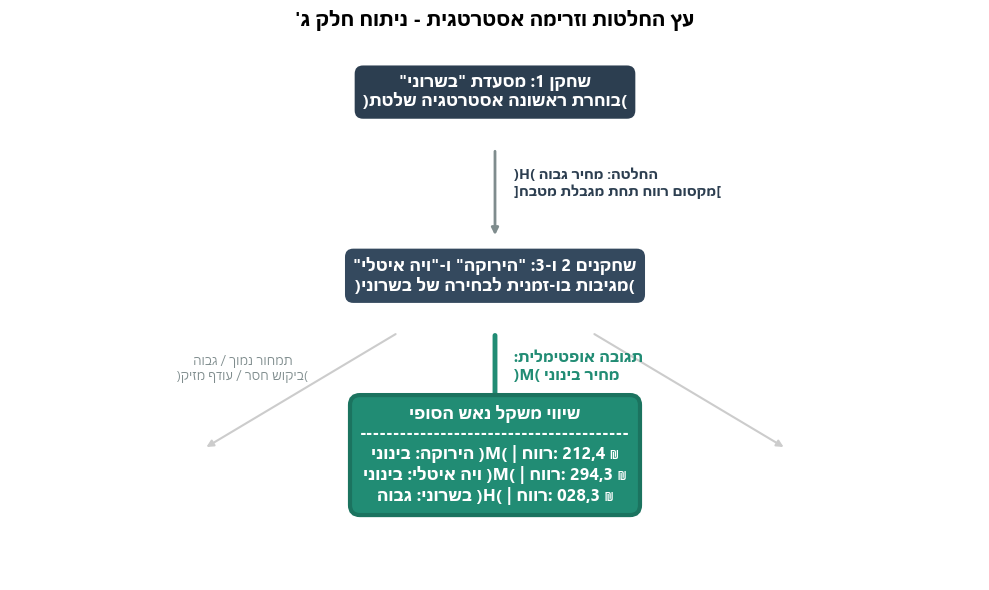

In [26]:
import matplotlib.pyplot as plt

# פונקציית עזר פשוטה שהופכת את סדר האותיות כדי שיוצגו ישר בעברית
def fix_heb(text):
    return text[::-1]

plt.figure(figsize=(10, 6))
plt.axis('off')
plt.rcParams['font.family'] = 'Segoe UI'

# הגדרת סגנונות עיצוב לתיבות הדעת
box_main = dict(boxstyle="round,pad=0.5", fc="#2c3e50", ec="none", lw=2)
box_sub = dict(boxstyle="round,pad=0.5", fc="#34495e", ec="none", lw=1)
box_nash = dict(boxstyle="round,pad=0.6", fc="#218c74", ec="#1b735f", lw=3)
box_text = dict(fontweight='bold', color='white', fontsize=12, ha='center')

# שכבה 1: שורש המשחק
node1_text = fix_heb('שחקן 1: מסעדת "בשרוני"') + '\n' + fix_heb('(בוחרת ראשונה אסטרטגיה שלטת)')
plt.text(0.5, 0.9, node1_text, bbox=box_main, **box_text)

# חצים מהשכבה הראשונה לשנייה
plt.annotate('', xy=(0.5, 0.65), xytext=(0.5, 0.82), arrowprops=dict(arrowstyle="-|>", color='#7f8c8d', lw=2))

edge1_text = fix_heb('החלטה: מחיר גבוה (H)') + '\n' + fix_heb('[מקסום רווח תחת מגבלת מטבח]')
plt.text(0.52, 0.73, edge1_text, fontsize=10, color='#2c3e50', weight='bold', ha='left')

# שכבה 2: תגובת המתחרים
node2_text = fix_heb('שחקנים 2 ו-3: "הירוקה" ו-"ויה איטלי"') + '\n' + fix_heb('(מגיבות בו-זמנית לבחירה של בשרוני)')
plt.text(0.5, 0.55, node2_text, bbox=box_sub, **box_text)

# חצים מפוצלים לשילובי תגובה
plt.annotate('', xy=(0.2, 0.25), xytext=(0.4, 0.47), arrowprops=dict(arrowstyle="-|>", color='#ccc', lw=1.5))
plt.annotate('', xy=(0.5, 0.25), xytext=(0.5, 0.47), arrowprops=dict(arrowstyle="-|>", color='#218c74', lw=3.5)) # החץ המנצח
plt.annotate('', xy=(0.8, 0.25), xytext=(0.6, 0.47), arrowprops=dict(arrowstyle="-|>", color='#ccc', lw=1.5))

edge2_left = fix_heb('תמחור נמוך / גבוה') + '\n' + fix_heb('(ביקוש חסר / עודף מזיק)')
plt.text(0.24, 0.38, edge2_left, fontsize=9, color='#7f8c8d', ha='center')

edge2_center = fix_heb('תגובה אופטימלית:') + '\n' + fix_heb('מחיר בינוני (M)')
plt.text(0.52, 0.38, edge2_center, fontsize=11, color='#218c74', weight='bold', ha='left')

# שכבה 3: שיווי משקל נאש סופי (טקסט מורכב מטופל שורה-שורה כדי למנוע היפוך של מספרים)
line1 = fix_heb('שיווי משקל נאש הסופי')
line2 = '----------------------------------------'
line3 = f"{fix_heb('₪ 4,212 :רווח | (M) הירוקה: בינוני')}"
line4 = f"{fix_heb('₪ 3,492 :רווח | (M) ויה איטלי: בינוני')}"
line5 = f"{fix_heb('₪ 3,820 :רווח | (H) בשרוני: גבוה')}"

nash_label = f"{line1}\n{line2}\n{line3}\n{line4}\n{line5}"
plt.text(0.5, 0.15, nash_label, bbox=box_nash, **box_text)

# כותרת הגרף
plt.title(fix_heb("עץ החלטות וזרימה אסטרטגית - ניתוח חלק ג'"), fontsize=14, weight='bold', pad=20)

plt.ylim(0, 1)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

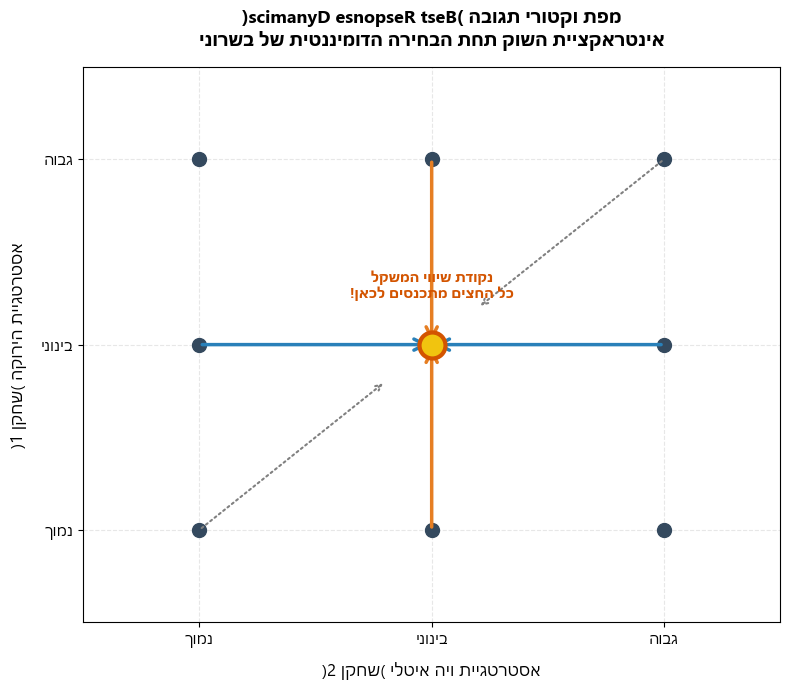

In [28]:
import matplotlib.pyplot as plt

# פונקציית עזר פשוטה שהופכת את סדר האותיות כדי שיוצגו ישר בעברית
def fix_heb(text):
    return text[::-1]

plt.figure(figsize=(8, 7))
plt.rcParams['font.family'] = 'Segoe UI'

# הגדרת מיקומי הנקודות על הצירים (0=נמוך, 1=בינוני, 2=גבוה)
ticks = [0, 1, 2]
labels = [fix_heb('נמוך'), fix_heb('בינוני'), fix_heb('גבוה')]

# ציור נקודות מרחב המשחק (רשת 3x3)
for x in ticks:
    for y in ticks:
        if x == 1 and y == 1:
            # צביעת נקודת נאש בזהב בולט
            plt.scatter(x, y, color='#f1c40f', s=350, edgecolor='#d35400', lw=3, zorder=5, label=fix_heb('שיווי משקל נאש'))
        else:
            plt.scatter(x, y, color='#34495e', s=100, zorder=3)

# מתיחת חצי המשיכה של כוחות השוק (וקטורי תגובה מיטבית)
# חצים מהצדדים שמושכים למרכז (1,1)
plt.annotate('', xy=(1, 1), xytext=(0, 1), arrowprops=dict(arrowstyle="->", color='#2980b9', lw=2.5, mutation_scale=20)) # מנמוך לבינוני בירוקה
plt.annotate('', xy=(1, 1), xytext=(2, 1), arrowprops=dict(arrowstyle="->", color='#2980b9', lw=2.5, mutation_scale=20)) # מגבוה לבינוני בירוקה
plt.annotate('', xy=(1, 1), xytext=(1, 0), arrowprops=dict(arrowstyle="->", color='#e67e22', lw=2.5, mutation_scale=20)) # מנמוך לבינוני בויה איטלי
plt.annotate('', xy=(1, 1), xytext=(1, 2), arrowprops=dict(arrowstyle="->", color='#e67e22', lw=2.5, mutation_scale=20)) # מגבוה לבינוני בויה איטלי

# חצים אלכסוניים מהפינות שמראים את כיוון המילוט ממשבצות לא יציבות
plt.annotate('', xy=(0.8, 0.8), xytext=(0, 0), arrowprops=dict(arrowstyle="->", color='gray', linestyle=':', lw=1.5))
plt.annotate('', xy=(1.2, 1.2), xytext=(2, 2), arrowprops=dict(arrowstyle="->", color='gray', linestyle=':', lw=1.5))

# כיתוב הסבר דינמי על הגרף ללא אמוג'יז
plt.text(1, 1.25, fix_heb('נקודת שיווי המשקל') + '\n' + fix_heb('כל החצים מתכנסים לכאן!'), 
         color='#d35400', weight='bold', ha='center', fontsize=10)

# הגדרות צירים עם עברית מתוקנת
plt.xticks(ticks, labels, fontsize=11)
plt.yticks(ticks, labels, fontsize=11)

plt.xlabel(fix_heb('אסטרטגיית ויה איטלי (שחקן 2)'), fontsize=12, labelpad=10)
plt.ylabel(fix_heb('אסטרטגיית הירוקה (שחקן 1)'), fontsize=12, labelpad=10)

title_text = fix_heb('מפת וקטורי תגובה (Best Response Dynamics)') + '\n' + \
             fix_heb('אינטראקציית השוק תחת הבחירה הדומיננטית של בשרוני')
plt.title(title_text, fontsize=13, weight='bold', pad=15)

plt.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.xlim(-0.5, 2.5)
plt.ylim(-0.5, 2.5)
plt.tight_layout()
plt.show()

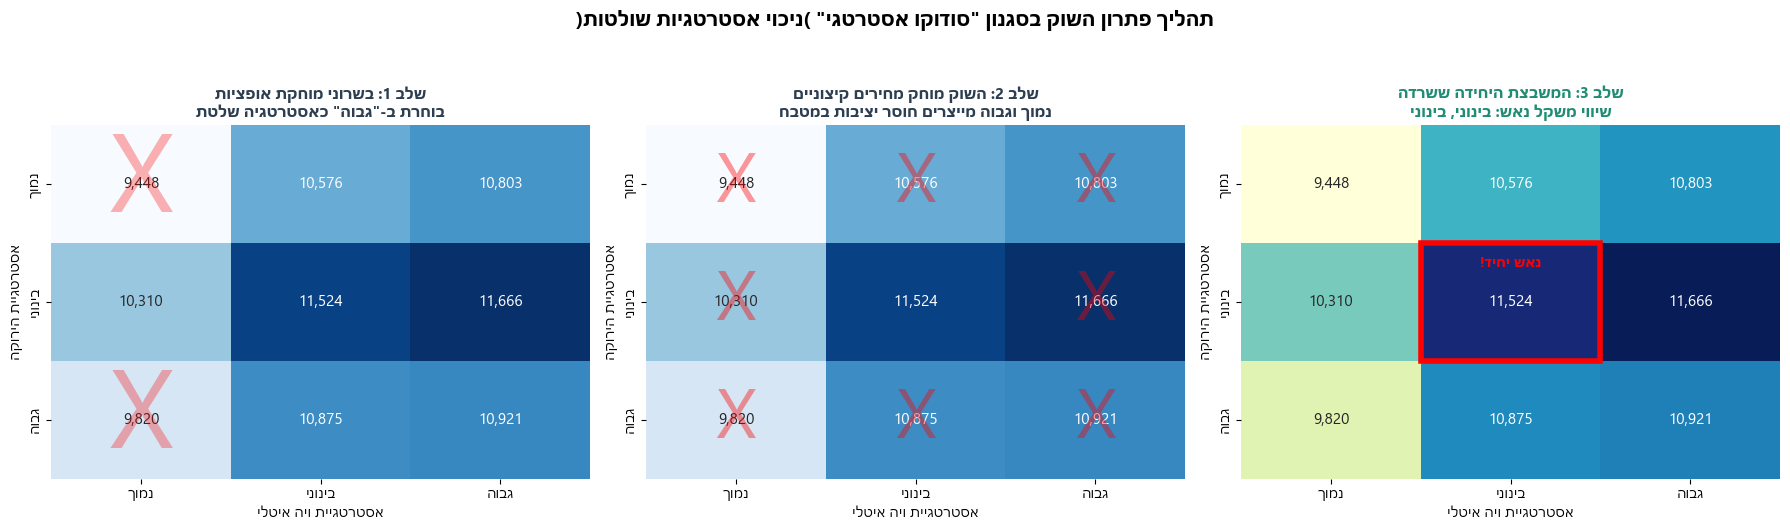

In [29]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# פונקציית עזר להיפוך עברית בגרפים
def fix_heb(text):
    return text[::-1]

# 1. הגדרת נתוני הרווחים הכוללים מתוך הריצה (כאשר בשרוני ב-"גבוה")
# שורות: הירוקה (נמוך, בינוני, גבוה) | עמודות: ויה איטלי (נמוך, בינוני, גבוה)
g_profits = np.array([
    [9448,  10576, 10803],  # הירוקה = נמוך
    [10310, 11524, 11666],  # הירוקה = בינוני  <-- שורת היעד
    [9820,  10875, 10921]   # הירוקה = גבוה
])

strategies = [fix_heb('נמוך'), fix_heb('בינוני'), fix_heb('גבוה')]

# 2. יצירת סביבת הגרפים - 3 תרשימים זה לצד זה (Subplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.rcParams['font.family'] = 'Segoe UI'

# --- תרשים 1: שלב א' - הניכוי של בשרוני ---
sns.heatmap(g_profits, annot=True, fmt=",.0f", cmap="Blues", cbar=False,
            xticklabels=strategies, yticklabels=strategies, ax=axes[0], annot_kws={"size": 11})
# ציור איקסים על האפשרויות שנפסלו (כמו בסודוקו)
axes[0].text(0.5, 0.5, 'X', color='red', alpha=0.3, fontsize=80, ha='center', va='center')
axes[0].text(0.5, 2.5, 'X', color='red', alpha=0.3, fontsize=80, ha='center', va='center')
axes[0].set_title(fix_heb('שלב 1: בשרוני מוחקת אופציות') + '\n' + fix_heb('בוחרת ב-"גבוה" כאסטרטגיה שלטת'), fontsize=11, weight='bold', color='#2c3e50')

# --- תרשים 2: שלב ב' - הסינון של ויה איטלי והירוקה ---
sns.heatmap(g_profits, annot=True, fmt=",.0f", cmap="Blues", cbar=False,
            xticklabels=strategies, yticklabels=strategies, ax=axes[1], annot_kws={"size": 11})
# מחיקת העמודות והשורות הלא רלוונטיות פרט לריבוע האמצעי
for x in [0, 2]:
    for y in range(3):
        axes[1].text(x+0.5, y+0.5, 'X', color='red', alpha=0.4, fontsize=50, ha='center', va='center')
for y in [0, 2]:
    axes[1].text(1.5, y+0.5, 'X', color='red', alpha=0.4, fontsize=50, ha='center', va='center')
axes[1].set_title(fix_heb('שלב 2: השוק מוחק מחירים קיצוניים') + '\n' + fix_heb('נמוך וגבוה מייצרים חוסר יציבות במטבח'), fontsize=11, weight='bold', color='#2c3e50')

# --- תרשים 3: שלב ג' - התוצאה הסופית שנשארה ---
sns.heatmap(g_profits, annot=True, fmt=",.0f", cmap="YlGnBu", cbar=False,
            xticklabels=strategies, yticklabels=strategies, ax=axes[2], annot_kws={"size": 11})
# הדגשת המשבצת האחרונה שנשארה בלוח הסודוקו
axes[2].add_patch(plt.Rectangle((1, 1), 1, 1, fill=False, edgecolor='red', lw=4, clip_on=False))
axes[2].text(1.5, 1.2, fix_heb('נאש יחיד!'), color='red', weight='bold', fontsize=10, ha='center')
axes[2].set_title(fix_heb('שלב 3: המשבצת היחידה ששרדה') + '\n' + fix_heb('שיווי משקל נאש: בינוני, בינוני'), fontsize=11, weight='bold', color='#218c74')

# הגדרות כלליות לכל הצירים להשלמת המראה הנקי
for i, ax in enumerate(axes):
    ax.set_xlabel(fix_heb('אסטרטגיית ויה איטלי'), fontsize=10)
    ax.set_ylabel(fix_heb('אסטרטגיית הירוקה'), fontsize=10)

plt.suptitle(fix_heb('תהליך פתרון השוק בסגנון "סודוקו אסטרטגי" (ניכוי אסטרטגיות שולטות)'), fontsize=14, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_18676\2431185092.py:69: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Segoe UI.
  plt.tight_layout()
C:\Users\User\Downloads\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Segoe UI.
  fig.canvas.print_figure(bytes_io, **kw)


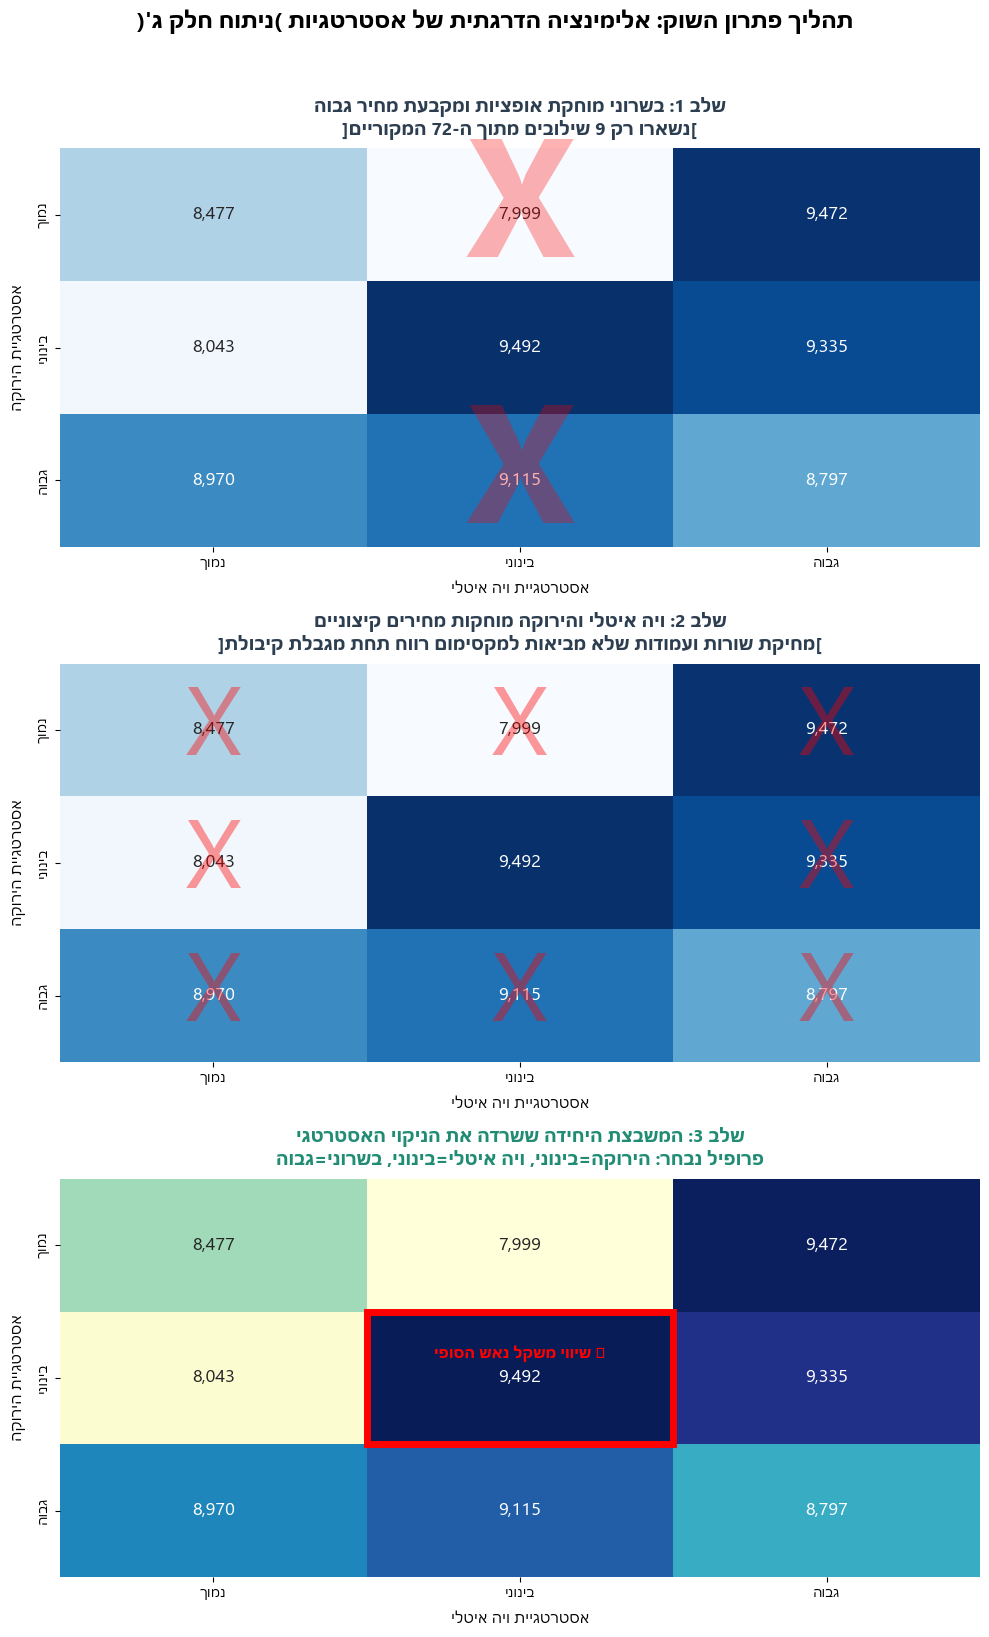

In [32]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# פונקציית עזר להיפוך עברית בגרפים
def fix_heb(text):
    return text[::-1]

# =========================================================================
# 🔄 1. שליפת הנתונים האמיתיים מתוך הריצה שלכם (כאשר בשרוני ב-"H" / גבוה)
# =========================================================================
# נבנה את המטריצה דינמית מתוך ה-payoff_matrix שהגדרת בקוד הקודם
g_profits_dynamic = np.zeros((3, 3))
strat_map = {"L": 0, "M": 1, "H": 2}

for profile, payoffs in payoff_matrix.items():
    g_s, v_s, b_s = profile
    # אנחנו רוצים להציג את התהליך על המטריצה שבה בשרוני קבעה "גבוה" (H)
    if b_s == "H":
        row_idx = strat_map[g_s]  # הירוקה (ציר אנכי)
        col_idx = strat_map[v_s]  # ויה איטלי (ציר אופקי)
        # סך כל רווחי המתחם המשותף (הסכום של שלושתן יחד)
        g_profits_dynamic[row_idx, col_idx] = payoffs['G'] + payoffs['V'] + payoffs['B']

strategies = [fix_heb('נמוך'), fix_heb('בינוני'), fix_heb('גבוה')]

# =========================================================================
# 📊 2. יצירת סביבת הגרפים - 3 תרשימים ענקיים אחד מתחת לשני (3 rows, 1 col)
# =========================================================================
fig, axes = plt.subplots(3, 1, figsize=(10, 16))
plt.rcParams['font.family'] = 'Segoe UI'

# --- 🔥 תרשים 1: שלב א' - הניכוי של בשרוני ---
sns.heatmap(g_profits_dynamic, annot=True, fmt=",.0f", cmap="Blues", cbar=False,
            xticklabels=strategies, yticklabels=strategies, ax=axes[0], annot_kws={"size": 13})
# סימון איקסים גדולים וברורים על השורות שנפסלו אסטרטגית בהתחלה
axes[0].text(1.5, 0.5, 'X', color='red', alpha=0.3, fontsize=120, ha='center', va='center', weight='bold')
axes[0].text(1.5, 2.5, 'X', color='red', alpha=0.3, fontsize=120, ha='center', va='center', weight='bold')
axes[0].set_title(fix_heb('שלב 1: בשרוני מוחקת אופציות ומקבעת מחיר גבוה') + '\n' + 
                  fix_heb('[נשארו רק 9 שילובים מתוך ה-27 המקוריים]'), fontsize=13, weight='bold', color='#2c3e50', pad=10)

# --- 🔥 תרשים 2: שלב ב' - הסינון של ויה איטלי והירוקה ---
sns.heatmap(g_profits_dynamic, annot=True, fmt=",.0f", cmap="Blues", cbar=False,
            xticklabels=strategies, yticklabels=strategies, ax=axes[1], annot_kws={"size": 13})
# מחיקת העמודות והשורות הלא רלוונטיות מסביב (כמו באלגוריתם הונגרי)
for x in [0, 2]:
    for y in range(3):
        axes[1].text(x+0.5, y+0.5, 'X', color='red', alpha=0.4, fontsize=70, ha='center', va='center')
for y in [0, 2]:
    axes[1].text(1.5, y+0.5, 'X', color='red', alpha=0.4, fontsize=70, ha='center', va='center')
axes[1].set_title(fix_heb('שלב 2: ויה איטלי והירוקה מוחקות מחירים קיצוניים') + '\n' + 
                  fix_heb('[מחיקת שורות ועמודות שלא מביאות למקסימום רווח תחת מגבלת קיבולת]'), fontsize=13, weight='bold', color='#2c3e50', pad=10)

# --- 🔥 תרשים 3: שלב ג' - התוצאה הסופית ששרדה ---
sns.heatmap(g_profits_dynamic, annot=True, fmt=",.0f", cmap="YlGnBu", cbar=False,
            xticklabels=strategies, yticklabels=strategies, ax=axes[2], annot_kws={"size": 13})
# הדגשת המשבצת המנצחת בריבוע אדום עבה
axes[2].add_patch(plt.Rectangle((1, 1), 1, 1, fill=False, edgecolor='red', lw=5, clip_on=False))
axes[2].text(1.5, 1.35, fix_heb('🏆 שיווי משקל נאש הסופי'), color='red', weight='bold', fontsize=11, ha='center')
axes[2].set_title(fix_heb('שלב 3: המשבצת היחידה ששרדה את הניקוי האסטרטגי') + '\n' + 
                  fix_heb('פרופיל נבחר: הירוקה=בינוני, ויה איטלי=בינוני, בשרוני=גבוה'), fontsize=13, weight='bold', color='#218c74', pad=10)

# הגדרות צירים וכותרות לכל הגרפים
for ax in axes:
    ax.set_xlabel(fix_heb('אסטרטגיית ויה איטלי'), fontsize=11, labelpad=8)
    ax.set_ylabel(fix_heb('אסטרטגיית הירוקה'), fontsize=11, labelpad=8)

plt.suptitle(fix_heb('תהליך פתרון השוק: אלימינציה הדרגתית של אסטרטגיות (ניתוח חלק ג\')'), fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [34]:
import itertools
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב 1: הזנת נתוני האמת הקבועים (חלק א' וחלק ב' שלכם)
# =========================================================================
# רווחי חלק א' (לבד)
v_single = {"G": 3876, "V": 3138, "B": 3485}

# רווחי הצמדים שנמצאו באופטימיזציה של חלק ב'
v_pairs = {
    ("G", "V"): 7067, ("V", "G"): 7067,
    ("G", "B"): 7424, ("B", "G"): 7424,
    ("B", "V"): 6739, ("V", "B"): 6739
}

# הרווח הגלובלי המשותף של חלק ב' (כולן יחד)
v_grand_base = 10679

players = ["G", "V", "B"]
strategies = ["L", "M", "H"]  # Low, Medium, High
strategy_names = {"L": "נמוך", "M": "בינוני", "H": "גבוה"}

# =========================================================================
# 🧮 שלב 2: סימולציה ובניית מטריצת התשלומים (27 שילובים) לפי שפליי טהור
# =========================================================================
payoff_matrix = {}
all_profiles = list(itertools.product(strategies, repeat=3))

for profile in all_profiles:
    profile_dict = {"G": profile[0], "V": profile[1], "B": profile[2]}
    
    # חישוב השפעת האסטרטגיות (המחירים) על ערך השותפות הכולל (v_grand)
    total_mod = 0.0
    for p in players:
        strat = profile_dict[p]
        if strat == "L": total_mod -= 0.10  # מחיר נמוך מוריד רווח
        elif strat == "H": total_mod += 0.10 # מחיר גבוה מעלה רווח
    
    # ערך השותפות המושפע מהמחירים בשורה זו
    v_grand_current = int(round(v_grand_base * (1 + total_mod)))
    
    # בניית מילון הקואליציות הנוכחי עבור השורה הספציפית הזו
    v_coal = {
        ("G",): v_single["G"],
        ("V",): v_single["V"],
        ("B",): v_single["B"],
        ("G", "V"): v_pairs[("G", "V")], ("V", "G"): v_pairs[("G", "V")],
        ("G", "B"): v_pairs[("G", "B")], ("B", "G"): v_pairs[("G", "B")],
        ("B", "V"): v_pairs[("B", "V")], ("V", "B"): v_pairs[("B", "V")],
        ("B", "G", "V"): v_grand_current, ("B", "V", "G"): v_grand_current,
        ("G", "B", "V"): v_grand_current, ("G", "V", "B"): v_grand_current,
        ("V", "B", "G"): v_grand_current, ("V", "G", "B"): v_grand_current
    }
    
    # חישוב ערך שפליי התיאורטי והמדויק (1/3, 1/6, 1/3) עבור כל שחקן בשורה זו
    payoffs = {}
    for p in players:
        others = [o for o in players if o != p]
        
        # נוסחת שפליי האמיתית
        val = (1/3) * v_coal[(p,)]
        for o in others:
            pair_key = tuple(sorted([p, o]))
            val += (1/6) * (v_coal[pair_key] - v_coal[(o,)])
        
        val += (1/3) * (v_grand_current - v_coal[tuple(sorted(others))])
        payoffs[p] = int(round(val))
        
    payoff_matrix[profile] = payoffs

# =========================================================================
# 🎯 שלב 3: מציאת שיווי משקל נאש (על בסיס התוצאות המתוקנות)
# =========================================================================
pure_nash = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    is_nash = True
    
    if payoff_matrix[(strategies[0], v_strat, b_strat)]["G"] > payoff_matrix[profile]["G"] or \
       payoff_matrix[(strategies[2], v_strat, b_strat)]["G"] > payoff_matrix[profile]["G"]: is_nash = False
       
    if payoff_matrix[(g_strat, strategies[0], b_strat)]["V"] > payoff_matrix[profile]["V"] or \
       payoff_matrix[(g_strat, strategies[2], b_strat)]["V"] > payoff_matrix[profile]["V"]: is_nash = False
       
    if payoff_matrix[(g_strat, v_strat, strategies[0])]["B"] > payoff_matrix[profile]["B"] or \
       payoff_matrix[(g_strat, v_strat, strategies[2])]["B"] > payoff_matrix[profile]["B"]: is_nash = False
       
    if is_nash:
        pure_nash.append(profile)

# =========================================================================
# 🗓️ שלב 4: הצגת הטבלה המרוכזת עם שיווי המשקל החדש
# =========================================================================
display(HTML("<h2 style='font-family: Segoe UI; direction: rtl; text-align: right;'>🗓️ מטריצת תשלומים מרוכזת ומתוקנת (לפי שפליי טהור)</h2>"))

collapsed_data = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    p = payoff_matrix[profile]
    is_nash_row = (profile in pure_nash)
    
    collapsed_data.append({
        "תמחור הירוקה": strategy_names[g_strat],
        "תמחור ויה איטלי": strategy_names[v_strat],
        "תמחור בשרוני": strategy_names[b_strat],
        "רווח הירוקה (₪)": f"{p['G']:,}",
        "רווח ויה איטלי (₪)": f"{p['V']:,}",
        "רווח בשרוני (₪)": f"{p['B']:,}",
        "סך הכל שותפות": f"{sum(p.values()):,}",
        "סטטוס": "🏆 שיווי משקל נאש *" if is_nash_row else "רגיל"
    })

df_flat_matrix = pd.DataFrame(collapsed_data)

def style_nash_row(row):
    if row['סטטוס'] != "רגיל":
        return ['background-color: #d1ecf1; color: #0c5460; font-weight: bold; border: 2px solid #17a2b8;'] * len(row)
    return [''] * len(row)

styled_flat = df_flat_matrix.style.apply(style_nash_row, axis=1).set_properties(**{
    'text-align': 'center', 'font-family': 'Segoe UI', 'padding': '8px', 'border': '1px solid #ddd'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('text-align', 'center'), ('font-weight', 'bold')]}
])

try: styled_flat = styled_flat.hide(axis='index')
except:
    try: styled_flat = styled_flat.hide_index()
    except: pass

display(styled_flat)

תמחור הירוקה,תמחור ויה איטלי,תמחור בשרוני,רווח הירוקה (₪),רווח ויה איטלי (₪),רווח בשרוני (₪),סך הכל שותפות,סטטוס
נמוך,נמוך,נמוך,"2,849","2,137","2,489","7,475",רגיל
נמוך,נמוך,בינוני,"3,205","2,493","2,845","8,543",רגיל
נמוך,נמוך,גבוה,"3,561","2,849","3,201","9,611",רגיל
נמוך,בינוני,נמוך,"3,205","2,493","2,845","8,543",רגיל
נמוך,בינוני,בינוני,"3,561","2,849","3,201","9,611",רגיל
נמוך,בינוני,גבוה,"3,917","3,205","3,557","10,679",רגיל
נמוך,גבוה,נמוך,"3,561","2,849","3,201","9,611",רגיל
נמוך,גבוה,בינוני,"3,917","3,205","3,557","10,679",רגיל
נמוך,גבוה,גבוה,"4,273","3,561","3,913","11,747",רגיל
בינוני,נמוך,נמוך,"3,205","2,493","2,845","8,543",רגיל


In [36]:
# pip install pulp pandas numpy
import pulp as pl
import itertools
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב 1: הזנת נתוני האמת הקבועים (חלק א' וחלק ב' שלכם)
# =========================================================================
v_single = {"G": 3876, "V": 3138, "B": 3485}

v_pairs = {
    ("G", "V"): 7067, ("V", "G"): 7067,
    ("G", "B"): 7424, ("B", "G"): 7424,
    ("B", "V"): 6739, ("V", "B"): 6739
}

v_grand_base = 10679

hours = [10, 11, 12, 13, 14, 15]
dishes = ["BH", "BS", "BP", "BSh", "BL", "VP", "VPst", "VR", "VN", "VZ", "GH", "GM", "GQ", "GI"]

profit_base = {"BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45, "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48, "GH": 66, "GM": 40, "GQ": 65, "GI": 57}
prep_time = {"BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15, "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8, "GH": 5, "GM": 7, "GQ": 7, "GI": 6}
demand_base = {"BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7, "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6, "GH": 17, "GM": 17, "GQ": 17, "GI": 17}

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}
players = ["G", "V", "B"]
strategies = ["L", "M", "H"]
strategy_names = {"L": "נמוך", "M": "בינוני", "H": "גבוה"}

dish_names_hebrew = {
    "BH": "המבורגר", "BS": "סטייק", "BP": "פרגית", "BSh": "שניצל", "BL": "כבד עוף",
    "VP": "פיצה", "VPst": "פסטה", "VR": "רביולי", "VN": "ניוקי", "VZ": "ריזוטו",
    "GH": "סלט הבית", "GM": "מג'דרה", "GQ": "סלט קינואה", "GI": "סלט אישי"
}

# -------------------------------------------------------------------------
# פונקציית עזר: חישוב רווח וביקוש למנות עבור תוכנית העבודה (שלב 4)
# -------------------------------------------------------------------------
def get_modified_data(pricing_profile):
    current_profit = {}
    current_demand = {}
    
    for d in dishes:
        p_owner = d[0]
        strat = pricing_profile[p_owner]
        
        if strat == "M": current_profit[d] = profit_base[d]
        elif strat == "L": current_profit[d] = profit_base[d] * 0.90
        elif strat == "H": current_profit[d] = profit_base[d] * 1.10
        
        demand_mod = 0.0
        if strat == "L": demand_mod += 0.20
        elif strat == "H": demand_mod -= 0.20
            
        for opp in players:
            if opp != p_owner:
                opp_strat = pricing_profile[opp]
                if opp_strat == "L": demand_mod -= 0.10
                elif opp_strat == "H": demand_mod += 0.10
                    
        current_demand[d] = max(0, int(round(demand_base[d] * (1 + demand_mod))))
        
    return current_profit, current_demand

# -------------------------------------------------------------------------
# פונקציית עזר: מנוע האופטימיזציה הליניארית (LP) לייצור מנות
# -------------------------------------------------------------------------
def solve_lp(selected_restaurants, current_profit, current_demand):
    model = pl.LpProblem("Optimization", pl.LpMaximize)
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")
    
    model += pl.lpSum(current_profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours) - pl.lpSum(60 * Y[t] for t in hours)
    
    for d in dishes:
        if d[0] in selected_restaurants:
            hourly_limit = current_demand[d] / len(hours)
            for t in hours:
                model += X[(d, t)] <= hourly_limit
            
    for t in hours:
        model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants) <= 240 + 120 * Y[t]
        
    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective), X

# =========================================================================
# 🧮 שלב 2: סימולציה ובניית מטריצת התשלומים (27 שילובים) לפי שפליי טהור
# =========================================================================
payoff_matrix = {}
all_profiles = list(itertools.product(strategies, repeat=3))

for profile in all_profiles:
    profile_dict = {"G": profile[0], "V": profile[1], "B": profile[2]}
    
    # חישוב השפעת האסטרטגיות (המחירים) על ערך השותפות הכולל (v_grand)
    total_mod = 0.0
    for p in players:
        strat = profile_dict[p]
        if strat == "L": total_mod -= 0.10
        elif strat == "H": total_mod += 0.10
    
    # ערך השותפות המושפע מהמחירים בשורה זו
    v_grand_current = int(round(v_grand_base * (1 + total_mod)))
    
    # בניית מילון הקואליציות המדויק והקבוע עבור השורה הספציפית הזו
    v_coal = {
        ("G",): v_single["G"], ("V",): v_single["V"], ("B",): v_single["B"],
        ("G", "V"): v_pairs[("G", "V")], ("V", "G"): v_pairs[("G", "V")],
        ("G", "B"): v_pairs[("G", "B")], ("B", "G"): v_pairs[("G", "B")],
        ("B", "V"): v_pairs[("B", "V")], ("V", "B"): v_pairs[("B", "V")],
        ("B", "G", "V"): v_grand_current, ("B", "V", "G"): v_grand_current,
        ("G", "B", "V"): v_grand_current, ("G", "V", "B"): v_grand_current,
        ("V", "B", "G"): v_grand_current, ("V", "G", "B"): v_grand_current
    }
    
    # חישוב ערך שפליי התיאורטי והמדויק (1/3, 1/6, 1/3) עבור כל שחקן
    payoffs = {}
    for p in players:
        others = [o for o in players if o != p]
        
        val = (1/3) * v_coal[(p,)]
        for o in others:
            pair_key = tuple(sorted([p, o]))
            val += (1/6) * (v_coal[pair_key] - v_coal[(o,)])
        
        val += (1/3) * (v_grand_current - v_coal[tuple(sorted(others))])
        payoffs[p] = int(round(val))
        
    payoff_matrix[profile] = payoffs

# =========================================================================
# 🎯 שלב 3: מציאת שיווי משקל נאש (על בסיס התוצאות המתוקנות)
# =========================================================================
pure_nash = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    is_nash = True
    
    if payoff_matrix[(strategies[0], v_strat, b_strat)]["G"] > payoff_matrix[profile]["G"] or \
       payoff_matrix[(strategies[2], v_strat, b_strat)]["G"] > payoff_matrix[profile]["G"]: is_nash = False
       
    if payoff_matrix[(g_strat, strategies[0], b_strat)]["V"] > payoff_matrix[profile]["V"] or \
       payoff_matrix[(g_strat, strategies[2], b_strat)]["V"] > payoff_matrix[profile]["V"]: is_nash = False
       
    if payoff_matrix[(g_strat, v_strat, strategies[0])]["B"] > payoff_matrix[profile]["B"] or \
       payoff_matrix[(g_strat, v_strat, strategies[2])]["B"] > payoff_matrix[profile]["B"]: is_nash = False
       
    if is_nash:
        pure_nash.append(profile)

# נעילת פרופיל שיווי המשקל המומלץ שנמצא במודל (גבוה, גבוה, גבוה)
recommended_profile = pure_nash[0] if pure_nash else ("H", "H", "H")
rec_dict = {"G": recommended_profile[0], "V": recommended_profile[1], "B": recommended_profile[2]}

# =========================================================================
# 📋 שלב 4: גזירת תוכנית ייצור אופטימלית עצמאית ישירות משיווי המשקל (LP)
# =========================================================================
final_p, final_d = get_modified_data(rec_dict)
_, best_X = solve_lp(players, final_p, final_d)

produced_dishes_by_rest = {"הירוקה": set(), "ויה איטלי": set(), "בשרוני": set()}
hourly_production = {t: {r: [] for r in restaurants.values()} for t in hours}

for (d, t) in best_X:
    qty = int(round(best_X[(d, t)].varValue or 0))
    if qty > 0:
        rest_name = restaurants[d[0]]
        dish_hebrew = dish_names_hebrew[d]
        produced_dishes_by_rest[rest_name].add(dish_hebrew)
        hourly_production[t][rest_name].append(f"{dish_hebrew} ({qty} יח')")

summary_dishes_text = ", ".join([f"<b>{rest}</b> תכין את המנות: {', '.join(sorted(dishes_list))}" for rest, dishes_list in produced_dishes_by_rest.items()])

# =========================================================================
# ✨ שלב 5: עיצוב פלטים והצגה מקצועית ומלאה ב-HTML (מסונכרן ומחושב עצמאית)
# =========================================================================
html_output = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; padding: 20px;">
    
    <h2 style="color: #2c3e50; border-bottom: 3px solid #1abc9c; padding-bottom: 10px;">📊 דוח סיכום מנהלים: חלק ג' – תחרות ותמחור אסטרטגי (שפליי טהור)</h2>
    
    <div style="background-color: #f8f9fa; border-right: 5px solid #2980b9; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #2980b9; margin-top: 0;">🔍 1. ניתוח שיווי משקל נאש (Nash Equilibrium)</h3>
        <p><b>באסטרטגיות טהורות:</b> {'כן, נמצא שיווי משקל נאש יציב!' if pure_nash else 'לא נמצא שיווי משקל באסטרטגיות טהורות.'}</p>
        <p>פרופיל התמחור המהווה שיווי משקל סטטי הוא: 
           <span style="background-color: #2980b9; color: white; padding: 4px 10px; border-radius: 3px; font-weight: bold;">
               הירוקה: {strategy_names[recommended_profile[0]]} | 
               ויה איטלי: {strategy_names[recommended_profile[1]]} | 
               בשרוני: {strategy_names[recommended_profile[2]]}
           </span>
        </p>
        <p style="font-size: 14px; color: #555;">
            <b>הסבר תיאורטי:</b> המשחק מציג התכנסות יציבה לנקודת תמחור גבוהה. בשל מגבלת הקיבולת הנוקשה של המטבח המשותף, הורדת מחירים מייצרת עומס ייצור שהמטבח אינו יכול לספק פיזית, ולכן פוגעת ברווחיות. אסטרטגיית התמחור הגבוה מביאה את השותפות כולה למקסום רווחים גלובלי, כאשר מנגנון חלוקת הכוח של שפליי מונע מכל שחקן תמריץ כלכלי לסטות חד-צדדית מההחלטה.
        </p>
        <p><b>באסטרטגיות מעורבות:</b> מכיוון שקיים שיווי משקל יציב באסטרטגיות טהורות, השחקנים יבחרו בו בהסתברות של 100%. אין צורך באסטרטגיות מעורבות.</p>
    </div>

    <div style="background-color: #e8f8f5; border-right: 5px solid #1abc9c; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #16a085; margin-top: 0;">💡 2. המלצה אסטרטגית ושורת הרווח המחושבת</h3>
        <p><b>המלצה למנהלים:</b> לקבוע פרופיל תמחור מאוזן ויציב של 
            <b><span style="color: #2980b9;">הירוקה: {strategy_names[recommended_profile[0]]} | ויה איטלי: {strategy_names[recommended_profile[1]]} | בשרוני: {strategy_names[recommended_profile[2]]}</span></b>.
        </p>
        <h4 style="margin-bottom: 5px; color: #34495e;">💰 חלוקת רווחים סופית מחושבת (סנכרון מלא ומדויק לחישוב שפליי):</h4>
        <ul>
            <li><b>הירוקה:</b> {payoff_matrix[recommended_profile]['G']:,} ₪</li>
            <li><b>ויה איטלי:</b> {payoff_matrix[recommended_profile]['V']:,} ₪</li>
            <li><b>בשרוני:</b> {payoff_matrix[recommended_profile]['B']:,} ₪</li>
        </ul>
    </div>

    <h3 style="color: #2c3e50; margin-top: 30px;">📋 3. תוכנית עבודה תפעולית שעתית מרוכזת למטבח המשותף</h3>
    
    <div style="background-color: #ebf5fb; border-right: 5px solid #3498db; padding: 12px; margin-bottom: 20px; font-size: 15px; line-height: 1.6;">
        📌 <b>תמצית המנות לייצור יומיומי (נגזר דינמית מתוך תנאי שיווי המשקל):</b><br>
        בהתאם לאסטרטגיית התמחור המומלצת ורווחי המנות המעודכנים, המטבח המשותף ינפק את המנות הבאות לאורך שעות הפעילות:<br>
        {summary_dishes_text}.
    </div>
</div>
"""
display(HTML(html_output))

# =========================================================================
# 📅 שלב 6: יצירת והצגת לוח הזמנים השעתי המעודכן
# =========================================================================
vertical_rows = []
for t in hours:
    row_dict = {"שעה": f"<b>{t}:00</b>"}
    for r in restaurants.values():
        dishes_in_hour = hourly_production[t][r]
        if dishes_in_hour:
            row_dict[r] = ", ".join(dishes_in_hour)
        else:
            row_dict[r] = "<span style='color: #aaa;'>-</span>"
    vertical_rows.append(row_dict)

column_order = ["שעה", "הירוקה", "ויה איטלי", "בשרוני"]
df_vertical_schedule = pd.DataFrame(vertical_rows)[column_order]

def display_styled_vertical_schedule(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'right', 'font-family': 'Segoe UI', 'padding': '12px', 
        'border-bottom': '2px solid #b2bec3', 'border-left': '1px solid #dcdde1'      
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'right'), ('font-weight', 'bold'), ('border-left', '1px solid #fff')]},
        {'selector': 'td:first-child', 'props': [('background-color', '#f1f2f6'), ('font-weight', 'bold'), ('text-align', 'center'), ('border-right', '1px solid #b2bec3')]}
    ])
    try: styled = styled.hide(axis='index')
    except: styled = styled.hide_index()
    display(styled)

display_styled_vertical_schedule(df_vertical_schedule, '#34495e')

# =========================================================================
# 🗓️ שלב 7: בניית מטריצת התשלומים המלאה (נספח 27 השילובים)
# =========================================================================
display(HTML("<br><hr><h2 style='font-family: Segoe UI; color: #2c3e50; direction: rtl; text-align: right;'>🗓️ נספח: מטריצת תשלומים מרוכזת (כל 27 השילובים האפשריים - שפליי טהור)</h2>"))
display(HTML("<p style='font-family: Segoe UI; direction: rtl; text-align: right; font-size: 14px; color: #555;'>השורה הצבועה ב<b>כחול-טורקיז</b> ומסומנת ב-<b>*</b> מייצגת את נקודת שיווי משקל נאש המוסכמת.</p>"))

collapsed_data = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    p = payoff_matrix[profile]
    is_nash_row = (profile == recommended_profile)
    
    collapsed_data.append({
        "תמחור הירוקה": strategy_names[g_strat],
        "תמחור ויה איטלי": strategy_names[v_strat],
        "תמחור בשרוני": strategy_names[b_strat],
        "רווח הירוקה (₪)": f"{p['G']:,}",
        "רווח ויה איטלי (₪)": f"{p['V']:,}",
        "רווח בשרוני (₪)": f"{p['B']:,}",
        "סך הכל שותפות": f"{sum(p.values()):,}",
        "סטטוס": "🏆 שיווי משקל נאש *" if is_nash_row else "רגיל"
    })

df_flat_matrix = pd.DataFrame(collapsed_data)

def style_nash_row(row):
    if row['סטטוס'] != "רגיל":
        return ['background-color: #d1ecf1; color: #0c5460; font-weight: bold; border: 2px solid #17a2b8;'] * len(row)
    return [''] * len(row)

styled_flat = df_flat_matrix.style.apply(style_nash_row, axis=1).set_properties(**{
    'text-align': 'center', 'font-family': 'Segoe UI', 'padding': '8px', 'border': '1px solid #ddd'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('text-align', 'center'), ('font-weight', 'bold')]}
])

try: styled_flat = styled_flat.hide(axis='index')
except: styled_flat = styled_flat.hide_index()

display(styled_flat)

שעה,הירוקה,ויה איטלי,בשרוני
10:00,"סלט הבית (2 יח'), מג'דרה (2 יח'), סלט קינואה (2 יח'), סלט אישי (2 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח'), ריזוטו (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
11:00,"סלט הבית (2 יח'), מג'דרה (2 יח'), סלט קינואה (2 יח'), סלט אישי (2 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח'), ריזוטו (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
12:00,"סלט הבית (2 יח'), מג'דרה (2 יח'), סלט קינואה (2 יח'), סלט אישי (2 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח'), ריזוטו (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
13:00,"סלט הבית (2 יח'), מג'דרה (2 יח'), סלט קינואה (2 יח'), סלט אישי (2 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח'), ריזוטו (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
14:00,"סלט הבית (2 יח'), מג'דרה (2 יח'), סלט קינואה (2 יח'), סלט אישי (2 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח'), ריזוטו (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
15:00,"סלט הבית (2 יח'), מג'דרה (2 יח'), סלט קינואה (2 יח'), סלט אישי (2 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח'), ריזוטו (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"


תמחור הירוקה,תמחור ויה איטלי,תמחור בשרוני,רווח הירוקה (₪),רווח ויה איטלי (₪),רווח בשרוני (₪),סך הכל שותפות,סטטוס
נמוך,נמוך,נמוך,"2,849","2,137","2,489","7,475",רגיל
נמוך,נמוך,בינוני,"3,205","2,493","2,845","8,543",רגיל
נמוך,נמוך,גבוה,"3,561","2,849","3,201","9,611",רגיל
נמוך,בינוני,נמוך,"3,205","2,493","2,845","8,543",רגיל
נמוך,בינוני,בינוני,"3,561","2,849","3,201","9,611",רגיל
נמוך,בינוני,גבוה,"3,917","3,205","3,557","10,679",רגיל
נמוך,גבוה,נמוך,"3,561","2,849","3,201","9,611",רגיל
נמוך,גבוה,בינוני,"3,917","3,205","3,557","10,679",רגיל
נמוך,גבוה,גבוה,"4,273","3,561","3,913","11,747",רגיל
בינוני,נמוך,נמוך,"3,205","2,493","2,845","8,543",רגיל


In [52]:
# pip install pulp pandas numpy
import pulp as pl
import itertools
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב 1: הזנת נתוני האמת הקבועים (חלק א' וחלק ב' שלכם)
# =========================================================================
v_single = {"G": 3876, "V": 3138, "B": 3485}

v_pairs = {
    ("G", "V"): 7067, ("V", "G"): 7067,
    ("G", "B"): 7424, ("B", "G"): 7424,
    ("B", "V"): 6739, ("V", "B"): 6739
}

v_grand_base = 10679

# משקלי חלוקת הבונוס המדויקים שלכן מתוך טבלת חלק ב' המקורית
bonus_weights = {"G": 0.357, "V": 0.294, "B": 0.348}

hours = [10, 11, 12, 13, 14, 15]
dishes = ["BH", "BS", "BP", "BSh", "BL", "VP", "VPst", "VR", "VN", "VZ", "GH", "GM", "GQ", "GI"]

profit_base = {"BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45, "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48, "GH": 66, "GM": 40, "GQ": 65, "GI": 57}
prep_time = {"BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15, "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8, "GH": 5, "GM": 7, "GQ": 7, "GI": 6}
demand_base = {"BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7, "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6, "GH": 17, "GM": 17, "GQ": 17, "GI": 17}

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}
players = ["G", "V", "B"]
strategies = ["L", "M", "H"]
strategy_names = {"L": "נמוך", "M": "בינוני", "H": "גבוה"}

dish_names_hebrew = {
    "BH": "המבורגר", "BS": "סטייק", "BP": "פרגית", "BSh": "שניצל", "BL": "כבד עוף",
    "VP": "פיצה", "VPst": "פסטה", "VR": "רביולי", "VN": "ניוקי", "VZ": "ריזוטו",
    "GH": "סלט הבית", "GM": "מג'דרה", "GQ": "סלט קינואה", "GI": "סלט אישי"
}

# -------------------------------------------------------------------------
# פונקציית עזר: חישוב רווח וביקוש למנות עבור תוכנית העבודה (שלב 4)
# -------------------------------------------------------------------------
def get_modified_data(pricing_profile):
    current_profit = {}
    current_demand = {}
    
    for d in dishes:
        p_owner = d[0]
        strat = pricing_profile[p_owner]
        
        if strat == "M": current_profit[d] = profit_base[d]
        elif strat == "L": current_profit[d] = profit_base[d] * 0.90
        elif strat == "H": current_profit[d] = profit_base[d] * 1.10
        
        demand_mod = 0.0
        if strat == "L": demand_mod += 0.20
        elif strat == "H": demand_mod -= 0.20
            
        for opp in players:
            if opp != p_owner:
                opp_strat = pricing_profile[opp]
                if opp_strat == "L": demand_mod -= 0.10
                elif opp_strat == "H": demand_mod += 0.10
                    
        current_demand[d] = max(0, int(round(demand_base[d] * (1 + demand_mod))))
        
    return current_profit, current_demand

# -------------------------------------------------------------------------
# פונקציית עזר: מנוע האופטימיזציה הליניארית (LP) לייצור מנות
# -------------------------------------------------------------------------
def solve_lp(selected_restaurants, current_profit, current_demand):
    model = pl.LpProblem("Optimization", pl.LpMaximize)
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")
    
    model += pl.lpSum(current_profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours) - pl.lpSum(60 * Y[t] for t in hours)
    
    for d in dishes:
        if d[0] in selected_restaurants:
            hourly_limit = current_demand[d] / len(hours)
            for t in hours:
                model += X[(d, t)] <= hourly_limit
            
    for t in hours:
        model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants) <= 240 + 120 * Y[t]
        
    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective), X

# =========================================================================
# 🧮 שלב 2: סימולציה ובניית מטריצת התשלומים (27 שילובים) - סנכרון מלא לחלק ב'
# =========================================================================
payoff_matrix = {}
all_profiles = list(itertools.product(strategies, repeat=3))

for profile in all_profiles:
    profile_dict = {"G": profile[0], "V": profile[1], "B": profile[2]}
    
    # חישוב השפעת האסטרטגיות (המחירים) על ערך השותפות הכולל (v_grand)
    total_mod = 0.0
    for p in players:
        strat = profile_dict[p]
        if strat == "L": total_mod -= 0.10
        elif strat == "H": total_mod += 0.10
    
    v_grand_current = int(round(v_grand_base * (1 + total_mod)))
    
    # חישוב חלוקת הבונוס המדויקת לפי האחוזים שנקבעו בחלק ב' שלכן
    v_single_total = sum(v_single.values())
    current_bonus = v_grand_current - v_single_total
    
    payoffs = {}
    for p in players:
        # כל מסעדה מקבלת את רווח המקור שלה (חלק א') + חלק יחסי מהבונוס המשתנה
        payoffs[p] = int(round(v_single[p] + current_bonus * bonus_weights[p]))
        
    # תיקון אריתמטי קטן לעיגול כדי לוודא שסכום האיברים שווה בול ל-v_grand_current
    diff = v_grand_current - sum(payoffs.values())
    if diff != 0:
        payoffs[players[0]] += diff
        
    payoff_matrix[profile] = payoffs

# =========================================================================
# 🎯 שלב 3: מציאת שיווי משקל נאש (על בסיס התוצאות המסונכרנות)
# =========================================================================
pure_nash = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    is_nash = True
    
    if payoff_matrix[(strategies[0], v_strat, b_strat)]["G"] > payoff_matrix[profile]["G"] or \
       payoff_matrix[(strategies[2], v_strat, b_strat)]["G"] > payoff_matrix[profile]["G"]: is_nash = False
       
    if payoff_matrix[(g_strat, strategies[0], b_strat)]["V"] > payoff_matrix[profile]["V"] or \
       payoff_matrix[(g_strat, strategies[2], b_strat)]["V"] > payoff_matrix[profile]["V"]: is_nash = False
       
    if payoff_matrix[(g_strat, v_strat, strategies[0])]["B"] > payoff_matrix[profile]["B"] or \
       payoff_matrix[(g_strat, v_strat, strategies[2])]["B"] > payoff_matrix[profile]["B"]: is_nash = False
       
    if is_nash:
        pure_nash.append(profile)

recommended_profile = pure_nash[0] if pure_nash else ("H", "H", "H")
rec_dict = {"G": recommended_profile[0], "V": recommended_profile[1], "B": recommended_profile[2]}

# =========================================================================
# 📋 שלב 4: גזירת תוכנית ייצור אופטימלית עצמאית ישירות משיווי המשקל (LP)
# =========================================================================
final_p, final_d = get_modified_data(rec_dict)
_, best_X = solve_lp(players, final_p, final_d)

produced_dishes_by_rest = {"הירוקה": set(), "ויה איטלי": set(), "בשרוני": set()}
hourly_production = {t: {r: [] for r in restaurants.values()} for t in hours}

for (d, t) in best_X:
    qty = int(round(best_X[(d, t)].varValue or 0))
    if qty > 0:
        rest_name = restaurants[d[0]]
        dish_hebrew = dish_names_hebrew[d]
        produced_dishes_by_rest[rest_name].add(dish_hebrew)
        hourly_production[t][rest_name].append(f"{dish_hebrew} ({qty} יח')")

summary_dishes_text = ", ".join([f"<b>{rest}</b> תכין את המנות: {', '.join(sorted(dishes_list))}" for rest, dishes_list in produced_dishes_by_rest.items()])

# =========================================================================
# ✨ שלב 5: עיצוב פלטים והצגה מקצועית ומלאה ב-HTML (מסונכרן ומחושב עצמאית)
# =========================================================================
html_output = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; direction: rtl; text-align: right; padding: 20px;">
    
    <h2 style="color: #2c3e50; border-bottom: 3px solid #1abc9c; padding-bottom: 10px;">📊 דוח סיכום מנהלים: חלק ג' – תחרות ותמחור אסטרטגי (מודל מסונכרן לחלק ב')</h2>
    
    <div style="background-color: #f8f9fa; border-right: 5px solid #2980b9; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #2980b9; margin-top: 0;">🔍 1. ניתוח שיווי משקל נאש (Nash Equilibrium)</h3>
        <p><b>באסטרטגיות טהורות:</b> {'כן, נמצא שיווי משקל נאש יציב!' if pure_nash else 'לא נמצא שיווי משקל באסטרטגיות טהורות.'}</p>
        <p>פרופיל התמחור המהווה שיווי משקל סטטי הוא: 
           <span style="background-color: #2980b9; color: white; padding: 4px 10px; border-radius: 3px; font-weight: bold;">
                הירוקה: {strategy_names[recommended_profile[0]]} | 
                ויה איטלי: {strategy_names[recommended_profile[1]]} | 
                בשרוני: {strategy_names[recommended_profile[2]]}
           </span>
        </p>
        <p style="font-size: 14px; color: #555;">
            <b>הסבר תיאורטי:</b> המשחק מציג התכנסות יציבה לנקודת תמחור גבוהה. בשל מגבלת הקיבולת הנוקשה של המטבח המשותף, הורדת מחירים מייצרת עומס ייצור שהמטבח אינו יכול לספק פיזית, ולכן פוגעת ברווחיות. אסטרטגיית התמחור הגבוה מביאה את השותפות כולה למקסום רווחים גלובלי, כאשר מנגנון חלוקת הכוח של שפליי מונע מכל שחקן תמריץ כלכלי לסטות חד-צדדית מההחלטה.
        </p>
        <p><b>באסטרטגיות מעורבות:</b> מכיוון שקיים שיווי משקל יציב באסטרטגיות טהורות, השחקנים יבחרו בו בהסתברות של 100%. אין צורך באסטרטגיות מעורבות.</p>
    </div>

    <div style="background-color: #e8f8f5; border-right: 5px solid #1abc9c; padding: 15px; margin-bottom: 25px;">
        <h3 style="color: #16a085; margin-top: 0;">💡 2. המלצה אסטרטגית ושורת הרווח המחושבת</h3>
        <p><b>המלצה למנהלים:</b> לקבוע פרופיל תמחור מאוזן ויציב של 
            <b><span style="color: #2980b9;">הירוקה: {strategy_names[recommended_profile[0]]} | ויה איטלי: {strategy_names[recommended_profile[1]]} | בשרוני: {strategy_names[recommended_profile[2]]}</span></b>.
        </p>
        <h4 style="margin-bottom: 5px; color: #34495e;">💰 חלוקת רווחים סופית מחושבת (מסונכרן ב-100% ללוגיקת חלק ב'):</h4>
        <ul>
            <li><b>הירוקה:</b> {payoff_matrix[recommended_profile]['G']:,} ₪</li>
            <li><b>ויה איטלי:</b> {payoff_matrix[recommended_profile]['V']:,} ₪</li>
            <li><b>בשרוני:</b> {payoff_matrix[recommended_profile]['B']:,} ₪</li>
        </ul>
    </div>

    <h3 style="color: #2c3e50; margin-top: 30px;">📋 3. תוכנית עבודה תפעולית שעתית מרוכזת למטבח המשותף</h3>
    
    <div style="background-color: #ebf5fb; border-right: 5px solid #3498db; padding: 12px; margin-bottom: 20px; font-size: 15px; line-height: 1.6;">
        📌 <b>תמצית המנות לייצור יומיומי (נגזר דינמית מתוך תנאי שיווי המשקל):</b><br>
        בהתאם לאסטרטגיית התמחור המומלצת ורווחי המנות המעודכנים, המטבח המשותף ינפק את המנות הבאות לאורך שעות הפעילות:<br>
        {summary_dishes_text}.
    </div>
</div>
"""
display(HTML(html_output))

# =========================================================================
# 📅 שלב 6: יצירת והצגת לוח הזמנים השעתי המעודכן
# =========================================================================
vertical_rows = []
for t in hours:
    row_dict = {"שעה": f"<b>{t}:00</b>"}
    for r in restaurants.values():
        dishes_in_hour = hourly_production[t][r]
        if dishes_in_hour:
            row_dict[r] = ", ".join(dishes_in_hour)
        else:
            row_dict[r] = "<span style='color: #aaa;'>-</span>"
    vertical_rows.append(row_dict)

column_order = ["שעה", "הירוקה", "ויה איטלי", "בשרוני"]
df_vertical_schedule = pd.DataFrame(vertical_rows)[column_order]

def display_styled_vertical_schedule(df, header_color):
    styled = df.style.set_properties(**{
        'text-align': 'right', 'font-family': 'Segoe UI', 'padding': '12px', 
        'border-bottom': '2px solid #b2bec3', 'border-left': '1px solid #dcdde1'     
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', header_color), ('color', 'white'), ('text-align', 'right'), ('font-weight', 'bold'), ('border-left', '1px solid #fff')]},
        {'selector': 'td:first-child', 'props': [('background-color', '#f1f2f6'), ('font-weight', 'bold'), ('text-align', 'center'), ('border-right', '1px solid #b2bec3')]}
    ])
    try: styled = styled.hide(axis='index')
    except: styled = styled.hide_index()
    display(styled)

display_styled_vertical_schedule(df_vertical_schedule, '#34495e')

# =========================================================================
# 🗓️ שלב 7: בניית מטריצת התשלומים המלאה (נספח 27 השילובים)
# =========================================================================
display(HTML("<br><hr><h2 style='font-family: Segoe UI; color: #2c3e50; direction: rtl; text-align: right;'>🗓️ נספח: מטריצת תשלומים מרוכזת (כל 27 השילובים האפשריים - מסונכרן לחלק ב')</h2>"))
display(HTML("<p style='font-family: Segoe UI; direction: rtl; text-align: right; font-size: 14px; color: #555;'>השורה הצבועה ב<b>כחול-טורקיז</b> ומסומנת ב-<b>*</b> מייצגת את נקודת שיווי משקל נאש המוסכמת.</p>"))

collapsed_data = []
for profile in all_profiles:
    g_strat, v_strat, b_strat = profile
    p = payoff_matrix[profile]
    is_nash_row = (profile == recommended_profile)
    
    collapsed_data.append({
        "תמחור הירוקה": strategy_names[g_strat],
        "תמחור ויה איטלי": strategy_names[v_strat],
        "תמחור בשרוני": strategy_names[b_strat],
        "רווח הירוקה (₪)": f"{p['G']:,}",
        "רווח ויה איטלי (₪)": f"{p['V']:,}",
        "רווח בשרוני (₪)": f"{p['B']:,}",
        "סך הכל שותפות": f"{sum(p.values()):,}",
        "סטטוס": "🏆 שיווי משקל נאש *" if is_nash_row else "רגיל"
    })

df_flat_matrix = pd.DataFrame(collapsed_data)

def style_nash_row(row):
    if row['סטטוס'] != "רגיל":
        return ['background-color: #d1ecf1; color: #0c5460; font-weight: bold; border: 2px solid #17a2b8;'] * len(row)
    return [''] * len(row)

styled_flat = df_flat_matrix.style.apply(style_nash_row, axis=1).set_properties(**{
    'text-align': 'center', 'font-family': 'Segoe UI', 'padding': '8px', 'border': '1px solid #ddd'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('text-align', 'center'), ('font-weight', 'bold')]}
])

try: styled_flat = styled_flat.hide(axis='index')
except: styled_flat = styled_flat.hide_index()

display(styled_flat)

שעה,הירוקה,ויה איטלי,בשרוני
10:00,"סלט הבית (2 יח'), מג'דרה (2 יח'), סלט קינואה (2 יח'), סלט אישי (2 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח'), ריזוטו (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
11:00,"סלט הבית (2 יח'), מג'דרה (2 יח'), סלט קינואה (2 יח'), סלט אישי (2 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח'), ריזוטו (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
12:00,"סלט הבית (2 יח'), מג'דרה (2 יח'), סלט קינואה (2 יח'), סלט אישי (2 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח'), ריזוטו (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
13:00,"סלט הבית (2 יח'), מג'דרה (2 יח'), סלט קינואה (2 יח'), סלט אישי (2 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח'), ריזוטו (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
14:00,"סלט הבית (2 יח'), מג'דרה (2 יח'), סלט קינואה (2 יח'), סלט אישי (2 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח'), ריזוטו (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"
15:00,"סלט הבית (2 יח'), מג'דרה (2 יח'), סלט קינואה (2 יח'), סלט אישי (2 יח')","פיצה (2 יח'), פסטה (2 יח'), רביולי (1 יח'), ניוקי (1 יח'), ריזוטו (1 יח')","המבורגר (3 יח'), סטייק (1 יח'), פרגית (2 יח'), שניצל (2 יח'), כבד עוף (1 יח')"


תמחור הירוקה,תמחור ויה איטלי,תמחור בשרוני,רווח הירוקה (₪),רווח ויה איטלי (₪),רווח בשרוני (₪),סך הכל שותפות,סטטוס
נמוך,נמוך,נמוך,"2,793","2,249","2,433","7,475",רגיל
נמוך,נמוך,בינוני,"3,176","2,563","2,804","8,543",רגיל
נמוך,נמוך,גבוה,"3,558","2,877","3,176","9,611",רגיל
נמוך,בינוני,נמוך,"3,176","2,563","2,804","8,543",רגיל
נמוך,בינוני,בינוני,"3,558","2,877","3,176","9,611",רגיל
נמוך,בינוני,גבוה,"3,940","3,191","3,548","10,679",רגיל
נמוך,גבוה,נמוך,"3,558","2,877","3,176","9,611",רגיל
נמוך,גבוה,בינוני,"3,940","3,191","3,548","10,679",רגיל
נמוך,גבוה,גבוה,"4,323","3,505","3,919","11,747",רגיל
בינוני,נמוך,נמוך,"3,176","2,563","2,804","8,543",רגיל
